# Probability 

This IPy notebook acts as supporting material for topics covered in **Chapter 13 Quantifying Uncertainty**, **Chapter 14 Probabilistic Reasoning**, **Chapter 15 Probabilistic Reasoning over Time**, **Chapter 16 Making Simple Decisions** and parts of **Chapter 25 Robotics** of the book* Artificial Intelligence: A Modern Approach*. This notebook makes use of the implementations in probability.py module. Let us import everything from the probability module. It might be helpful to view the source of some of our implementations. Please refer to the Introductory IPy file for more details on how to do so.

# ความน่าจะเป็น

สมุดบันทึก IPython (IPy) ฉบับนี้ทำหน้าที่เป็นสื่อประกอบสำหรับหัวข้อในหนังสือ Artificial Intelligence: A Modern Approach ได้แก่ บทที่ 13 การหาปริมาณความไม่แน่นอน, บทที่ 14 การให้เหตุผลเชิงความน่าจะเป็น, บทที่ 15 การให้เหตุผลเชิงความน่าจะเป็นตามกาลเวลา, บทที่ 16 การตัดสินใจอย่างง่าย และบางส่วนของบทที่ 25 หุ่นยนต์ สมุดบันทึกนี้ใช้การติดตั้งในโมดูล `probability.py` เราจะทำการนำเข้า (import) ทั้งหมดจากโมดูลความน่าจะเป็น การเปิดดูซอร์สของบางส่วนของการติดตั้งจะเป็นประโยชน์ โปรดดูไฟล์ IPy แนะนำ (Introductory) เพื่อรายละเอียดเพิ่มเติมเกี่ยวกับวิธีดำเนินการดังกล่าว.

In [162]:
from probability import *
from utils import print_table
from notebook import psource, pseudocode, heatmap

## CONTENTS
- Probability Distribution
    - Joint probability distribution
    - Inference using full joint distributions
<br>
- Bayesian Networks
    - BayesNode
    - BayesNet
    - Exact Inference in Bayesian Networks
        - Enumeration
        - Variable elimination
    - Approximate Inference in Bayesian Networks
        - Prior sample
        - Rejection sampling
        - Likelihood weighting
        - Gibbs sampling
<br>
- Hidden Markov Models
    - Inference in Hidden Markov Models
        - Forward-backward
        - Fixed lag smoothing
        - Particle filtering
<br>
<br>
- Monte Carlo Localization
- Decision Theoretic Agent
- Information Gathering Agent

## สารบัญ
- การกระจายความน่าจะเป็น (Probability Distribution)
    - การกระจายร่วม (Joint probability distribution)
    - การอ้างอิงเชิงนิรนัยโดยใช้การกระจายร่วมเต็มรูป (Inference using full joint distributions)
<br>
- โครงข่ายเบย์เซียน (Bayesian Networks)
    - โหนดเบย์ส์ (BayesNode)
    - โครงข่ายเบย์ส์ (BayesNet)
    - การอ้างอิงแบบแม่นยำในโครงข่ายเบย์ส์ (Exact Inference)
        - การแจกแจง (Enumeration)
        - การกำจัดตัวแปร (Variable elimination)
    - การอ้างอิงแบบประมาณในโครงข่ายเบย์ส์ (Approximate Inference)
        - ตัวอย่างก่อนหน้า (Prior sample)
        - การสุ่มแบบปฏิเสธ (Rejection sampling)
        - การถ่วงน้ำหนักด้วยความน่าจะเป็นตามหลักฐาน (Likelihood weighting)
        - กิบบ์สแซมปลิง (Gibbs sampling)
<br>
- แบบจำลองมาร์คอฟแอบแฝง (Hidden Markov Models)
    - การอ้างอิงใน HMM
        - เดินหน้า–ถอยหลัง (Forward–backward)
        - การปรับเรียบด้วยระยะหน่วงคงที่ (Fixed lag smoothing)
        - การกรองอนุภาค (Particle filtering)
<br>
<br>
- การระบุตำแหน่งแบบมอนติคาร์โล (Monte Carlo Localization)
- เอเจนต์เชิงทฤษฎีการตัดสินใจ (Decision Theoretic Agent)
- เอเจนต์รวบรวมข้อมูล (Information Gathering Agent)

## PROBABILITY DISTRIBUTION

Let us begin by specifying discrete probability distributions. The class **ProbDist** defines a discrete probability distribution. We name our random variable and then assign probabilities to the different values of the random variable. Assigning probabilities to the values works similar to that of using a dictionary with keys being the Value and we assign to it the probability. This is possible because of the magic methods **_ _getitem_ _**  and **_ _setitem_ _** which store the probabilities in the prob dict of the object. You can keep the source window open alongside while playing with the rest of the code to get a better understanding.

## การกระจายความน่าจะเป็น

เริ่มจากการระบุการกระจายความน่าจะเป็นแบบไม่ต่อเนื่อง คลาส `ProbDist` กำหนดการกระจายความน่าจะเป็นไม่ต่อเนื่อง เราตั้งชื่อแปรสุ่ม (random variable) แล้วกำหนดความน่าจะเป็นให้ค่าต่างๆ ของแปรนั้น การกำหนดค่าทำคล้ายพจนานุกรม โดยคีย์เป็นค่าของแปร และค่าเป็นความน่าจะเป็นที่สอดคล้องกัน สิ่งนี้ทำได้เพราะมีเมธอดพิเศษ `__getitem__` และ `__setitem__` ที่เก็บความน่าจะเป็นไว้ในพจนานุกรม `prob` ของออบเจ็กต์ คุณสามารถเปิดหน้าต่างซอร์สไว้ขณะทดลองโค้ดเพื่อทำความเข้าใจมากขึ้น

In [163]:
psource(ProbDist)

In [164]:
p = ProbDist('Flip')
p['H'], p['T'] = 0.25, 0.75
p['T']

0.75

The first parameter of the constructor **var_name** has a default value of '?'. So if the name is not passed it defaults to ?. The keyword argument **freq** can be a dictionary of values of random variable: probability. These are then normalized such that the probability values sum upto 1 using the **normalize** method.

พารามิเตอร์ตัวแรกของคอนสตรักเตอร์ `var_name` มีค่าเริ่มต้นเป็น '?' ดังนั้นถ้าไม่ส่งชื่อเข้ามาจะถูกตั้งเป็น '?' โดยอัตโนมัติ อาร์กิวเมนต์คีย์เวิร์ด `freq` สามารถเป็นพจนานุกรมแบบ {ค่าสุ่ม: ความน่าจะเป็น} ซึ่งจะถูกปรับสเกล (normalize) ให้ผลรวมเท่ากับ 1 โดยใช้เมธอด `normalize`

In [165]:
p = ProbDist(freq={'low': 125, 'medium': 375, 'high': 500})
p.var_name

'?'

In [166]:
(p['low'], p['medium'], p['high'])

(0.125, 0.375, 0.5)

Besides the **prob** and **var_name** the object also separately keeps track of all the values of the distribution in a list called **values**. Every time a new value is assigned a probability it is appended to this list, This is done inside the **_ _setitem_ _** method.

นอกเหนือจาก `prob` และ `var_name` ออบเจ็กต์ยังเก็บรายการค่าของการกระจายทั้งหมดในลิสต์ชื่อ `values` ทุกครั้งที่มีการกำหนดความน่าจะเป็นให้ค่าที่ไม่เคยมีมาก่อน ค่านั้นจะถูกเพิ่มลงในลิสต์ ซึ่งเกิดขึ้นภายในเมธอด `__setitem__`

In [167]:
p.values

['low', 'medium', 'high']

The distribution by default is not normalized if values are added incrementally. We can still force normalization by invoking the **normalize** method.

โดยปกติการกระจายจะยังไม่ถูกปรับสเกล (normalize) หากมีการเพิ่มค่าแบบค่อยเป็นค่อยไป แต่เราสามารถบังคับให้ปรับสเกลได้ด้วยการเรียกเมธอด `normalize`

In [168]:
p = ProbDist('Y')
p['Cat'] = 50
p['Dog'] = 114
p['Mice'] = 64
(p['Cat'], p['Dog'], p['Mice'])

(50, 114, 64)

In [169]:
p.normalize()
(p['Cat'], p['Dog'], p['Mice'])

(0.21929824561403508, 0.5, 0.2807017543859649)

It is also possible to display the approximate values upto decimals using the **show_approx** method.

เรายังสามารถแสดงค่าประมาณเป็นทศนิยมได้ด้วยเมธอด `show_approx`

In [170]:
p.show_approx()

'Cat: 0.219, Dog: 0.5, Mice: 0.281'

## Joint Probability Distribution

The helper function **event_values** returns a tuple of the values of variables in event. An event is specified by a dict where the keys are the names of variables and the corresponding values are the value of the variable. Variables are specified with a list. The ordering of the returned tuple is same as those of the variables.


Alternatively if the event is specified by a list or tuple of equal length of the variables. Then the events tuple is returned as it is.

## การกระจายความน่าจะเป็นร่วม (Joint Probability Distribution)

ฟังก์ชันผู้ช่วย `event_values` คืนทูเพิลของค่าตัวแปรตามเหตุการณ์ (event) เหตุการณ์ระบุด้วยพจนานุกรมที่คีย์เป็นชื่อตัวแปรและค่าคือค่าของตัวแปรนั้น รายชื่อตัวแปรระบุด้วยลิสต์ ลำดับของทูเพิลที่คืนจะเหมือนกับลำดับในลิสต์ตัวแปร

ทางเลือกหนึ่ง หากเหตุการณ์ถูกระบุด้วยลิสต์หรือทูเพิลที่มีความยาวเท่ากับจำนวนตัวแปร ก็จะคืนทูเพิลเหตุการณ์ตามที่ให้มาเลย

In [171]:
event = {'A': 10, 'B': 9, 'C': 8}
variables = ['C', 'A']
event_values(event, variables)

(8, 10)

_A probability model is completely determined by the joint distribution for all of the random variables._ (**Section 13.3**) The probability module implements these as the class **JointProbDist** which inherits from the **ProbDist** class. This class specifies a discrete probability distribute over a set of variables. 

แบบจำลองความน่าจะเป็นถูกกำหนดอย่างสมบูรณ์โดยการกระจายร่วมของตัวแปรสุ่มทั้งหมด (อ้างถึงหัวข้อ 13.3) โมดูล `probability` ติดตั้งสิ่งนี้เป็นคลาส `JointProbDist` ซึ่งสืบทอดจาก `ProbDist` คลาสนี้ระบุการกระจายความน่าจะเป็นไม่ต่อเนื่องเหนือชุดของตัวแปร

In [172]:
psource(JointProbDist)

Values for a Joint Distribution is a an ordered tuple in which each item corresponds to the value associate with a particular variable. For Joint Distribution of X, Y where X, Y take integer values this can be something like (18, 19).

To specify a Joint distribution we first need an ordered list of variables.

ค่าของการกระจายร่วมอยู่ในรูปทูเพิลตามลำดับ โดยแต่ละรายการสอดคล้องกับค่าของตัวแปรหนึ่งตัว สำหรับการกระจายร่วมของ X, Y ที่เป็นจำนวนเต็ม อาจเป็นเช่น (18, 19)

เพื่อระบุการกระจายร่วม เราต้องมีลิสต์ตัวแปรที่ถูกจัดลำดับก่อน

In [173]:
variables = ['X', 'Y']
j = JointProbDist(variables)
j

P(['X', 'Y'])

Like the **ProbDist** class **JointProbDist** also employes magic methods to assign probability to different values.
The probability can be assigned in either of the two formats for all possible values of the distribution. The **event_values** call inside  **_ _getitem_ _**  and **_ _setitem_ _** does the required processing to make this work.

เช่นเดียวกับคลาส `ProbDist` คลาส `JointProbDist` ใช้เมธอดพิเศษเพื่อกำหนดความน่าจะเป็นให้กับค่าในรูปแบบต่างๆ ได้ ความน่าจะเป็นสามารถกำหนดได้สองรูปแบบสำหรับค่าที่เป็นไปได้ทั้งหมดของการกระจาย ฟังก์ชัน `event_values` ที่ถูกเรียกภายใน `__getitem__` และ `__setitem__` จะจัดรูปข้อมูลให้อยู่ในรูปมาตรฐานเพื่อให้การใช้งานทำงานได้อย่างถูกต้อง

In [174]:
j[1,1] = 0.2
j[dict(X=0, Y=1)] = 0.5

(j[1,1], j[0,1])

(0.2, 0.5)

It is also possible to list all the values for a particular variable using the **values** method.

เรายังสามารถเรียกรายการค่าที่เป็นไปได้ทั้งหมดของตัวแปรใดตัวแปรหนึ่งได้ด้วยเมธอด `values`

In [175]:
j.values('X')

[1, 0]

## Inference Using Full Joint Distributions

In this section we use Full Joint Distributions to calculate the posterior distribution given some evidence. We represent evidence by using a python dictionary with variables as dict keys and dict values representing the values.

This is illustrated in **Section 13.3** of the book. The functions **enumerate_joint** and **enumerate_joint_ask** implement this functionality. Under the hood they implement **Equation 13.9** from the book.

$$\textbf{P}(X | \textbf{e}) = \alpha \textbf{P}(X, \textbf{e}) = \alpha \sum_{y} \textbf{P}(X, \textbf{e}, \textbf{y})$$

Here **α** is the normalizing factor. **X** is our query variable and **e** is the evidence. According to the equation we enumerate on the remaining variables **y** (not in evidence or query variable) i.e. all possible combinations of **y**

We will be using the same example as the book. Let us create the full joint distribution from **Figure 13.3**.  

## การอ้างอิงโดยใช้การกระจายร่วมเต็มรูป

ในส่วนนี้ เราจะใช้การกระจายร่วมเต็มรูปเพื่อคำนวณการกระจายภายหลัง (posterior) เมื่อมีหลักฐานบางอย่าง เราแทนหลักฐานด้วยพจนานุกรมของ Python ที่คีย์เป็นชื่อตัวแปรและค่าคือค่าของตัวแปรนั้น

ฟังก์ชัน `enumerate_joint` และ `enumerate_joint_ask` ติดตั้งขั้นตอนวิธีตามสมการ (13.9) ในหนังสือ

$$\mathbf{P}(X\mid \mathbf{e}) = \alpha\, \mathbf{P}(X,\mathbf{e}) = \alpha \sum_{\mathbf{y}} \mathbf{P}(X,\mathbf{e},\mathbf{y})$$

ที่นี่ α คือค่าการปรับสเกล (normalizing factor) X คือแปรคำถาม (query variable) และ e คือหลักฐาน เราทำการแจกแจง (enumerate) เหนือตัวแปรที่เหลือ y (ที่ไม่อยู่ในหลักฐานหรือไม่ใช่ตัวแปรคำถาม) ครอบคลุมทุกคอมบิเนชันของ y

เราจะใช้ตัวอย่างเดียวกับในหนังสือ โดยสร้างการกระจายร่วมเต็มรูปจากรูปที่ 13.3

In [176]:
full_joint = JointProbDist(['Cavity', 'Toothache', 'Catch'])
full_joint[dict(Cavity=True, Toothache=True, Catch=True)] = 0.108
full_joint[dict(Cavity=True, Toothache=True, Catch=False)] = 0.012
full_joint[dict(Cavity=True, Toothache=False, Catch=True)] = 0.016
full_joint[dict(Cavity=True, Toothache=False, Catch=False)] = 0.064
full_joint[dict(Cavity=False, Toothache=True, Catch=True)] = 0.072
full_joint[dict(Cavity=False, Toothache=False, Catch=True)] = 0.144
full_joint[dict(Cavity=False, Toothache=True, Catch=False)] = 0.008
full_joint[dict(Cavity=False, Toothache=False, Catch=False)] = 0.576

Let us now look at the **enumerate_joint** function returns the sum of those entries in P consistent with e,provided variables is P's remaining variables (the ones not in e). Here, P refers to the full joint distribution. The function uses a recursive call in its implementation. The first parameter **variables** refers to remaining variables. The function in each recursive call keeps on variable constant while varying others.

ต่อไปพิจารณาฟังก์ชัน `enumerate_joint` ซึ่งคืนผลรวมของเอนทรีใน P ที่สอดคล้องกับหลักฐาน e โดยที่ `variables` คือรายการตัวแปรที่เหลือของ P (ตัวที่ไม่อยู่ใน e) ที่นี่ P หมายถึงการกระจายร่วมเต็มรูป ฟังก์ชันนี้ติดตั้งด้วยการเรียกแบบเวียนเกิด (recursive) โดยพารามิเตอร์แรก `variables` หมายถึงตัวแปรที่เหลือ และในแต่ละการเรียกจะตรึงตัวแปรหนึ่งไว้คงที่ขณะไล่ค่าตัวอื่น

In [177]:
psource(enumerate_joint)

Let us assume we want to find **P(Toothache=True)**. This can be obtained by marginalization (**Equation 13.6**). We can use **enumerate_joint** to solve for this by taking Toothache=True as our evidence. **enumerate_joint** will return the sum of probabilities consistent with evidence i.e. Marginal Probability.

สมมุติว่าเราต้องการหา `P(Toothache=True)` ซึ่งหาได้โดยการหาผลรวมชายขอบ (marginalization; สมการ 13.6) เราสามารถใช้ `enumerate_joint` โดยถือ `Toothache=True` เป็นหลักฐาน ฟังก์ชันจะคืนผลรวมของความน่าจะเป็นที่สอดคล้องกับหลักฐาน นั่นคือความน่าจะเป็นชายขอบ

In [178]:
evidence = dict(Toothache=True)
variables = ['Cavity', 'Catch'] # variables not part of evidence
ans1 = enumerate_joint(variables, evidence, full_joint)
ans1

0.19999999999999998

You can verify the result from our definition of the full joint distribution. We can use the same function to find more complex probabilities like **P(Cavity=True and Toothache=True)** 

คุณสามารถตรวจสอบผลลัพธ์จากนิยามของการกระจายร่วมเต็มรูปของเราได้ และใช้ฟังก์ชันเดียวกันเพื่อหาความน่าจะเป็นที่ซับซ้อนขึ้น เช่น `P(Cavity=True and Toothache=True)`

In [179]:
evidence = dict(Cavity=True, Toothache=True)
variables = ['Catch'] # variables not part of evidence
ans2 = enumerate_joint(variables, evidence, full_joint)
ans2

0.12

Being able to find sum of probabilities satisfying given evidence allows us to compute conditional probabilities like **P(Cavity=True | Toothache=True)** as we can rewrite this as $$P(Cavity=True | Toothache = True) = \frac{P(Cavity=True \ and \ Toothache=True)}{P(Toothache=True)}$$

We have already calculated both the numerator and denominator.

ความสามารถในการรวมผลรวมของความน่าจะเป็นที่สอดคล้องกับหลักฐานช่วยให้เราคำนวณความน่าจะเป็นแบบมีเงื่อนไข เช่น `P(Cavity=True | Toothache=True)` ได้ โดยเขียนเป็น

$$P(Cavity=True \mid Toothache=True) = \frac{P(Cavity=True\ \text{and}\ Toothache=True)}{P(Toothache=True)}$$

ซึ่งเราได้คำนวณทั้งเศษและส่วนไว้แล้ว

In [180]:
ans2/ans1

0.6

We might be interested in the probability distribution of a particular variable conditioned on some evidence. This can involve doing calculations like above for each possible value of the variable. This has been implemented slightly differently  using normalization in the function **enumerate_joint_ask** which returns a probability distribution over the values of the variable **X**, given the {var:val} observations **e**, in the **JointProbDist P**. The implementation of this function calls **enumerate_joint** for each value of the query variable and passes **extended evidence** with the new evidence having **X = x<sub>i</sub>**. This is followed by normalization of the obtained distribution.

เราอาจสนใจการกระจายความน่าจะเป็นของตัวแปรหนึ่งที่มีเงื่อนไขบนหลักฐานบางอย่าง ซึ่งอาจต้องคำนวณเช่นข้างต้นสำหรับทุกค่าที่เป็นไปได้ของตัวแปรนั้น ฟังก์ชัน `enumerate_joint_ask` จึงติดตั้งวิธีที่ใช้การปรับสเกล (normalize) โดยจะคืนการกระจายความน่าจะเป็นเหนือค่าของตัวแปรคำถาม X ให้กับหลักฐาน e ใน `JointProbDist P` โดยเรียก `enumerate_joint` สำหรับแต่ละค่า x_i ของ X โดยเพิ่มหลักฐานส่วนขยาย (extended evidence) ที่มี X = x_i แล้วทำการ normalize ผลลัพธ์

In [181]:
psource(enumerate_joint_ask)

Let us find **P(Cavity | Toothache=True)** using **enumerate_joint_ask**.

ลองหา `P(Cavity | Toothache=True)` ด้วย `enumerate_joint_ask`

In [182]:
query_variable = 'Cavity'
evidence = dict(Toothache=True)
ans = enumerate_joint_ask(query_variable, evidence, full_joint)
(ans[True], ans[False])

(0.6, 0.39999999999999997)

You can verify that the first value is the same as we obtained earlier by manual calculation.

ค่าส่วนแรกควรตรงกับที่เราคำนวณด้วยมือก่อนหน้า

## BAYESIAN NETWORKS

A Bayesian network is a representation of the joint probability distribution encoding a collection of conditional independence statements.

A Bayes Network is implemented as the class **BayesNet**. It consisits of a collection of nodes implemented by the class **BayesNode**. The implementation in the above mentioned classes focuses only on boolean variables. Each node is associated with a variable and it contains a **conditional probabilty table (cpt)**. The **cpt** represents the probability distribution of the variable conditioned on its parents **P(X | parents)**.

Let us dive into the **BayesNode** implementation.

## โครงข่ายเบย์เซียน (Bayesian Networks)

โครงข่ายเบย์ส์เป็นการแทนการกระจายความน่าจะเป็นร่วมที่เข้ารหัสข้อเท็จจริงของอิสระตามเงื่อนไขหลายรายการ (conditional independence)

คลาส `BayesNet` ติดตั้งโครงข่ายเบย์ส์โดยประกอบด้วยโหนด (`BayesNode`) ที่รองรับเฉพาะตัวแปรบูลีน แต่ละโหนดเชื่อมโยงกับตัวแปรหนึ่งตัวและมีตารางความน่าจะเป็นตามเงื่อนไข (conditional probability table; CPT) ซึ่งแทนการกระจาย `P(X | parents)` ของตัวแปรเมื่อทราบค่าของพาเรนต์แล้ว

ต่อไปพิจารณาการติดตั้งของ `BayesNode`

In [183]:
psource(BayesNode)

The constructor takes in the name of **variable**, **parents** and **cpt**. Here **variable** is a the name of the variable like 'Earthquake'. **parents** should a list or space separate string with variable names of parents. The conditional probability table is a dict {(v1, v2, ...): p, ...}, the distribution P(X=true | parent1=v1, parent2=v2, ...) = p. Here the keys are combination of boolean values that the parents take. The length and order of the values in keys should be same as the supplied **parent** list/string. In all cases the probability of X being false is left implicit, since it follows from P(X=true).

The example below where we implement the network shown in **Figure 14.3** of the book will make this more clear.

<img src="files/images/bayesnet.png">

The alarm node can be made as follows: 

คอนสตรักเตอร์รับ `variable`, `parents` และ `cpt` โดย `variable` คือชื่อแปร เช่น 'Earthquake' ส่วน `parents` เป็นลิสต์หรือสตริงชื่อพาเรนต์คั่นด้วยช่องว่าง ตาราง CPT เป็นดิก {(v1, v2, ...): p, ...} ที่แทน `P(X=True | parent1=v1, parent2=v2, ...) = p` คีย์เป็นคอมบิเนชันของค่าบูลีนของพาเรนต์ ความน่าจะเป็น `X=False` ไม่ต้องเก็บเพราะอนุมานได้จาก `P(X=True)`

ตัวอย่างจากรูป 14.3 ในหนังสือช่วยให้เห็นภาพชัดเจนยิ่งขึ้น

In [184]:
alarm_node = BayesNode('Alarm', ['Burglary', 'Earthquake'], 
                       {(True, True): 0.95,(True, False): 0.94, (False, True): 0.29, (False, False): 0.001})

It is possible to avoid using a tuple when there is only a single parent. So an alternative format for the **cpt** is

หากมีพาเรนต์เพียงตัวเดียว เราสามารถหลีกเลี่ยงการใช้ทูเพิลในคีย์ของ `cpt` ได้ โดยระบุเป็นค่าบูลีนเดี่ยวๆ ก็เพียงพอ

In [185]:
john_node = BayesNode('JohnCalls', ['Alarm'], {True: 0.90, False: 0.05})
mary_node = BayesNode('MaryCalls', 'Alarm', {(True, ): 0.70, (False, ): 0.01}) # Using string for parents.
# Equivalant to john_node definition.

The general format used for the alarm node always holds. For nodes with no parents we can also use. 

รูปแบบทั่วไปดังกล่าวใช้ได้เสมอ สำหรับโหนดที่ไม่มีพาเรนต์ เราสามารถใช้ความน่าจะเป็นมาร์จินัล (เช่น ค่าลอยเดียว) เป็น `cpt` ได้โดยตรง

In [186]:
burglary_node = BayesNode('Burglary', '', 0.001)
earthquake_node = BayesNode('Earthquake', '', 0.002)

It is possible to use the node for lookup function using the **p** method. The method takes in two arguments **value** and **event**. Event must be a dict of the type {variable:values, ..} The value corresponds to the value of the variable we are interested in (False or True).The method returns the conditional probability **P(X=value | parents=parent_values)**, where parent_values are the values of parents in event. (event must assign each parent a value.)

เราสามารถใช้เมธอด `p` เพื่อค้นค่าในโหนด โดยรับอาร์กิวเมนต์ `value` และ `event` ซึ่ง `event` ต้องเป็นดิก `{variable: value, ...}` ค่า `value` คือค่าของตัวแปรที่สนใจ (True/False) เมธอดคืนค่า `P(X=value | parents = parent_values)` โดย `parent_values` มาจากค่าของพาเรนต์ใน `event` (event ต้องให้ค่าครบทุกพาเรนต์)

In [187]:
john_node.p(False, {'Alarm': True, 'Burglary': True}) # P(JohnCalls=False | Alarm=True)

0.09999999999999998

With all the information about nodes present it is possible to construct a Bayes Network using **BayesNet**. The **BayesNet** class does not take in nodes as input but instead takes a list of **node_specs**. An entry in **node_specs** is a tuple of the parameters we use to construct a **BayesNode** namely **(X, parents, cpt)**. **node_specs** must be ordered with parents before children.

เมื่อติดตั้งข้อมูลของโหนดครบแล้ว เราสามารถสร้างโครงข่ายเบย์ส์ด้วย `BayesNet` ซึ่งรับลิสต์ `node_specs` แทนการรับออบเจ็กต์โหนดโดยตรง แต่ละเอนทรีของ `node_specs` คือทูเพิล `(X, parents, cpt)` และต้องเรียงให้พาเรนต์มาก่อนลูก เมธอด `add` จะเพิ่มโหนดลงในเครือข่าย โดยกำหนดว่าพาเรนต์ต้องถูกเพิ่มมาก่อน และตัวแปรของโหนดยังต้องไม่ซ้ำในเครือข่าย

In [188]:
psource(BayesNet)

The constructor of **BayesNet** takes each item in **node_specs** and adds a **BayesNode** to its **nodes** object variable by calling the **add** method. **add** in turn adds  node to the net. Its parents must already be in the net, and its variable must not. Thus add allows us to grow a **BayesNet** given its parents are already present.

**burglary** global is an instance of **BayesNet** corresponding to the above example.

    T, F = True, False

    burglary = BayesNet([
        ('Burglary', '', 0.001),
        ('Earthquake', '', 0.002),
        ('Alarm', 'Burglary Earthquake',
         {(T, T): 0.95, (T, F): 0.94, (F, T): 0.29, (F, F): 0.001}),
        ('JohnCalls', 'Alarm', {T: 0.90, F: 0.05}),
        ('MaryCalls', 'Alarm', {T: 0.70, F: 0.01})
    ])

ตัวอย่างเครือข่าย `burglary` ถูกสร้างเป็นอินสแตนซ์ของ `BayesNet` ตามที่อธิบายไว้ โดยเรียงลำดับโหนดให้พาเรนต์มาก่อนลูก: Burglary, Earthquake, Alarm, JohnCalls, MaryCalls พร้อม CPT ที่กำหนดในหนังสือ

In [189]:
burglary

BayesNet([('Burglary', ''), ('Earthquake', ''), ('Alarm', 'Burglary Earthquake'), ('JohnCalls', 'Alarm'), ('MaryCalls', 'Alarm')])

**BayesNet** method **variable_node** allows to reach **BayesNode** instances inside a Bayes Net. It is possible to modify the **cpt** of the nodes directly using this method.

เมธอด `variable_node` ของ `BayesNet` ทำให้เข้าถึงอินสแตนซ์ `BayesNode` ภายในเครือข่ายได้ จึงสามารถแก้ไข `cpt` ของโหนดนั้นๆ ได้โดยตรง

In [190]:
type(burglary.variable_node('Alarm'))

probability.BayesNode

In [191]:
burglary.variable_node('Alarm').cpt

{(True, True): 0.95,
 (True, False): 0.94,
 (False, True): 0.29,
 (False, False): 0.001}

## Exact Inference in Bayesian Networks

A Bayes Network is a more compact representation of the full joint distribution and like full joint distributions allows us to do inference i.e. answer questions about probability distributions of random variables given some evidence.

Exact algorithms don't scale well for larger networks. Approximate algorithms are explained in the next section.

### Inference by Enumeration

We apply techniques similar to those used for **enumerate_joint_ask** and **enumerate_joint** to draw inference from Bayesian Networks. **enumeration_ask** and **enumerate_all** implement the algorithm described in **Figure 14.9** of the book.

## การอ้างอิงแบบแม่นยำในโครงข่ายเบย์ส์

โครงข่ายเบย์ส์เป็นตัวแทนที่กะทัดรัดกว่าการกระจายร่วมเต็มรูป และสามารถทำอนุมานความน่าจะเป็นของตัวแปรเมื่อมีหลักฐานได้เช่นกัน อัลกอริทึมแบบแม่นยำมักไม่สเกลกับเครือข่ายขนาดใหญ่ ส่วนอัลกอริทึมประมาณอยู่ในส่วนถัดไป

### การแจกแจง (Enumeration)

เราใช้เทคนิคคล้าย `enumerate_joint_ask` และ `enumerate_joint` เพื่อทำอนุมานจากโครงข่ายเบย์ส์ ฟังก์ชัน `enumeration_ask` และ `enumerate_all` ติดตั้งขั้นตอนวิธีตามรูป 14.9 ในหนังสือ

In [192]:
psource(enumerate_all)

**enumerate_all** recursively evaluates a general form of the **Equation 14.4** in the book.

$$\textbf{P}(X | \textbf{e}) = α \textbf{P}(X, \textbf{e}) = α \sum_{y} \textbf{P}(X, \textbf{e}, \textbf{y})$$ 

such that **P(X, e, y)** is written in the form of product of conditional probabilities **P(variable | parents(variable))** from the Bayesian Network.

**enumeration_ask** calls **enumerate_all** on each value of query variable **X** and finally normalizes them. 


`enumerate_all` ประเมินสมการทั่วไปของ (14.4) แบบเวียนเกิด

$$\mathbf{P}(X\mid \mathbf{e}) = \alpha \mathbf{P}(X,\mathbf{e}) = \alpha \sum_{\mathbf{y}} \mathbf{P}(X,\mathbf{e},\mathbf{y})$$

โดยเขียน `P(X,e,y)` เป็นผลคูณของความน่าจะเป็นตามเงื่อนไข `P(variable | parents(variable))` จากโครงข่ายเบย์ส์ จากนั้น `enumeration_ask` จะเรียก `enumerate_all` สำหรับทุกค่าของตัวแปรคำถาม X และ normalize ผลลัพธ์

In [193]:
psource(enumeration_ask)

Let us solve the problem of finding out **P(Burglary=True | JohnCalls=True, MaryCalls=True)** using the **burglary** network. **enumeration_ask** takes three arguments **X** = variable name, **e** = Evidence (in form a dict like previously explained), **bn** = The Bayes Net to do inference on.

เราจะหาค่า `P(Burglary=True | JohnCalls=True, MaryCalls=True)` บนเครือข่าย `burglary` โดยใช้ `enumeration_ask(X, e, bn)` ซึ่งรับชื่อแปรคำถาม X หลักฐาน e (ดิก) และเครือข่าย bn

In [194]:
ans_dist = enumeration_ask('Burglary', {'JohnCalls': True, 'MaryCalls': True}, burglary)
ans_dist[True]

0.2841718353643929

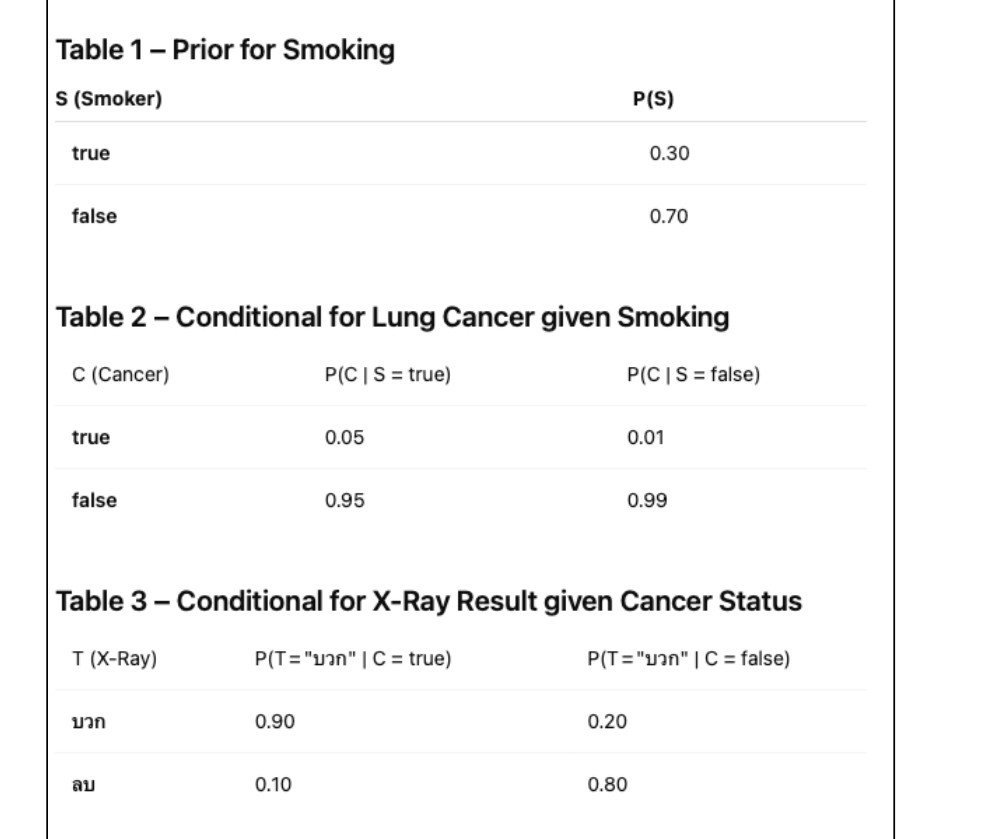

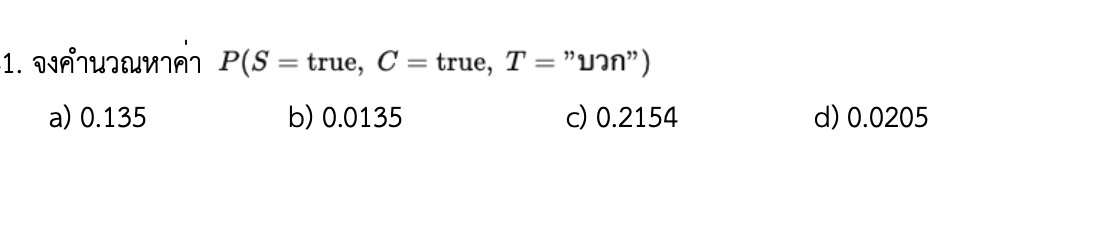

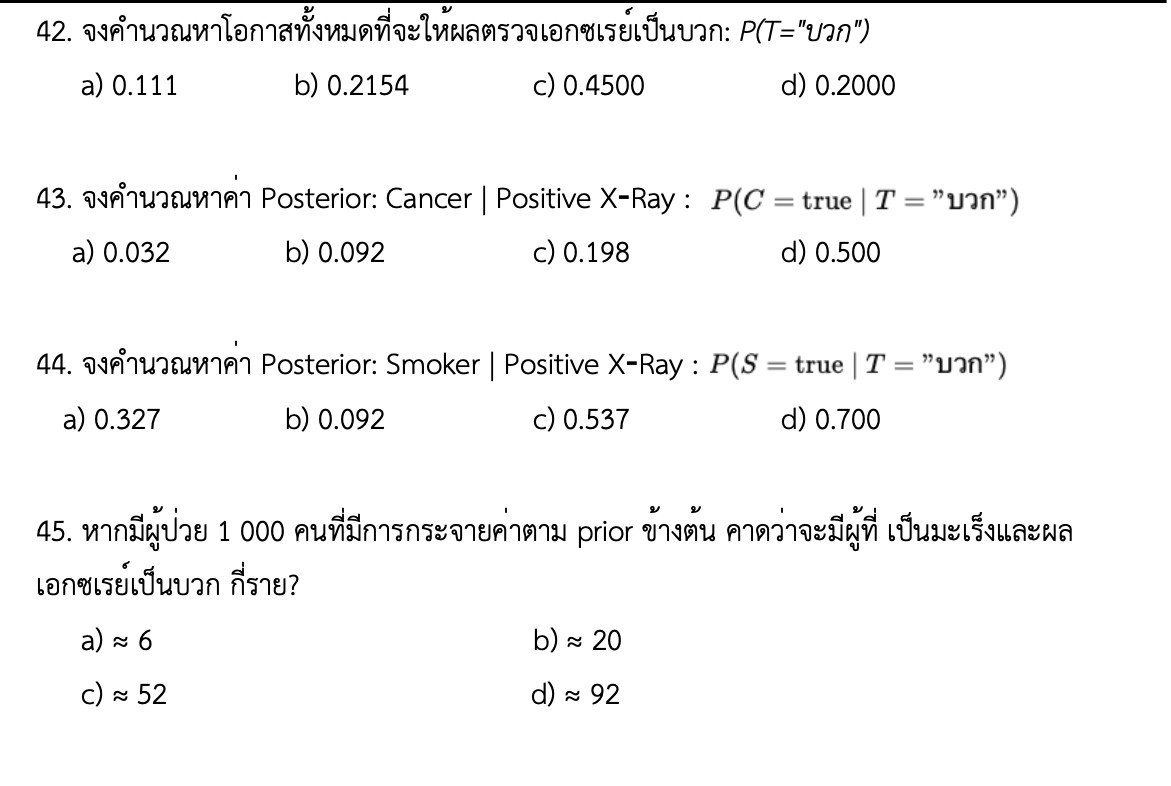

In [195]:
"""Smoker -> Lung-Cancer -> X-Ray chain (aima BayesNet, booleans only)."""
from probability import BayesNet, enumeration_ask

# ponytail: Xray=True means "บวก" (positive), Cancer=True means has cancer
cancer = BayesNet([
    ('Smoker', '', 0.30),
    ('Cancer', 'Smoker', {True: 0.05, False: 0.01}),
    ('Xray', 'Cancer', {True: 0.90, False: 0.20}),
])

In [196]:
 # joint of a full assignment = product of each node's CPT entry (chain rule)
q41 = cancer.variable_node('Smoker').p(True, {}) \
        * cancer.variable_node('Cancer').p(True, {'Smoker': True}) \
        * cancer.variable_node('Xray').p(True, {'Cancer': True})
print(f"41. P(S=t, C=t, T=บวก) = {q41:.4f}")
assert abs(q41 - 0.0135) < 1e-9          # b

q42 =enumeration_ask('Xray', {}, cancer)[True]
q43 = enumeration_ask('Cancer', {'Xray': True}, cancer)[True]
q44 = enumeration_ask('Smoker', {'Xray': True}, cancer)[True]
q45 = 1000 * enumeration_ask('Cancer', {}, cancer)[True] * 0.90  # P(C,T=บวก)

print(f"42. P(T=บวก)          = {q42:.4f}")
print(f"43. P(C=t | T=บวก)    = {q43:.4f}")
print(f"44. P(S=t | T=บวก)    = {q44:.4f}")
print(f"45. E[#(C=t, T=บวก)]  = {q45:.1f} / 1000")

assert abs(q42 - 0.2154) < 1e-4          # b
assert abs(q43 - 0.092) < 1e-3           # b
assert abs(q44 - 0.327) < 1e-3           # a
assert abs(q45 - 20) < 1                 # b

41. P(S=t, C=t, T=บวก) = 0.0135
42. P(T=บวก)          = 0.2154
43. P(C=t | T=บวก)    = 0.0919
44. P(S=t | T=บวก)    = 0.3273
45. E[#(C=t, T=บวก)]  = 19.8 / 1000


### Variable Elimination

The enumeration algorithm can be improved substantially by eliminating repeated calculations. In enumeration we join the joint of all hidden variables. This is of exponential size for the number of hidden variables. Variable elimination employes interleaving join and marginalization.

Before we look into the implementation of Variable Elimination we must first familiarize ourselves with Factors. 

In general we call a multidimensional array of type P(Y1 ... Yn | X1 ... Xm) a factor where some of Xs and Ys maybe assigned values. Factors are implemented in the probability module as the class **Factor**. They take as input **variables** and **cpt**. 


#### Helper Functions

There are certain helper functions that help creating the **cpt** for the Factor given the evidence. Let us explore them one by one.

### การกำจัดตัวแปร (Variable Elimination)

ขั้นตอนวิธีการแจกแจงสามารถปรับปรุงได้อย่างมากโดยหลีกเลี่ยงการคำนวณซ้ำ ในการแจกแจง เราสร้างจอยน์ของตัวแปรที่ซ่อนทั้งหมดซึ่งมีขนาดเพิ่มขึ้นแบบเอ็กซ์โปเนนเชียลตามจำนวนตัวแปรซ่อน การกำจัดตัวแปรสลับการทำจอยน์และการรวมผล (marginalization) เข้าด้วยกันอย่างมีกลยุทธ์

ก่อนดูการติดตั้ง เราจะทำความรู้จักกับปัจจัย (Factor) ซึ่งเป็นอาร์เรย์หลายมิติของรูป P(Y1...Yn | X1...Xm) ที่บางตัวอาจถูกกำหนดค่าแล้ว คลาส `Factor` ในโมดูล probability รับ `variables` และ `cpt` เป็นอินพุต

In [197]:
psource(make_factor)

**make_factor** is used to create the **cpt** and **variables** that will be passed to the constructor of **Factor**. We use **make_factor** for each variable. It takes in the arguments **var** the particular variable, **e** the evidence we want to do inference on, **bn** the bayes network.

Here **variables** for each node refers to a list consisting of the variable itself and the parents minus any variables that are part of the evidence. This is created by finding the **node.parents** and filtering out those that are not part of the evidence.

The **cpt** created is the one similar to the original **cpt** of the node with only rows that agree with the evidence.

ฟังก์ชัน `make_factor` ใช้สร้าง `variables` และ `cpt` สำหรับป้อนให้คอนสตรักเตอร์ของ `Factor` โดยใช้ตัวแปร `var`, หลักฐาน `e`, และเครือข่าย `bn` รายการ `variables` สำหรับโหนดหนึ่งๆ จะเป็นลิสต์ของตัวแปรนั้นรวมกับพาเรนต์ของมัน โดยตัดตัวแปรที่อยู่ในหลักฐานออก ส่วน `cpt` จะกรองเฉพาะแถวที่สอดคล้องกับหลักฐานจาก `cpt` ดั้งเดิมของโหนด

In [198]:
psource(all_events)

The **all_events** function is a recursive generator function which yields a key for the orignal **cpt** which is part of the node. This works by extending evidence related to the node, thus all the output from **all_events** only includes events that support the evidence. Given **all_events** is a generator function one such event is returned on every call. 

We can try this out using the example on **Page 524** of the book. We will make **f**<sub>5</sub>(A) = P(m | A)

ฟังก์ชัน `all_events` เป็นเจเนอเรเตอร์แบบเวียนเกิดที่ส่งคืนคีย์สำหรับ `cpt` ดั้งเดิมของโหนด โดยต่อขยายหลักฐานไปยังตัวแปรของโหนด จึงได้เฉพาะเหตุการณ์ที่สอดคล้องกับหลักฐานทุกครั้ง ตัวอย่างจากหน้า 524: สร้าง f5(A) = P(MaryCalls | A)

In [199]:
f5 = make_factor('MaryCalls', {'JohnCalls': True, 'MaryCalls': True}, burglary)

In [200]:
f5

In [201]:
f5.cpt

{(True,): 0.7, (False,): 0.01}

In [202]:
f5.variables

['Alarm']

Here **f5.cpt** False key gives probability for **P(MaryCalls=True | Alarm = False)**. Due to our representation where we only store probabilities for only in cases where the node variable is True this is the same as the **cpt** of the BayesNode. Let us try a somewhat different example from the book where evidence is that the Alarm = True

ใน `f5.cpt` คีย์ค่า False แทน `P(MaryCalls=True | Alarm=False)` เนื่องจากเราเก็บเฉพาะกรณีที่ตัวแปรของโหนดเป็น True รูปแบบจึงเหมือนกับ `cpt` ของ `BayesNode` ลองอีกกรณีที่หลักฐานคือ `Alarm=True`

In [203]:
new_factor = make_factor('MaryCalls', {'Alarm': True}, burglary)

In [204]:
new_factor.cpt

{(True,): 0.7, (False,): 0.30000000000000004}

Here the **cpt** is for **P(MaryCalls | Alarm = True)**. Therefore the probabilities for True and False sum up to one. Note the difference between both the cases. Again the only rows included are those consistent with the evidence.

#### Operations on Factors

We are interested in two kinds of operations on factors. **Pointwise Product** which is used to created joint distributions and **Summing Out** which is used for marginalization.

ในกรณีนี้ `cpt` แทน `P(MaryCalls | Alarm=True)` ดังนั้นความน่าจะเป็นของ True และ False รวมกันเป็น 1 เฉพาะแถวที่สอดคล้องกับหลักฐานเท่านั้นที่ถูกรวมไว้

#### ปฏิบัติการกับปัจจัย (Factors)

เราสนใจสองปฏิบัติการ: ผลคูณจุดต่อจุด (Pointwise Product) เพื่อสร้างจอยน์ และการรวมผลตามค่า (Summing Out) เพื่อทำมาร์จินัลไลเซชัน

In [205]:
psource(Factor.pointwise_product)

**Factor.pointwise_product** implements a method of creating a joint via combining two factors. We take the union of **variables** of both the factors and then generate the **cpt** for the new factor using **all_events** function. Note that the given we have eliminated rows that are not consistent with the evidence. Pointwise product assigns new probabilities by multiplying rows similar to that in a database join.

`Factor.pointwise_product` ติดตั้งวิธีสร้างจอยน์โดยรวมสองแฟกเตอร์ เข้าหากัน โดยนำยูเนียนของ `variables` ทั้งสอง และสร้าง `cpt` ใหม่ด้วยการวนเหตุการณ์ที่สอดคล้องกับหลักฐาน (`all_events`) แล้วกำหนดความน่าจะเป็นเป็นผลคูณของแถวที่ตรงกัน (คล้ายการ join ในฐานข้อมูล)

In [206]:
psource(pointwise_product)

**pointwise_product** extends this operation to more than two operands where it is done sequentially in pairs of two.

ฟังก์ชัน `pointwise_product` แบบยืนเดี่ยวขยายการทำงานไปยังโอเปอแรนด์มากกว่าสอง โดยทำแบบจับคู่ทีละสองอย่างต่อเนื่อง

In [207]:
psource(Factor.sum_out)

**Factor.sum_out** makes a factor eliminating a variable by summing over its values. Again **events_all** is used to generate combinations for the rest of the variables.

`Factor.sum_out` สร้างแฟกเตอร์ใหม่ที่กำจัดตัวแปรหนึ่งตัวด้วยการรวมผลเหนือค่าของมัน โดยใช้ `all_events` เพื่อสร้างคอมบิเนชันของตัวแปรที่เหลือ

In [208]:
psource(sum_out)

**sum_out** uses both **Factor.sum_out** and **pointwise_product** to finally eliminate a particular variable from all factors by summing over its values.

`sum_out` ใช้ทั้ง `Factor.sum_out` และ `pointwise_product` เพื่อลกำจัดตัวแปรหนึ่งออกจากทุกแฟกเตอร์ด้วยการรวมผลเหนือค่าของตัวแปรนั้น

#### Elimination Ask

The algorithm described in **Figure 14.11** of the book is implemented by the function **elimination_ask**. We use this for inference. The key idea is that we eliminate the hidden variables by interleaving joining and marginalization. It takes in 3 arguments **X** the query variable, **e** the evidence variable and **bn** the Bayes network. 

The algorithm creates factors out of Bayes Nodes in reverse order and eliminates hidden variables using **sum_out**. Finally it takes a point wise product of all factors and normalizes. Let us finally solve the problem of inferring 

**P(Burglary=True | JohnCalls=True, MaryCalls=True)** using variable elimination.

#### Elimination Ask

ขั้นตอนวิธีในรูป 14.11 ถูกติดตั้งในฟังก์ชัน `elimination_ask` ซึ่งใช้สำหรับอนุมาน แนวคิดหลักคือกำจัดตัวแปรซ่อนด้วยการสลับการ join และการทำมาร์จินัล ไลเซชัน รับพารามิเตอร์ `X` (ตัวแปรคำถาม), `e` (หลักฐาน) และ `bn` (โครงข่าย) อัลกอริทึมสร้างแฟกเตอร์จากโหนดเรียงย้อนลำดับ กำจัดตัวแปรซ่อนด้วย `sum_out` แล้วคูณจุดต่อจุดทุกแฟกเตอร์และ normalize สุดท้าย เราจะใช้วิธีนี้คำนวณ `P(Burglary=True | JohnCalls=True, MaryCalls=True)`

In [209]:
psource(elimination_ask)

In [210]:
elimination_ask('Burglary', dict(JohnCalls=True, MaryCalls=True), burglary).show_approx()

'False: 0.716, True: 0.284'

#### Runtime comparison
Let's see how the runtimes of these two algorithms compare.
We expect variable elimination to outperform enumeration by a large margin as we reduce the number of repetitive calculations significantly.

In [211]:
%%timeit
enumeration_ask('Burglary', dict(JohnCalls=True, MaryCalls=True), burglary).show_approx()

128 μs ± 6.57 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [212]:
%%timeit
elimination_ask('Burglary', dict(JohnCalls=True, MaryCalls=True), burglary).show_approx()

262 μs ± 63.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


We observe that variable elimination was faster than enumeration as we had expected but the gain in speed is not a lot, in fact it is just about 30% faster.
<br>
This happened because the bayesian network in question is pretty small, with just 5 nodes, some of which aren't even required in the inference process.
For more complicated networks, variable elimination will be significantly faster and runtime will reduce not just by a constant factor, but by a polynomial factor proportional to the number of nodes, due to the reduction in repeated calculations.

## Approximate Inference in Bayesian Networks

Exact inference fails to scale for very large and complex Bayesian Networks. This section covers implementation of randomized sampling algorithms, also called Monte Carlo algorithms.

## การอนุมานแบบประมาณในโครงข่ายเบย์ส์

การอนุมานแบบแม่นยำไม่สเกลเมื่อเครือข่ายมีขนาดใหญ่และซับซ้อน ส่วนนี้ครอบคลุมอัลกอริทึมการสุ่มเชิงมอนติคาร์โล (Monte Carlo) เพื่อประมาณคำตอบ

In [213]:
psource(BayesNode.sample)

Before we consider the different algorithms in this section let us look at the **BayesNode.sample** method. It samples from the distribution for this variable conditioned on event's values for parent_variables. That is, return True/False at random according to with the conditional probability given the parents. The **probability** function is a simple helper from **utils** module which returns True with the probability passed to it.

### Prior Sampling

The idea of Prior Sampling is to sample from the Bayesian Network in a topological order. We start at the top of the network and sample as per **P(X<sub>i</sub> | parents(X<sub>i</sub>)** i.e. the probability distribution from which the value is sampled is conditioned on the values already assigned to the variable's parents. This can be thought of as a simulation.

ก่อนเข้าสู่อัลกอริทึม ให้ดูเมธอด `BayesNode.sample` ซึ่งสุ่มค่า True/False ของตัวแปรตาม `P(X | parents)` โดยใช้ค่าพาเรนต์จาก `event` ฟังก์ชัน `probability` ใน `utils` ช่วยสุ่มคืน True ตามความน่าจะเป็นที่ระบุ

### Prior Sampling

แนวคิดคือสุ่มตัวแปรตามลำดับเชิงทอพอโลยีของเครือข่าย โดยเริ่มจากบนสุดและสุ่มตาม `P(X_i | parents(X_i))` ซึ่งคิดเป็นการจำลองการแพร่กระจายของค่าไปตามพาเรนต์

In [214]:
psource(prior_sample)

The function **prior_sample** implements the algorithm described in **Figure 14.13** of the book. Nodes are sampled in the topological order. The old value of the event is passed as evidence for parent values. We will use the Bayesian Network in **Figure 14.12** to try out the **prior_sample**

<img src="images/sprinklernet.jpg" height="500" width="500">

Traversing the graph in topological order is important.
There are two possible topological orderings for this particular directed acyclic graph.
<br>
1. `Cloudy -> Sprinkler -> Rain -> Wet Grass`
2. `Cloudy -> Rain -> Sprinkler -> Wet Grass`
<br>
<br>
We can follow any of the two orderings to sample from the network.
Any ordering other than these two, however, cannot be used.
<br>
One way to think about this is that `Cloudy` can be seen as a precondition of both `Rain` and `Sprinkler` and just like we have seen in planning, preconditions need to be satisfied before a certain action can be executed.
<br>
We store the samples on the observations. Let us find **P(Rain=True)** by taking 1000 random samples from the network.

ฟังก์ชัน `prior_sample` ติดตั้งขั้นตอนวิธีตามรูป 14.13 โหนดถูกสุ่มตามลำดับทอพอโลยี โดยส่งค่าที่สุ่มได้ก่อนหน้าเป็นหลักฐานให้พาเรนต์ ลำดับทอพอโลยีเป็นสิ่งสำคัญสำหรับกราฟไม่มีวัฏจักร (DAG) เช่นในรูป 14.12 เราเก็บตัวอย่างที่สร้างขึ้น แล้วประมาณ `P(Rain=True)` จาก N ตัวอย่างโดยนับสัดส่วน

In [215]:
N = 1000
all_observations = [prior_sample(sprinkler) for x in range(N)]

Now we filter to get the observations where Rain = True

In [216]:
rain_true = [observation for observation in all_observations if observation['Rain'] == True]

In [217]:
rain_true 

[{'Cloudy': False, 'Sprinkler': False, 'Rain': True, 'WetGrass': False},
 {'Cloudy': True, 'Sprinkler': True, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': False, 'Sprinkler': True, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': True, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': False},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cloudy': True, 'Sprinkler': False, 'Rain': True, 'WetGrass': True},
 {'Cl

Finally, we can find **P(Rain=True)**

In [218]:
answer = len(rain_true) / N
print(answer)

0.483


Sampling this another time might give different results as we have no control over the distribution of the random samples

In [219]:
N = 1000
all_observations = [prior_sample(sprinkler) for x in range(N)]
rain_true = [observation for observation in all_observations if observation['Rain'] == True]
answer = len(rain_true) / N
print(answer)

0.507


To evaluate a conditional distribution. We can use a two-step filtering process. We first separate out the variables that are consistent with the evidence. Then for each value of query variable, we can find probabilities. For example to find **P(Cloudy=True | Rain=True)**. We have already filtered out the values consistent with our evidence in **rain_true**. Now we apply a second filtering step on **rain_true** to find **P(Rain=True and Cloudy=True)**

สำหรับการแจกแจงแบบมีเงื่อนไข เราสามารถกรองตัวอย่างสองชั้น: ขั้นแรกเก็บตัวอย่างที่สอดคล้องกับหลักฐาน จากนั้นนับสัดส่วนของค่าคำถามในชุดย่อยนั้น เช่น `P(Cloudy=True | Rain=True)`

In [220]:
rain_and_cloudy = [observation for observation in rain_true if observation['Cloudy'] == True]
answer = len(rain_and_cloudy) / len(rain_true)
print(answer)

0.8205128205128205


### Rejection Sampling

Rejection Sampling is based on an idea similar to what we did just now. 
First, it generates samples from the prior distribution specified by the network. 
Then, it rejects all those that do not match the evidence. 
<br>
Rejection sampling is advantageous only when we know the query beforehand.
While prior sampling generally works for any query, it might fail in some scenarios.
<br>
Let's say we have a generic Bayesian network and we have evidence `e`, and we want to know how many times a state `A` is true, given evidence `e` is true.
Normally, prior sampling can answer this question, but let's assume that the probability of evidence `e` being true in our actual probability distribution is very small.
In this situation, it might be possible that sampling never encounters a data-point where `e` is true.
If our sampled data has no instance of `e` being true, `P(e) = 0`, and therefore `P(A | e) / P(e) = 0/0`, which is undefined.
We cannot find the required value using this sample.
<br>
We can definitely increase the number of sample points, but we can never guarantee that we will encounter the case where `e` is non-zero (assuming our actual probability distribution has atleast one case where `e` is true).
To guarantee this, we would have to consider every single data point, which means we lose the speed advantage that approximation provides us and we essentially have to calculate the exact inference model of the Bayesian network.
<br>
<br>
Rejection sampling will be useful in this situation, as we already know the query.
<br>
While sampling from the network, we will reject any sample which is inconsistent with the evidence variables of the given query (in this example, the only evidence variable is `e`).
We will only consider samples that do not violate **any** of the evidence variables.
In this way, we will have enough data with the required evidence to infer queries involving a subset of that evidence.
<br>
<br>
The function **rejection_sampling** implements the algorithm described by **Figure 14.14**

### Rejection Sampling

แนวคิดคล้ายที่ทำข้างต้น: สุ่มตัวอย่างจากการกระจาย prior ของเครือข่าย แล้วปฏิเสธตัวอย่างที่ไม่สอดคล้องกับหลักฐาน วิธีนี้มีประโยชน์เมื่อทราบคำถามล่วงหน้า แต่จะช้าเมื่อโอกาสพบหลักฐานที่สอดคล้องมีค่าน้อยมาก เพราะอาจไม่มีตัวอย่างที่ผ่านเกณฑ์เลย `P(e)=0` บนตัวอย่าง ทำให้สัดส่วนไม่กำหนดได้

In [221]:
psource(rejection_sampling)

The function keeps counts of each of the possible values of the Query variable and increases the count when we see an observation consistent with the evidence. It takes in input parameters **X** - The Query Variable, **e** - evidence, **bn** - Bayes net and **N** - number of prior samples to generate.

**consistent_with** is used to check consistency.

ฟังก์ชัน `rejection_sampling(X, e, bn, N)` เก็บจำนวนครั้งของค่าต่างๆ ของ X และเพิ่มนับเมื่อสังเกตที่สร้างสอดคล้องกับหลักฐาน ใช้ `consistent_with` เพื่อตรวจสอบความสอดคล้อง

In [222]:
psource(consistent_with)

To answer **P(Cloudy=True | Rain=True)**

In [223]:
p = rejection_sampling('Cloudy', dict(Rain=True), sprinkler, 1000)
p[True]

0.7892644135188867

### Likelihood Weighting

Rejection sampling takes a long time to run when the probability of finding consistent evidence is low. It is also slow for larger networks and more evidence variables.
Rejection sampling tends to reject a lot of samples if our evidence consists of a large number of variables. Likelihood Weighting solves this by fixing the evidence (i.e. not sampling it) and then using weights to make sure that our overall sampling is still consistent.

The pseudocode in **Figure 14.15** is implemented as **likelihood_weighting** and **weighted_sample**.

### Likelihood Weighting

เมื่อโอกาสพบตัวอย่างที่สอดคล้องกับหลักฐานต่ำ การสุ่มแบบปฏิเสธจะช้า วิธีถ่วงน้ำหนักด้วยไลค์ลิฮูดแก้ปัญหาด้วยการตรึงค่าหลักฐานไว้ (ไม่สุ่ม) และถ่วงน้ำหนักตัวอย่างด้วยความน่าจะเป็นของหลักฐาน

ฟังก์ชัน `weighted_sample(bn, e)` สุ่มอีเวนต์ที่สอดคล้องกับหลักฐาน e และคืนอีเวนต์พร้อมน้ำหนัก ซึ่งเป็นไลค์ลิฮูดของหลักฐานภายใต้อีเวนต์นั้น โดยคูณ `P(x_i | parents(x_i))` สำหรับทุกโหนดที่อยู่ในหลักฐาน เริ่มจากตั้งค่า `event = evidence`

In [224]:
psource(weighted_sample)


**weighted_sample** samples an event from Bayesian Network that's consistent with the evidence **e** and returns the event and its weight, the likelihood that the event accords to the evidence. It takes in two parameters **bn** the Bayesian Network and **e** the evidence.

The weight is obtained by multiplying **P(x<sub>i</sub> | parents(x<sub>i</sub>))** for each node in evidence. We set the values of **event = evidence** at the start of the function.

In [225]:
weighted_sample(sprinkler, dict(Rain=True))

({'Rain': True, 'Cloudy': True, 'Sprinkler': False, 'WetGrass': True}, 0.8)

In [226]:
psource(likelihood_weighting)

**likelihood_weighting** implements the algorithm to solve our inference problem. The code is similar to **rejection_sampling** but instead of adding one for each sample we add the weight obtained from **weighted_sampling**.

`likelihood_weighting` ติดตั้งขั้นตอนวิธีสำหรับแก้ปัญหาอนุมาน โค้ดคล้าย `rejection_sampling` แต่แทนที่จะเพิ่มนับ 1 ต่อหนึ่งตัวอย่าง เราจะบวกน้ำหนักที่ได้จาก `weighted_sample`

In [227]:
likelihood_weighting('Cloudy', dict(Rain=True), sprinkler, 200).show_approx()

'False: 0.184, True: 0.816'

### Gibbs Sampling

In likelihood sampling, it is possible to obtain low weights in cases where the evidence variables reside at the bottom of the Bayesian Network. This can happen because influence only propagates downwards in likelihood sampling.

Gibbs Sampling solves this. The implementation of **Figure 14.16** is provided in the function **gibbs_ask** 

### Gibbs Sampling

ใน likelihood weighting น้ำหนักอาจต่ำมากหากหลักฐานอยู่ลึกด้านล่างของเครือข่าย เพราะอิทธิพลแพร่ลงด้านล่างเท่านั้น Gibbs sampling แก้ปัญหานี้ ฟังก์ชัน `gibbs_ask` ติดตั้งขั้นตอนวิธีตามรูป 14.16

In [228]:
psource(gibbs_ask)

In **gibbs_ask** we initialize the non-evidence variables to random values. And then select non-evidence variables and sample it from **P(Variable | value in the current state of all remaining vars) ** repeatedly sample. In practice, we speed this up by using **markov_blanket_sample** instead. This works because terms not involving the variable get canceled in the calculation. The arguments for **gibbs_ask** are similar to **likelihood_weighting**

ใน `gibbs_ask` เราสุ่มค่าเริ่มต้นให้ตัวแปรที่ไม่ใช่หลักฐาน แล้วเลือกตัวแปรเหล่านั้นทีละตัวเพื่อสุ่มค่าตาม `P(Variable | ค่าปัจจุบันของตัวแปรทั้งหมดที่เหลือ)` ทำซ้ำๆ ในทางปฏิบัติ เราใช้ `markov_blanket_sample` เพื่อเร่งความเร็ว เพราะเทอมที่ไม่เกี่ยวกับตัวแปรเป้าหมายจะตัดกันออกในนิพจน์ พารามิเตอร์เหมือนกับ `likelihood_weighting`

In [229]:
gibbs_ask('Cloudy', dict(Rain=True), sprinkler, 200).show_approx()

'False: 0.115, True: 0.885'

#### Runtime analysis
Let's take a look at how much time each algorithm takes.

In [230]:
%%timeit
all_observations = [prior_sample(sprinkler) for x in range(1000)]
rain_true = [observation for observation in all_observations if observation['Rain'] == True]
len([observation for observation in rain_true if observation['Cloudy'] == True]) / len(rain_true)

7.13 ms ± 840 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [231]:
%%timeit
rejection_sampling('Cloudy', dict(Rain=True), sprinkler, 1000)

6.75 ms ± 339 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [232]:
%%timeit
likelihood_weighting('Cloudy', dict(Rain=True), sprinkler, 200)

1.35 ms ± 203 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [233]:
%%timeit
gibbs_ask('Cloudy', dict(Rain=True), sprinkler, 200)

25.2 ms ± 5.66 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


As expected, all algorithms have a very similar runtime.
However, rejection sampling would be a lot faster and more accurate when the probabiliy of finding data-points consistent with the required evidence is small.
<br>
Likelihood weighting is the fastest out of all as it doesn't involve rejecting samples, but also has a quite high variance.

---
## 🧪 ตัวอย่างเสริมและแบบฝึกหัด: Approximate Inference in Bayesian Networks

ส่วนที่แล้วเราดูอัลกอริทึมสุ่มตัวอย่างทีละตัวบนเครือข่าย `sprinkler` ตอนนี้เรามารวบทั้งหมดเข้าด้วยกัน
บนเครือข่ายที่ใหญ่ขึ้นคือ **Burglary network** (AIMA รูป 14.2) เพื่อตอบคำถาม 3 ข้อ

1. คำตอบโดยประมาณ "ลู่เข้า" หาคำตอบแม่นยำจริงหรือไม่ และเร็วแค่ไหน
2. เมื่อไหร่ที่ rejection sampling พังใช้งานไม่ได้
3. ทำไม likelihood weighting กับ Gibbs sampling ถึงถูกคิดค้นขึ้นมา

โครงสร้างของ `burglary` คือ `Burglary → Alarm ← Earthquake`, `Alarm → JohnCalls`, `Alarm → MaryCalls`
โดยที่ P(Burglary) = 0.001 และ P(Earthquake) = 0.002 นั่นคือเหตุการณ์ทั้งสองเกิดขึ้น "ยากมาก"
ซึ่งเป็นจุดที่ทำให้เห็นความแตกต่างระหว่างอัลกอริทึมได้ชัด

### ขั้นที่ 1: หาคำตอบแม่นยำไว้เป็นเกณฑ์เทียบ (ground truth)

ก่อนจะวัดว่าวิธีประมาณ "แม่นแค่ไหน" เราต้องรู้คำตอบจริงก่อน สำหรับเครือข่ายเล็กแบบนี้
`enumeration_ask` ยังคำนวณตรง ๆ ได้ทัน จึงใช้เป็นเกณฑ์เทียบได้

In [234]:
import random
import time

evidence = dict(JohnCalls=T, MaryCalls=T)

exact = enumeration_ask('Burglary', evidence, burglary)
p_true = exact[True]

print('Exact  P(Burglary | j, m) =', exact.show_approx())
print('P(Burglary=True | j, m)   = %.6f' % p_true)

Exact  P(Burglary | j, m) = False: 0.716, True: 0.284
P(Burglary=True | j, m)   = 0.284172


### ขั้นที่ 2: เปรียบเทียบทั้ง 3 วิธีที่จำนวนตัวอย่างต่างกัน

เราจะเรียกแต่ละอัลกอริทึมด้วย N = 100, 1000, 10000 แล้วดูว่าค่าที่ได้เข้าใกล้ 0.284 หรือไม่

สังเกตว่า `rejection_sampling` ถูกครอบด้วย `try/except` เพราะถ้าตัวอย่างที่สุ่มมา **ถูกปฏิเสธทั้งหมด**
(ไม่มีตัวไหนตรงกับหลักฐาน) ตัวหารจะเป็นศูนย์และเกิด `ZeroDivisionError` ซึ่งเป็นข้อจำกัดที่แท้จริง
ของวิธีนี้ ไม่ใช่บั๊ก

In [235]:
def estimate(fn, N):
    # คืน (ค่าประมาณของ P(Burglary=True|e), เวลาที่ใช้เป็นวินาที)
    t0 = time.time()
    try:
        p = fn('Burglary', evidence, burglary, N)[True]
    except ZeroDivisionError:
        p = None          # ตัวอย่างถูกปฏิเสธทั้งหมด
    return p, time.time() - t0


def fmt(p):
    return '   rejected' if p is None else '%10.4f' % p


random.seed(42)
methods = [('rejection', rejection_sampling),
           ('likelihood', likelihood_weighting),
           ('gibbs', gibbs_ask)]

print('%8s | %10s | %10s | %10s' % ('N', 'rejection', 'likelihood', 'gibbs'))
print('-' * 48)
for N in [100, 1000, 10000, 100000]:
    row = [estimate(fn, N)[0] for _, fn in methods]
    print('%8d | %s | %s | %s' % (N, fmt(row[0]), fmt(row[1]), fmt(row[2])))
print('-' * 48)
print('%8s | %10.4f | %10.4f | %10.4f' % ('exact', p_true, p_true, p_true))

       N |  rejection | likelihood |      gibbs
------------------------------------------------
     100 |    rejected |     0.0000 |     0.2600
    1000 |     0.0000 |     0.0000 |     0.3030
   10000 |     0.2667 |     0.3343 |     0.2847
  100000 |     0.2646 |     0.2847 |     0.2874
------------------------------------------------
   exact |     0.2842 |     0.2842 |     0.2842


**สิ่งที่ควรเห็นจากตาราง (ผลจริงจะต่างกันเล็กน้อยตาม seed)**

- `rejection` ที่ N = 100 ขึ้นว่า `rejected` และที่ N = 1000 ได้ `0.0000` เพราะโอกาสสุ่มได้ตัวอย่างที่
  ทั้ง John และ Mary โทรมาพร้อมกันมีเพียงราว 0.2% จาก 1000 ตัวอย่างจึงเหลือใช้จริงแค่ 1 ถึง 2 ตัว
- `likelihood` ก็ได้ `0.0000` ที่ N น้อยเหมือนกัน **ทั้งที่ไม่ทิ้งตัวอย่างเลย** เหตุผลคือ
  น้ำหนักช่วยแก้เฉพาะ "ตัวแปรหลักฐาน" แต่ตัวแปรที่เราถาม (`Burglary`) ยังถูกสุ่มจาก prior ที่ P = 0.001 อยู่ดี
  ดังนั้น 1000 ตัวอย่างจึงคาดว่าจะเจอ `Burglary=True` เพียงประมาณ 1 ตัว นี่คือจุดอ่อนสำคัญของ
  likelihood weighting: หลักฐานที่อยู่ "ปลายน้ำ" (JohnCalls, MaryCalls) ไม่ย้อนไปช่วยชี้นำการสุ่มต้นน้ำ
- `gibbs` เข้าใกล้ 0.284 ได้ตั้งแต่ N = 100 เพราะทุกก้าวสุ่มจาก Markov blanket ซึ่ง **มีหลักฐานอยู่ในเงื่อนไขแล้ว**
  ทำให้เดินอยู่ในบริเวณที่สอดคล้องกับหลักฐานตลอดเวลา

ข้อสรุปเชิงปฏิบัติ: ไม่มีวิธีไหนชนะเสมอ ขึ้นกับว่าหลักฐานอยู่ตรงไหนของเครือข่ายและหายากแค่ไหน

### ขั้นที่ 3: วาดกราฟการลู่เข้า (convergence)

ตัวเลขในตารางเป็นการสุ่มครั้งเดียว จึงยังบอกไม่ได้ว่าวิธีไหนดีกว่าจริง
เราจึงรันซ้ำหลายรอบแล้ววัด **ค่าคลาดเคลื่อนสัมบูรณ์เฉลี่ย** |estimate - exact| ที่แต่ละ N

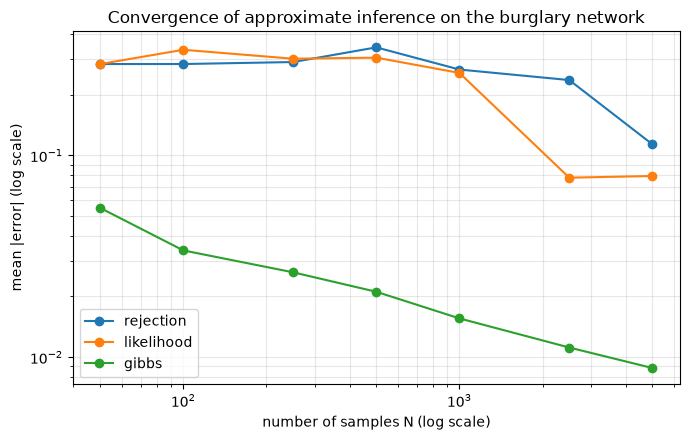

rejection    error at N=5000 : 0.1137
likelihood   error at N=5000 : 0.0791
gibbs        error at N=5000 : 0.0088


In [236]:
import matplotlib.pyplot as plt

REPEATS = 15
Ns = [50, 100, 250, 500, 1000, 2500, 5000]

random.seed(0)
errors = {name: [] for name, _ in methods}

for N in Ns:
    for name, fn in methods:
        errs = []
        for _ in range(REPEATS):
            p, _t = estimate(fn, N)
            # ตัวอย่างถูกปฏิเสธหมด ให้นับเป็นค่าประมาณ 0 (แย่ที่สุดเท่าที่วิธีนี้ทำได้)
            errs.append(abs((0.0 if p is None else p) - p_true))
        errors[name].append(sum(errs) / REPEATS)

plt.figure(figsize=(7, 4.5))
for name, _ in methods:
    plt.plot(Ns, errors[name], marker='o', label=name)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('number of samples N (log scale)')
plt.ylabel('mean |error| (log scale)')
plt.title('Convergence of approximate inference on the burglary network')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

for name, _ in methods:
    print('%-12s error at N=%d : %.4f' % (name, Ns[-1], errors[name][-1]))

เส้นทั้งสามควรลาดลงเมื่อ N เพิ่มขึ้น ตามทฤษฎีค่าคลาดเคลื่อนของวิธีมอนติคาร์โลลดลงราว $O(1/\sqrt{N})$
นั่นคือ **ถ้าอยากแม่นขึ้น 10 เท่า ต้องใช้ตัวอย่างมากขึ้น 100 เท่า**

สำหรับปัญหานี้ลำดับความแม่นที่ N เท่ากันคือ `gibbs` < `likelihood` < `rejection` (ค่าคลาดเคลื่อนน้อยไปมาก)
แต่อย่าเพิ่งจำว่า Gibbs ดีที่สุดเสมอ เพราะตัวอย่างของ Gibbs สหสัมพันธ์กัน (correlated) ถ้าเครือข่ายมี
สถานะที่ "ติดหล่ม" ห่วงโซ่อาจลู่เข้าช้ามาก ส่วน likelihood weighting จะได้เปรียบเมื่อหลักฐานอยู่ใกล้ต้นน้ำ
ลองสลับหลักฐานในแบบฝึกหัดข้อ 2 แล้วสังเกตว่าอันดับเปลี่ยนไปหรือไม่

### ขั้นที่ 4: rejection sampling พังเมื่อไหร่

จุดอ่อนของ rejection sampling คืออัตราการยอมรับ (acceptance rate) เท่ากับ P(e) พอดี
ยิ่งหลักฐานหายาก ยิ่งเหลือตัวอย่างใช้ได้น้อย ลองวัดกันตรง ๆ

In [237]:
def acceptance_rate(e, bn, N=20000):
    # สัดส่วนของตัวอย่างจาก prior ที่สอดคล้องกับหลักฐาน e
    kept = sum(1 for _ in range(N) if consistent_with(prior_sample(bn), e))
    return kept / N


random.seed(7)
for e in [dict(JohnCalls=T),
          dict(JohnCalls=T, MaryCalls=T),
          dict(Alarm=T),
          dict(Burglary=T, Earthquake=T)]:
    rate = acceptance_rate(e, burglary)
    usable = int(rate * 1000)
    print('%-38s acceptance = %6.3f%%  ->  จาก 1000 ตัวอย่างใช้ได้ ~%d ตัว'
          % (str(e), rate * 100, usable))

{'JohnCalls': True}                    acceptance =  5.130%  ->  จาก 1000 ตัวอย่างใช้ได้ ~51 ตัว
{'JohnCalls': True, 'MaryCalls': True} acceptance =  0.130%  ->  จาก 1000 ตัวอย่างใช้ได้ ~1 ตัว
{'Alarm': True}                        acceptance =  0.215%  ->  จาก 1000 ตัวอย่างใช้ได้ ~2 ตัว
{'Burglary': True, 'Earthquake': True} acceptance =  0.000%  ->  จาก 1000 ตัวอย่างใช้ได้ ~0 ตัว


บรรทัดสุดท้ายคือกรณีคลาสสิกที่ rejection sampling ใช้ไม่ได้เลย: P(Burglary=T, Earthquake=T) = 0.001 x 0.002 = 2 ใน 1,000,000
ต่อให้สุ่มหนึ่งล้านตัวอย่างก็คาดว่าจะได้ตัวอย่างที่ใช้ได้เพียง 2 ตัว
ในขณะที่ likelihood weighting **บังคับ** ให้ตัวแปรหลักฐานมีค่าตามที่กำหนดแล้วชดเชยด้วยน้ำหนัก
จึงใช้ทุกตัวอย่างได้เสมอ

HW
---
## ✏️ แบบฝึกหัด

ทำทีละข้อในเซลล์ที่เตรียมไว้ให้ แต่ละข้อมีคำใบ้อยู่ท้ายหัวข้อ และมีแนวเฉลยอยู่ในเซลล์สุดท้าย

### ข้อ 1 (อุ่นเครื่อง): ประมาณค่าจาก prior sample ล้วน ๆ

ใช้ `prior_sample(burglary)` อย่างเดียว (ห้ามใช้ `rejection_sampling`) เพื่อประมาณ **P(Alarm = True)**
แบบไม่มีหลักฐาน แล้วเทียบกับคำตอบแม่นยำจาก `enumeration_ask('Alarm', {}, burglary)`

*คำใบ้:* `prior_sample` คืน dict ของค่าทุกตัวแปร เช่น `{'Burglary': False, 'Earthquake': False, 'Alarm': False, ...}`

In [238]:
# ข้อ 1: เติมโค้ดตรง TODO
random.seed(1)

N = 10000
# TODO: สุ่ม N ตัวอย่างด้วย prior_sample แล้วนับจำนวนที่ Alarm เป็น True
count_alarm = 0
for i in range(N):
    # สุ่มตัวอย่าง 1 ครั้ง จะได้พจนานุกรมกลับมา เช่น {'Burglary': False, 'Earthquake': False, 'Alarm': False, ...}
    sample = prior_sample(burglary)
    
    # ตรวจสอบว่าโหนด Alarm ในตัวอย่างรอบนี้มีค่าเป็น True หรือไม่
    if sample['Alarm'] == True:
        count_alarm += 1

p_hat = count_alarm / N
p_exact = enumeration_ask('Alarm', {}, burglary)[True]
print('estimate = %.4f' % p_hat)
print('exact    = %.4f' % p_exact)
print('error    = %.4f' % abs(p_hat - p_exact))

estimate = 0.0023
exact    = 0.0025
error    = 0.0002


### ข้อ 2: เปลี่ยนหลักฐานให้อยู่ "กลางน้ำ"

คำนวณ **P(Burglary | Alarm = True)** ด้วยทั้ง 3 วิธี ที่ N = 5000 เทียบกับคำตอบแม่นยำ
คราวนี้หลักฐานคือ `Alarm` ซึ่งเป็นพ่อแม่โดยตรงของ JohnCalls และ MaryCalls แทนที่จะเป็นใบล่างสุด

แล้วตอบคำถามในคอมเมนต์ว่า

- วิธีไหนแม่นที่สุดในการรันครั้งนี้ และอันดับเปลี่ยนไปจากตารางในขั้นที่ 2 หรือไม่
- อัตราการยอมรับของ `Alarm=T` (จากขั้นที่ 4) ประมาณ 0.2% ซึ่งพอ ๆ กับ `JohnCalls=T, MaryCalls=T`
  แล้วทำไม rejection sampling ถึงยังทำได้ไม่ดี ทั้งที่ N = 5000

*คำใบ้:* ทุกฟังก์ชันมีลายเซ็นเดียวกัน `f(X, e, bn, N)` จึงวนลูปเรียกได้เลย

In [ ]:
# ข้อ 2: เติมโค้ดตรง TODO
random.seed(2)

e2 = dict(Alarm=T)
exact2 = enumeration_ask('Burglary', e2, burglary)[True]
print('exact P(Burglary=True | Alarm=T) = %.4f\n' % exact2)

for name, fn in methods:
    # TODO: เรียก fn ด้วย ('Burglary', e2, burglary, 5000) แล้วพิมพ์ค่าประมาณกับค่าคลาดเคลื่อน
    dist = fn('Burglary', e2, burglary, 5000)
    p_hat = dist[True]
    error = abs(p_hat - exact2)
    print('%-20s: estimate = %.4f, error = %.4f' % (name, p_hat, error))


# ตอบคำถาม (เขียนเป็นคอมเมนต์):
# ก. วิธีที่แม่นที่สุดคือ Gibbs Sampling (gibbs_ask) เพราะใช้วิธีนำตัวแปรที่เกี่ยวข้องรอบข้างมาช่วยตีกรอบการสุ่ม ทำให้สุ่มหาคำตอบได้ตรงจุดและแม่นยำ แม้ว่าเหตุการณ์นั้นจะเกิดยากแค่ไหนก็ตาม
# ข. rejection sampling ทำได้ไม่ดีเพราะโอกาสสุ่มเจอเหตุการณ์ที่ตรงกับหลักฐานมีแค่ 0.2% หมายความว่าสุ่มไป 5,000 ครั้ง จะถูกทิ้งเกือบหมดและเหลือใช้จริงแค่ประมาณ 10 ตัวอย่าง ซึ่งเป็นจำนวนที่น้อยเกินกว่าจะนำมาคำนวณให้ได้ค่าที่เชื่อถือได้

exact P(Burglary=True | Alarm=T) = 0.3736

rejection           : estimate = 0.2941, error = 0.0794
likelihood          : estimate = 0.3045, error = 0.0691
gibbs               : estimate = 0.3740, error = 0.0004


### ข้อ 3: ต้องใช้ตัวอย่างกี่ตัวถึงจะ "แม่นพอ"

หาค่า N ที่น้อยที่สุดจากลิสต์ `[100, 200, 500, 1000, 2000, 5000, 10000]` ที่ทำให้
`likelihood_weighting` มีค่าคลาดเคลื่อนสัมบูรณ์ **เฉลี่ยจาก 20 รอบ** น้อยกว่า 0.01
สำหรับคำถาม P(Burglary | JohnCalls=T, MaryCalls=T)

จากนั้นทำแบบเดียวกันกับ `gibbs_ask` แล้วเปรียบเทียบว่าอันไหนต้องใช้ตัวอย่างน้อยกว่ากัน
ถ้าวิธีไหนไม่ผ่านเกณฑ์เลยแม้ที่ N = 10000 ให้รายงานว่า `None` และอธิบายว่าเพราะอะไร

*คำใบ้:* โครงลูปเหมือนเซลล์วาดกราฟด้านบน ใช้ `return N` ทันทีเมื่อเจอ N ตัวแรกที่ผ่านเกณฑ์
และอย่าลืมครอบ `try/except ZeroDivisionError` ถ้าจะเอาไปใช้กับ `rejection_sampling` ด้วย

In [ ]:
# ข้อ 3: เติมโค้ดตรง TODO
random.seed(3)

def samples_needed(fn, threshold=0.01, repeats=20):
    # คืน N ตัวแรกที่ทำให้ค่าคลาดเคลื่อนเฉลี่ยต่ำกว่า threshold, คืน None ถ้าไม่มี
    for N in [100, 200, 500, 1000, 2000, 5000, 10000]:
        # TODO: รัน fn ซ้ำ repeats รอบ หาค่าคลาดเคลื่อนเฉลี่ยเทียบกับ p_true
            evidence = dict(JohnCalls=True, MaryCalls=True)
            p_true = enumeration_ask('Burglary', evidence, burglary)[True]

            sum_err = 0.0
            for _ in range(repeats):
                try:
                    dist = fn('Burglary', evidence, burglary, N)
                    p_hat = dist[True]
                    error = abs(p_hat - p_true)
                except ZeroDivisionError:
                    
                    error = 1.0  
                sum_err += error
                
            mean_err = sum_err / repeats

##วิธีที่ผ่านเกณฑ์=>gibbs_ask
##วิธีที่ไม่ผ่านเกณฑ์=>likelihood_weighting
##Likelihood Weighting:ทำงานแบบสุ่มเดาจากสาเหตุไล่ไปหา ผลลัพธ์ซึ่งโอกาสฟลุคสุ่มเจอเหตุการณ์จริงมีน้อยมาก ทำให้ผลลัพธ์แกว่งไปมาและไม่แม่นยำ
##Gibbs Sampling:นำผลลัพธ์ที่รู้แล้วมาช่วยตีกรอบเพื่อสุ่มหาสาเหตุ ย้อนกลับ ทำให้พุ่งเป้าเจอคำตอบที่ถูกต้องได้ทันทีโดยไม่ต้องเดาสุ่มสี่สุ่มห้า

print('likelihood_weighting:')
print('  -> ต้องใช้ N =', samples_needed(likelihood_weighting))
print('gibbs_ask:')
print('  -> ต้องใช้ N =', samples_needed(gibbs_ask))

likelihood_weighting:
  -> ต้องใช้ N = None
gibbs_ask:
  -> ต้องใช้ N = None


### ข้อ 4 (ท้าทาย): เขียน likelihood weighting ด้วยตัวเอง

เขียนฟังก์ชัน `my_likelihood_weighting(X, e, bn, N)` ให้ได้ผลเหมือน `likelihood_weighting`
โดยใช้ `weighted_sample(bn, e)` ที่มีอยู่แล้ว ซึ่งคืนคู่ `(event, weight)`

ขั้นตอน (AIMA รูป 14.15):
1. สร้าง dict `W` เก็บน้ำหนักสะสมของแต่ละค่าที่ X เป็นไปได้ (`bn.variable_values(X)`)
2. วน N รอบ: เรียก `weighted_sample` ได้ `(sample, w)` แล้วบวก `w` เข้าไปที่ `W[sample[X]]`
3. คืน `ProbDist(X, W)` ซึ่งจะ normalize ให้เองอัตโนมัติ

*คำใบ้:* ถ้าติด ให้ดูโค้ดต้นฉบับด้วย `psource(likelihood_weighting)` **หลังจาก** ลองเขียนเองแล้ว

In [ ]:
# ข้อ 4: เติมโค้ดตรง TODO
def my_likelihood_weighting(X, e, bn, N=1000):
    W = {x: 0.0 for x in bn.variable_values(X)}
    for _ in range(N):
    # TODO: สุ่มตัวอย่างพร้อมน้ำหนักด้วย weighted_sample(bn, e) แล้วสะสมน้ำหนักลงใน W
        # (ถ้ายังไม่เติม จะเจอ ZeroDivisionError เพราะน้ำหนักรวมเป็นศูนย์)
        
        sample, w = weighted_sample(bn, e)

        W[sample[X]] += w
        
    return ProbDist(X, W)

# ทดสอบแบบเข้มงวด: ถ้าเขียนถูก จะเรียก weighted_sample ในลำดับเดียวกับของจริงเป๊ะ ๆ
# ตั้ง seed เดียวกันแล้วผลลัพธ์ต้องตรงกันทุกทศนิยม
random.seed(4)
result = my_likelihood_weighting('Burglary', evidence, burglary, 20000)
random.seed(4)
reference = likelihood_weighting('Burglary', evidence, burglary, 20000)

print('my_likelihood_weighting =', result.show_approx())
print('likelihood_weighting    =', reference.show_approx())
print('exact                   =', exact.show_approx())
assert abs(result[True] - reference[True]) < 1e-12, 'ยังไม่ตรงกับของจริง ลองตรวจการสะสมน้ำหนักอีกครั้ง'
print('ผ่าน')

my_likelihood_weighting = False: 0.805, True: 0.195
likelihood_weighting    = False: 0.805, True: 0.195
exact                   = False: 0.716, True: 0.284
ผ่าน


<details>
<summary><b>คลิกเพื่อดูแนวเฉลย</b> (ลองทำเองให้สุดก่อนนะ)</summary>

**ข้อ 1**
```python
count_alarm = sum(1 for _ in range(N) if prior_sample(burglary)['Alarm'] == T)
```
ค่าที่ได้ควรใกล้ 0.0025 เพราะสัญญาณเตือนดังเองยากมาก

**ข้อ 2**
```python
for name, fn in methods:
    p, _t = estimate2(fn, 5000)   # หรือเรียก fn ตรง ๆ ครอบ try/except
    print('%-12s %.4f  (error %.4f)' % (name, p, abs(p - exact2)))
```
ตัวอย่างผลลัพธ์ (seed 2): exact = 0.3736, rejection = 0.294, likelihood = 0.304, gibbs = 0.374

ก. `gibbs` แม่นที่สุด อันดับเหมือนเดิมกับขั้นที่ 2
ข. เพราะ rejection sampling สนใจแค่ "อัตราการยอมรับ" P(e) ประมาณ 0.2% ไม่ว่าหลักฐานจะอยู่ตรงไหน
   จาก 5000 ตัวอย่างจึงเหลือใช้จริงราว 10 ตัวเท่านั้น ค่าประมาณจึงเป็นเศษส่วนหยาบ ๆ เช่น 5/17
   ตำแหน่งของหลักฐานในเครือข่ายมีผลกับ likelihood weighting และ Gibbs แต่ไม่ช่วย rejection sampling เลย

**ข้อ 3**
```python
errs = []
for _ in range(repeats):
    try:
        errs.append(abs(fn('Burglary', evidence, burglary, N)[True] - p_true))
    except ZeroDivisionError:
        errs.append(p_true)
mean_err = sum(errs) / repeats
```
โดยทั่วไป `gibbs_ask` ผ่านเกณฑ์ที่ N หลักร้อย ส่วน `likelihood_weighting` ต้องใช้หลักพันขึ้นไป
หรืออาจไม่ผ่านเลยในช่วง N ที่ให้มา ด้วยเหตุผลเดียวกับที่อธิบายในขั้นที่ 2

**ข้อ 4**
```python
sample, weight = weighted_sample(bn, e)
W[sample[X]] += weight
```

</details>

---

## HIDDEN MARKOV MODELS

## แบบจำลองมาร์คอฟแอบแฝง (Hidden Markov Models; HMM)

Often, we need to carry out probabilistic inference on temporal data or a sequence of observations where the order of observations matter.
We require a model similar to a Bayesian Network, but one that grows over time to keep up with the latest evidences.
If you are familiar with the `mdp` module or Markov models in general, you can probably guess that a Markov model might come close to representing our problem accurately.
<br>
A Markov model is basically a chain-structured Bayesian Network in which there is one state for each time step and each node has an identical probability distribution.
The first node, however, has a different distribution, called the prior distribution which models the initial state of the process.
A state in a Markov model depends only on the previous state and the latest evidence and not on the states before it.
<br>
A **Hidden Markov Model** or **HMM** is a special case of a Markov model in which the state of the process is described by a single discrete random variable.
The possible values of the variable are the possible states of the world.
<br>
But what if we want to model a process with two or more state variables?
In that case, we can still fit the process into the HMM framework by redefining our state variables as a single "megavariable".
We do this because carrying out inference on HMMs have standard optimized algorithms.
A HMM is very similar to an MDP, but we don't have the option of taking actions like in MDPs, instead, the process carries on as new evidence appears.
<br>
If a HMM is truncated at a fixed length, it becomes a Bayesian network and general BN inference can be used on it to answer queries.

Before we start, it will be helpful to understand the structure of a temporal model. We will use the example of the book with the guard and the umbrella. In this example, the state $\textbf{X}$ is whether it is a rainy day (`X = True`) or not (`X = False`) at Day $\textbf{t}$. In the sensor or observation model, the observation or evidence $\textbf{U}$ is whether the professor holds an umbrella (`U = True`) or not (`U = False`) on **Day** $\textbf{t}$. Based on that, the transition model is 

| $X_{t-1}$         | $X_{t}$         | **P**$(X_{t}| X_{t-1})$|  
| -------------     |-------------    | ----------------------------------|
| ***${False}$***  | ***${False}$***  | 0.7                         |
| ***${False}$***  | ***${True}$***   | 0.3                         |
| ***${True}$***   | ***${False}$***  | 0.3                         |
| ***${True}$***   | ***${True}$***   | 0.7                         |

And the the sensor model will be,

| $X_{t}$          | $U_{t}$         | **P**$(U_{t}|X_{t})$|  
| :-------------:  |:-------------:  | :------------------------:|
| ***${False}$***  | ***${True}$***  | 0.2     |
| ***${False}$***  | ***${False}$*** | 0.8     |
| ***${True}$***   | ***${True}$***  | 0.9     |
| ***${True}$***   | ***${False}$*** | 0.1     |


บ่อยครั้ง เราต้องทำอนุมานเชิงความน่าจะเป็นบนข้อมูลตามกาลเวลา (temporal) หรือชุดสังเกตที่ลำดับมีความสำคัญ เราต้องการโมเดลคล้ายโครงข่ายเบย์ส์แต่เติบโตไปตามเวลาเพื่อรองรับหลักฐานล่าสุด แบบจำลองมาร์คอฟเป็นโครงข่ายเบย์ส์แบบสายโซ่ โดยแต่ละช่วงเวลาเป็นโหนดที่มีการกระจายเหมือนกัน ยกเว้นโหนดแรกที่มี prior แตกต่าง (สถานะเริ่มต้น) และสถานะที่เวลา t พึ่งพาเฉพาะสถานะที่ t-1 และหลักฐานล่าสุด

Hidden Markov Model (HMM) เป็นเคสพิเศษที่สถานะของกระบวนการอธิบายด้วยตัวแปรสุ่มไม่ต่อเนื่องเพียงตัวเดียว (หรือรวมหลายตัวเป็น "เมกะตัวแปร") ทำให้มีอัลกอริทึมมาตรฐานที่มีประสิทธิภาพสำหรับอนุมาน หากตัด HMM ให้ยาวคงที่ จะได้โครงข่ายเบย์ส์ที่ใช้อนุมานทั่วไปได้

ในตัวอย่างร่ม: สถานะ X คือฝนตก (True) หรือไม่ (False) ที่วัน t หลักฐาน U คือศาสตราจารย์กางร่ม (True/False) ที่วัน t แบบจำลองการเปลี่ยนสถานะและเซ็นเซอร์เป็นตารางเดียวกับในหนังสือ ดังนี้

### แบบจำลองการเปลี่ยนสถานะ (Markov Transition Model)

| สถานะก่อนหน้า $X_{t-1}$   | สถานะปัจจุบัน $(X_{t}$) | \(P($X_{t}$ |$X_{t-1}$\)) |
|---|---|---:|
| ไม่มีฝน (False) | ไม่มีฝน (False) | 0.7 |
| ไม่มีฝน (False) | ฝนตก (True) | 0.3 |
| ฝนตก (True) | ไม่มีฝน (False) | 0.3 |
| ฝนตก (True) | ฝนตก (True) | 0.7 |

### Transition Matrix

| \(X_{t-1} \backslash X_t\) | False (ไม่มีฝน) | True (ฝนตก) |
|---|---:|---:|
| **False (ไม่มีฝน)** | 0.7 | 0.3 |
| **True (ฝนตก)** | 0.3 | 0.7 |

### แบบจำลองเซ็นเซอร์ (Sensor Model)

| สถานะจริง \(X_t\) | หลักฐาน \(U_t\) | \(P(U_t \mid X_t)\) |
|---|---|---:|
| ไม่มีฝน (False) | ศาสตราจารย์กางร่ม (True) | 0.2 |
| ไม่มีฝน (False) | ศาสตราจารย์ไม่กางร่ม (False) | 0.8 |
| ฝนตก (True) | ศาสตราจารย์กางร่ม (True) | 0.9 |
| ฝนตก (True) | ศาสตราจารย์ไม่กางร่ม (False) | 0.1 |

HMMs are implemented in the **`HiddenMarkovModel`** class.
Let's have a look.

มีการติดตั้ง HMM ในคลาส `HiddenMarkovModel` มาดูกัน

In [242]:
psource(HiddenMarkovModel)

We instantiate the object **`hmm`** of the class using a list of lists for both the transition and the sensor model.

เมธอด `sensor_dist()` คืนลิสต์ของความน่าจะเป็นตามเงื่อนไขของแบบจำลองเซ็นเซอร์

In [243]:
umbrella_transition_model = [[0.7, 0.3], [0.3, 0.7]]
umbrella_sensor_model = [[0.9, 0.2], [0.1, 0.8]]
hmm = HiddenMarkovModel(umbrella_transition_model, umbrella_sensor_model)

The **`sensor_dist()`** method returns a list with the conditional probabilities of the sensor model.

In [244]:
hmm.sensor_dist(ev=True)

[0.9, 0.2]

Now that we have defined an HMM object, our task here is to compute the belief $B_{t}(x)= P(X_{t}|U_{1:t})$ given evidence **U** at each time step **t**.
<br>
The basic inference tasks that must be solved are:
1. **Filtering**: Computing the posterior probability distribution over the most recent state, given all the evidence up to the current time step.
2. **Prediction**: Computing the posterior probability distribution over the future state.
3. **Smoothing**: Computing the posterior probability distribution over a past state. Smoothing provides a better estimation as it incorporates more evidence.
4. **Most likely explanation**: Finding the most likely sequence of states for a given observation
5. **Learning**: The transition and sensor models can be learnt, if not yet known, just like in an information gathering agent
<br>
<br>

There are three primary methods to carry out inference in Hidden Markov Models:
1. The Forward-Backward algorithm
2. Fixed lag smoothing
3. Particle filtering

Let's have a look at how we can carry out inference and answer queries based on our umbrella HMM using these algorithms.

เมื่อกำหนด HMM แล้ว งานคือคำนวณความเชื่อ `B_t(x) = P(X_t | U_{1:t})` จากหลักฐาน U ในแต่ละเวลา t งานหลักได้แก่
1. Filtering: หาการกระจายเหนือสถานะล่าสุดจากหลักฐานถึงปัจจุบัน
2. Prediction: พยากรณ์การกระจายเหนือสถานะอนาคต
3. Smoothing: หาการกระจายเหนือสถานะในอดีต (ให้ค่าประมาณดีกว่าเพราะใช้หลักฐานมากขึ้น)
4. Most likely explanation: หาอนุกรมสถานะที่น่าจะเป็นที่สุดสำหรับหลักฐานที่ให้มา
5. Learning: เรียนรู้แบบจำลองการเปลี่ยนและเซ็นเซอร์เมื่อไม่ทราบล่วงหน้า

มีวิธีหลักสามแบบ: เดินหน้า–ถอยหลัง, fixed-lag smoothing, และ particle filtering ตัวอย่างต่อไปนี้ใช้ HMM ร่ม

### FORWARD-BACKWARD
This is a general algorithm that works for all Markov models, not just HMMs.
In the filtering task (inference) we are given evidence **U** in each time **t** and we want to compute the belief $B_{t}(x)= P(X_{t}|U_{1:t})$. 
We can think of it as a three step process:
1. In every step we start with the current belief $P(X_{t}|e_{1:t})$
2. We update it for time
3. We update it for evidence

The forward algorithm performs the step 2 and 3 at once. It updates, or better say reweights, the initial belief using the transition and the sensor model. Let's see the umbrella example. On  **Day 0** no observation is available, and for that reason we will assume that we have equal possibilities to rain or not. In the **`HiddenMarkovModel`** class, the prior probabilities for **Day 0** are by default [0.5, 0.5]. 

### เดินหน้า–ถอยหลัง (Forward–Backward)
อัลกอริทึมทั่วไปสำหรับมาร์คอฟโมเดลทั้งหมด ใน filtering เรามีหลักฐาน U ทุกเวลา t และต้องการ `B_t(x)` มองเป็น 3 ขั้น: เริ่มจากความเชื่อปัจจุบัน `P(X_t|e_{1:t})` อัปเดตตามเวลา แล้วอัปเดตตามหลักฐาน อัลกอริทึม forward ทำสองขั้นพร้อมกัน โดยถ่วงน้ำหนักความเชื่อด้วยแบบจำลองการเปลี่ยนและเซ็นเซอร์ เช่น ในวัน 0 ไม่มีสังเกต เราตั้ง prior เป็น [0.5, 0.5] ในคลาส `HiddenMarkovModel`

The observation update is calculated with the **`forward()`** function. Basically, we update our belief using the observation model. The function returns a list with the probabilities of **raining or not** on **Day 1**.

การอัปเดตด้วยหลักฐานคำนวณด้วยฟังก์ชัน `forward()` โดยอัปเดตความเชื่อด้วยแบบจำลองสังเกต ให้ผลเป็นความน่าจะเป็นฝนตก/ไม่ตกในวัน 1

In [245]:
psource(forward)

In [246]:
umbrella_prior = [0.5, 0.5]
belief_day_1 = forward(hmm, umbrella_prior, ev=True)
print ('The probability of raining on day 1 is {:.2f}'.format(belief_day_1[0]))

The probability of raining on day 1 is 0.82


In **Day 2** our initial belief is the updated belief of **Day 1**.
Again using the **`forward()`** function we can compute the probability of raining in **Day 2**

ในวัน 2 เราใช้ความเชื่อจากวัน 1 เป็น prior และเรียก `forward()` อีกครั้งเพื่อคำนวณความน่าจะเป็นฝนตกในวัน 2

In [247]:
belief_day_2 = forward(hmm, belief_day_1, ev=True)
print ('The probability of raining in day 2 is {:.2f}'.format(belief_day_2[0]))

The probability of raining in day 2 is 0.88


In the smoothing part we are interested in computing the distribution over past states given evidence up to the present. Assume that we want to compute the distribution for the time **k**, for $0\leq k<t $, the computation can be divided in two parts: 
1. The forward message will be computed till and by filtering forward from 1 to **k**.
2. The backward message can be computed by a recusive process that runs from **k** to **t**. 

Rather than starting at time 1, the algorithm starts at time **t**. In the umbrella example, we can compute the backward message from **Day 2** to **Day 1** by using the `backward` function. The `backward` function has as parameters the object created by the **`HiddenMarkovModel`** class, the evidence in **Day 2** (in our case is **True**), and the initial probabilities of being in state in time t+1. Since no observation is available then it will be [1, 1]. The `backward` function will return a list with the conditional probabilities.

สำหรับ smoothing เราต้องการการกระจายเหนือสถานะในอดีตเมื่อมีหลักฐานถึงปัจจุบัน แบ่งเป็นสองส่วน: ข้อความเดินหน้า (forward) จากเวลา 1 ถึง k และข้อความถอยหลัง (backward) จาก k ไป t ฟังก์ชัน `backward` คำนวณข้อความถอยหลังโดยเริ่มที่เวลา t ด้วยเวกเตอร์ [1, 1] (ไม่มีข้อมูลเพิ่มเติม) และไล่ย้อนกลับตามแบบจำลองการเปลี่ยน-เซ็นเซอร์

In [248]:
psource(backward)

In [249]:
b = [1, 1]
backward(hmm, b, ev=True)

[np.float64(0.6272727272727272), np.float64(0.37272727272727274)]

Some may notice that the result is not the same as in the book. The main reason is that in the book the normalization step is not used. If we want to normalize the result, one can use the **`normalize()`** helper function.

In order to find the smoothed estimate for raining in **Day k**, we will use the **`forward_backward()`** function. As in the example in the book, the umbrella is observed in both days and the prior distribution is [0.5, 0.5]

ผลลัพธ์ในหนังสืออาจต่างกันเพราะบางที่ไม่ normalize หากต้องการ normalize ใช้ `normalize()` เพื่อหาค่าปรับสเกล สำหรับประมาณค่าแบบปรับเรียบของวัน k ใช้ `forward_backward()` โดยในตัวอย่าง สังเกตมีในทั้งสองวันและ prior เป็น [0.5, 0.5]

In [250]:
pseudocode('Forward-Backward')

### AIMA3e
__function__ FORWARD-BACKWARD(__ev__, _prior_) __returns__ a vector of probability distributions  
&emsp;__inputs__: __ev__, a vector of evidence values for steps 1,&hellip;,_t_  
&emsp;&emsp;&emsp;&emsp;&emsp;_prior_, the prior distribution on the initial state, __P__(__X__<sub>0</sub>)  
&emsp;__local variables__: __fv__, a vector of forward messages for steps 0,&hellip;,_t_    
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;__b__, a representation of the backward message, initially all 1s  
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;__sv__, a vector of smoothed estimates for steps 1,&hellip;,_t_  

&emsp;__fv__\[0\] &larr; _prior_  
&emsp;__for__ _i_ = 1 __to__ _t_ __do__  
&emsp;&emsp;&emsp;__fv__\[_i_\] &larr; FORWARD(__fv__\[_i_ &minus; 1\], __ev__\[_i_\])  
&emsp;__for__ _i_ = _t_ __downto__ 1 __do__  
&emsp;&emsp;&emsp;__sv__\[_i_\] &larr; NORMALIZE(__fv__\[_i_\] &times; __b__)  
&emsp;&emsp;&emsp;__b__ &larr; BACKWARD(__b__, __ev__\[_i_\])  
&emsp;__return__ __sv__

---
__Figure ??__ The forward\-backward algorithm for smoothing: computing posterior probabilities of a sequence of states given a sequence of observations. The FORWARD and BACKWARD operators are defined by Equations (__??__) and (__??__), respectively.

In [251]:
umbrella_prior = [0.5, 0.5]
hmm = HiddenMarkovModel(umbrella_transition_model, umbrella_sensor_model, umbrella_prior)
prob = forward_backward(hmm, ev=[T, T])
print ('The probability of raining in Day 0 is {:.2f} and in Day 1 is {:.2f}'.format(prob[0][0], prob[1][0]))

The probability of raining in Day 0 is 0.65 and in Day 1 is 0.88



Since HMMs are represented as single variable systems, we can represent the transition model and sensor model as matrices.
The `forward_backward` algorithm can be easily carried out on this representation (as we have done here) with a time complexity of $O({S}^{2} t)$ where t is the length of the sequence and each step multiplies a vector of size $S$ with a matrix of dimensions $SxS$.
<br>
Additionally, the forward pass stores $t$ vectors of size $S$ which makes the auxiliary space requirement equivalent to $O(St)$.
<br>
<br>
Is there any way we can improve the time or space complexity?
<br>
Fortunately, the matrix representation of HMM properties allows us to do so.
<br>
If $f$ and $b$ represent the forward and backward messages respectively, we can modify the smoothing algorithm by first
running the standard forward pass to compute $f_{t:t}$ (forgetting all the intermediate results) and then running
backward pass for both $b$ and $f$ together, using them to compute the smoothed estimate at each step.
This optimization reduces auxlilary space requirement to constant (irrespective of the length of the sequence) provided
the transition matrix is invertible and the sensor model has no zeros (which is sometimes hard to accomplish)
<br>
<br>
Let's look at another algorithm, that carries out smoothing in a more optimized way.

เนื่องจาก HMM แทนด้วยตัวแปรเดียว เราแทนแบบจำลองการเปลี่ยนและเซ็นเซอร์เป็นเมทริกซ์ได้ อัลกอริทึม `forward_backward` จึงทำงานด้วยเวลา O(S^2 t) และหน่วยความจำเสริม O(S t) เราปรับให้ใช้หน่วยความจำคงที่ได้โดยรัน forward เพื่อได้ f_{t:t} แล้วรัน backward ควบคู่กับ forward โดยคำนวณค่าปรับเรียบในแต่ละก้าว (ต้องการให้เมทริกซ์การเปลี่ยนผกผันได้และแบบจำลองเซ็นเซอร์ไม่มีศูนย์)

### FIXED LAG SMOOTHING
The matrix formulation allows to optimize online smoothing with a fixed lag.
<br>
Since smoothing can be done in constant, there should exist an algorithm whose time complexity is independent of the length of the lag.
For smoothing a time slice $t - d$ where $d$ is the lag, we need to compute $\alpha f_{1:t-d}$ x $b_{t-d+1:t}$ incrementally.
<br>
As we already know, the forward equation is
<br>
$$f_{1:t+1} = \alpha O_{t+1}{T}^{T}f_{1:t}$$
<br>
and the backward equation is
<br>
$$b_{k+1:t} = TO_{k+1}b_{k+2:t}$$
<br>
where $T$ and $O$ are the transition and sensor models respectively.
<br>
For smoothing, the forward message is easy to compute but there exists no simple relation between the backward message of this time step and the one at the previous time step,  hence we apply the backward equation $d$ times to get
<br>
$$b_{t-d+1:t} = \left ( \prod_{i=t-d+1}^{t}{TO_i} \right )b_{t+1:t} = B_{t-d+1:t}1$$
<br>
where $B_{t-d+1:t}$ is the product of the sequence of $T$ and $O$ matrices.
<br>
Here's how the `probability` module implements `fixed_lag_smoothing`.
<br>

### Fixed Lag Smoothing

การแทนเป็นเมทริกซ์ช่วยให้ปรับการทำ smoothing แบบออนไลน์ด้วยระยะหน่วงคงที่ d ได้อย่างมีประสิทธิภาพ โดยคำนวณ `α f_{1:t-d} ⋅ b_{t-d+1:t}` แบบเพิ่มพูน ในขณะที่ forward มีสมการ

$$f_{1:t+1} = \alpha O_{t+1} T^T f_{1:t}$$

ส่วน backward ไม่มีความสัมพันธ์ง่ายระหว่างขั้นติดต่อกัน จึงใช้

$$b_{t-d+1:t} = \left(\prod_{i=t-d+1}^{t} T O_i\right) 1 = B_{t-d+1:t}\,1$$

ที่ `B` คือผลคูณของลำดับเมทริกซ์ T และ O ฟังก์ชัน `fixed_lag_smoothing` ติดตั้งแนวคิดข้างต้น

In [252]:
psource(fixed_lag_smoothing)

This algorithm applies `forward` as usual and optimizes the smoothing step by using the equations above.
This optimization could be achieved only because HMM properties can be represented as matrices.
<br>
`vector_to_diagonal`, `matrix_multiplication` and `inverse_matrix` are matrix manipulation functions to simplify the implementation.
<br>
`normalize` is used to normalize the output before returning it.

อัลกอริทึมนี้ใช้ `forward` ตามปกติ และปรับขั้น smoothing ด้วยสมการข้างต้น ฟังก์ชันช่วย `vector_to_diagonal`, `matrix_multiplication`, `inverse_matrix` ช่วยการคูณ/ผกผันเมทริกซ์ และใช้ `normalize` ปรับสเกลผลลัพธ์ก่อนคืนค่า

Here's how we can use `fixed_lag_smoothing` for inference on our umbrella HMM.

รายละเอียดการติดตั้งตัวช่วย:
- `vector_to_diagonal(v)`: สร้างเมทริกซ์ทแยงจากเวกเตอร์ v เพื่อแทนการคูณแบบ element-wise ในสเปซเมทริกซ์
- `matrix_multiplication(A, B)`: คูณเมทริกซ์ A×B ตามลำดับที่กำหนด เพื่อสะท้อนการแพร่กระจายสถานะ/หลักฐาน
- `inverse_matrix(A)`: ใช้เมื่อจำเป็นต้องคูณด้วยเมทริกซ์ผกผัน เช่น ในการคำนวณอนุกรมย้อนกลับบางแบบ
- `normalize(p)`: ปรับความน่าจะเป็นให้รวมเป็น 1 เพื่อหลีกเลี่ยงปัญหา underflow/overflow

In [253]:
umbrella_transition_model = [[0.7, 0.3], [0.3, 0.7]]
umbrella_sensor_model = [[0.9, 0.2], [0.1, 0.8]]
hmm = HiddenMarkovModel(umbrella_transition_model, umbrella_sensor_model)

การใช้งาน `fixed_lag_smoothing` กับปัญหา Umbrella HMM:
- กำหนดแบบจำลองการเปลี่ยนผ่าน (Transition) และตัวรับสัญญาณ (Sensor/Observation)
- ป้อนลำดับหลักฐาน (เช่น มี/ไม่มีร่มในแต่ละวัน)
- เรียกใช้ด้วยค่าหน่วง L (lag) ที่เหมาะสม เพื่อประมาณ p(X_{t-L} | e_{1:t})
ผลลัพธ์จะเป็นความเชื่อ (belief state) ที่ถูกทำให้ราบเรียบแล้ว ณ เวลาย้อนหลัง L ก้าว

Given evidence T, F, T, F and T, we want to calculate the probability distribution for the fourth day with a fixed lag of 2 days.
<br>
Let `e_t = False`

การแปลความหมายผลลัพธ์:
- แต่ละสถานะที่ได้คือการประมาณแบบ smoothed ณ เวลา t−L หลังจากดูหลักฐานถึงเวลา t
- เวกเตอร์ความน่าจะเป็นควรถูก normalize แล้ว ผลรวมเป็น 1
- ค่า L ใหญ่ขึ้นจะให้การประมาณย้อนหลังแม่นยำขึ้นแต่มีดีเลย์มากขึ้น

In [254]:
e_t = F
evidence = [T, F, T, F, T]
fixed_lag_smoothing(e_t, hmm, d=2, ev=evidence, t=4)

[np.float64(0.11111111111111112), np.float64(0.8888888888888888)]

In [255]:
e_t = T
evidence = [T, T, F, T, T]
fixed_lag_smoothing(e_t, hmm, d=1, ev=evidence, t=4)

[np.float64(0.9938650306748466), np.float64(0.0061349693251534)]

We cannot calculate probability distributions when $t$ is less than $d$

Particle Filtering (การกรองด้วยอนุภาค)
เราจะแสดงแนวทางโดยใช้ตัวอย่างแบบอนุภาคเพื่อประมาณสถานะความเชื่อใน HMM เมื่อจำนวนสถานะใหญ่หรือแบบจำลองไม่เชิงเส้น/ไม่เป็นแกาสเซียน ซึ่งวิธีเชิงวิเคราะห์อาจไม่สะดวก

In [256]:
fixed_lag_smoothing(e_t, hmm, d=5, ev=evidence, t=4)

As expected, the output is `None`

### PARTICLE FILTERING
The filtering problem is too expensive to solve using the previous methods for problems with large or continuous state spaces.
Particle filtering is a method that can solve the same problem but when the state space is a lot larger, where we wouldn't be able to do these computations in a reasonable amount of time as fast, as time goes by, and we want to keep track of things as they happen.
<br>
The downside is that it is a sampling method and hence isn't accurate, but the more samples we're willing to take, the more accurate we'd get.
<br>
In this method, instead of keping track of the probability distribution, we will drop particles in a similar proportion at the required regions.
The internal representation of this distribution is usually a list of particles with coordinates in the state-space.
A particle is just a new name for a sample.

Particle filtering can be divided into four steps:
1. __Initialization__: 
If we have some idea about the prior probability distribution, we drop the initial particles accordingly, or else we just drop them uniformly over the state space.

2. __Forward pass__: 
As time goes by and measurements come in, we are going to move the selected particles into the grid squares that makes the most sense in terms of representing the distribution that we are trying to track.
When time goes by, we just loop through all our particles and try to simulate what could happen to each one of them by sampling its next position from the transition model.
This is like prior sampling - samples' frequencies reflect the transition probabilities.
If we have enough samples we are pretty close to exact values.
We work through the list of particles, one particle at a time, all we do is stochastically simulate what the outcome might be.
If we had no dimension of time, and we had no new measurements come in, this would be exactly the same as what we did in prior sampling.

3. __Reweight__:
As observations come in, don't sample the observations, fix them and downweight the samples based on the evidence just like in likelihood weighting.
$$w(x) = P(e/x)$$
$$B(X) \propto P(e/X)B'(X)$$
<br>
As before, the probabilities don't sum to one, since most have been downweighted.
They sum to an approximation of $P(e)$.
To normalize the resulting distribution, we can divide by $P(e)$
<br>
Likelihood weighting wasn't the best thing for Bayesian networks, because we were not accounting for the incoming evidence so we were getting samples from the prior distribution, in some sense not the right distribution, so we might end up with a lot of particles with low weights. 
These samples were very uninformative and the way we fixed it then was by using __Gibbs sampling__.
Theoretically, Gibbs sampling can be run on a HMM, but as we iterated over the process infinitely many times in a Bayesian network, we cannot do that here as we have new incoming evidence and we also need computational cycles to propagate through time.
<br>
A lot of samples with very low weight and they are not representative of the _actual probability distribution_.
So if we keep running likelihood weighting, we keep propagating the samples with smaller weights and carry out computations for that even though these samples have no significant contribution to the actual probability distribution.
Which is why we require this last step.

4. __Resample__:
Rather than tracking weighted samples, we _resample_.
We choose from our weighted sample distribution as many times as the number of particles we initially had and we replace these particles too, so that we have a constant number of particles.
This is equivalent to renormalizing the distribution.
The samples with low weight are rarely chosen in the new distribution after resampling.
This newer set of particles after resampling is in some sense more representative of the actual distribution and so we are better allocating our computational cycles.
Now the update is complete for this time step, continue with the next one.

<br>
Let's see how this is implemented in the module.

การกรองด้วยอนุภาค (Particle Filtering)
แนวคิดหลัก: แทนการแจกแจงความเชื่อด้วยชุดของอนุภาค (ตัวอย่างสถานะ) และน้ำหนักของแต่ละอนุภาค แทนที่จะคำนวณแบบปิดรูป
ขั้นตอนมาตรฐานในแต่ละเวลา t:
1) Predict: สุ่มอนุภาคใหม่จากแบบจำลองการเปลี่ยนผ่าน p(x_t | x_{t-1})
2) Update/Weight: คำนวณน้ำหนักด้วยความน่าจะเป็นของหลักฐาน p(e_t | x_t)
3) Resample: สุ่มเลือกอนุภาคตามน้ำหนักเพื่อหลีกเลี่ยงการเสื่อมสภาพของน้ำหนัก (weight degeneracy)
ให้ผลลัพธ์เป็นการประมาณ p(x_t | e_{1:t}) ที่ยืดหยุ่นต่อแบบจำลองไม่เชิงเส้น/ไม่เป็นแกาสเซียน

In [257]:
psource(particle_filtering)

Here, `scalar_vector_product` and `vector_add` are helper functions to help with vector math and `weighted_sample_with_replacement` resamples from a weighted sample and replaces the original sample, as is obvious from the name.
<br>
This implementation considers two state variables with generic names 'A' and 'B'.


หมายเหตุการติดตั้ง/ใช้งาน:
- ใช้ตัวสุ่มจากแบบจำลองการเปลี่ยนผ่านเพื่อเคลื่อนอนุภาค (transition step)
- ใช้ฟังก์ชันความน่าจะเป็นของเซนเซอร์/หลักฐานในการคำนวณน้ำหนัก (likelihood)
- ใช้เทคนิค resampling เช่น systematic หรือ stratified เพื่อลดความแปรปรวน
- ปรับสเกลน้ำหนักก่อน resample เพื่อหลีกเลี่ยง underflow

Here's how we can use `particle_filtering` on our umbrella HMM, though it doesn't make much sense using particle filtering on a problem with such a small state space.
It is just to get familiar with the syntax.

การใช้งานในโน้ตบุ๊กนี้:
- เริ่มด้วยชุดอนุภาคเริ่มต้น (prior) และน้ำหนักเท่ากัน
- ทำซ้ำ (predict→weight→resample) สำหรับหลักฐานแต่ละก้าวเวลา
- ประมาณค่าความเชื่อ ณ เวลา t จากการกระจายของอนุภาคหลัง resampling

In [258]:
umbrella_transition_model = [[0.7, 0.3], [0.3, 0.7]]
umbrella_sensor_model = [[0.9, 0.2], [0.1, 0.8]]
hmm = HiddenMarkovModel(umbrella_transition_model, umbrella_sensor_model)

In [259]:
particle_filtering(T, 10, hmm)

['A', 'B', 'A', 'A', 'A', 'B', 'A', 'A', 'A', 'A']

We got 5 samples from state `A` and 5 samples from state `B`

In [260]:
particle_filtering([F, T, F, F, T], 10, hmm)

['B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B']

This time we got 2 samples from state `A` and 8 samples from state `B`

Comparing runtimes for these algorithms will not be useful, as each solves the filtering task efficiently for a different scenario.
<br>
`forward_backward` calculates the exact probability distribution.
<br>
`fixed_lag_smoothing` calculates an approximate distribution and its runtime will depend on the value of the lag chosen.
<br>
`particle_filtering` is an efficient method for approximating distributions for a very large or continuous state space.

## MONTE CARLO LOCALIZATION
In the domain of robotics, particle filtering is used for _robot localization_.
__Localization__ is the problem of finding out where things are, in this case, we want to find the position of a robot in a continuous state space.
<br>
__Monte Carlo Localization__ is an algorithm for robots to _localize_ using a _particle filter_.
Given a map of the environment, the algorithm estimates the position and orientation of a robot as it moves and senses the environment.
<br>
Initially, particles are distributed uniformly over the state space, ie the robot has no information of where it is and assumes it is equally likely to be at any point in space.
<br>
When the robot moves, it analyses the incoming evidence to shift and change the probability to better approximate the probability distribution of its position.
The particles are then resampled based on their weights.
<br>
Gradually, as more evidence comes in, the robot gets better at approximating its location and the particles converge towards the actual position of the robot.
<br>
The pose of a robot is defined by its two Cartesian coordinates with values $x$ and $y$ and its direction with value $\theta$.
We use the kinematic equations of motion to model a deterministic state prediction.
This is our motion model (or transition model).
<br>
Next, we need a sensor model.
There can be two kinds of sensor models, the first assumes that the sensors detect _stable_, _recognizable_ features of the environment called __landmarks__.
The robot senses the location and bearing of each landmark and updates its belief according to that.
We can also assume the noise in measurements to be Gaussian, to simplify things.
<br>
Another kind of sensor model is used for an array of range sensors, each of which has a fixed bearing relative to the robot.
These sensors provide a set of range values in each direction.
This will also be corrupted by Gaussian noise, but we can assume that the errors for different beam directions are independent and identically distributed.
<br>
After evidence comes in, the robot updates its belief state and reweights the particle distribution to better aproximate the actual distribution.
<br>
<br>
Let's have a look at how this algorithm is implemented in the module

Monte Carlo Localization (MCL) — การระบุตำแหน่งด้วยมอนเตคาร์โล
ใช้อนุภาคจำนวนมากแทนการแจกแจงตำแหน่งของหุ่นยนต์บนแผนที่ ต่ออายุด้วยกฎการเคลื่อนที่และปรับน้ำหนักตามการสังเกตจากเซนเซอร์ จากนั้น resample เพื่อโฟกัสที่บริเวณมีความเป็นไปได้สูง

In [261]:
psource(monte_carlo_localization)

Our implementation of Monte Carlo Localization uses the range scan method.
The `ray_cast` helper function casts rays in different directions and stores the range values.
<br>
`a` stores the `v` and `w` components of the robot's velocity.
<br>
`z` is a range scan.
<br>
`P_motion_sample` is the motion or transition model.
<br>
`P_sensor` is the range sensor noise model.
<br>
`m` is the 2D map of the environment
<br>
`S` is a vector of samples of size N

ขั้นตอนของ MCL โดยสังเขป:
1) Initialization: กระจายอนุภาคบนแผนที่ตาม prior (สม่ำเสมอหรือเจาะจงบริเวณ)
2) Motion Update (Predict): เคลื่อนอนุภาคด้วยแบบจำลองการเคลื่อนที่ของหุ่นยนต์ พร้อม noise
3) Sensor Update (Weight): คำนวณความเหมือนของการวัดกับแผนที่/แบบจำลองเซนเซอร์ เพื่อกำหนดน้ำหนัก
4) Resample: เลือกอนุภาคใหม่ตามน้ำหนัก เพื่อเน้นบริเวณน่าจะเป็นสูง
ข้อควรพิจารณา: จำนวนอนุภาค, แบบจำลอง noise, ผนัง/สิ่งกีดขวางในแผนที่, เทคนิค resampling

We'll now define a simple 2D map to run Monte Carlo Localization on.
<br>
Let's say this is the map we want
<br>

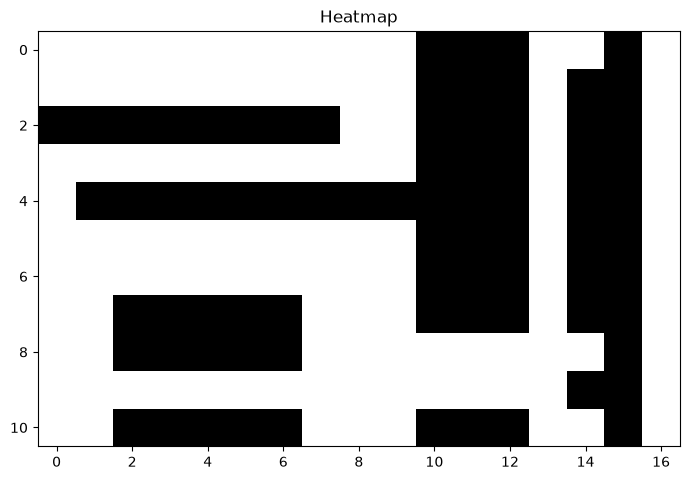

In [262]:
m = MCLmap([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
            [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
            [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
            [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
            [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
            [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0]])

heatmap(m.m, cmap='binary')

Let's define the motion model as a function `P_motion_sample`.

แบบจำลองการเคลื่อนที่และเซนเซอร์:
- Motion model: ใช้ความเร็วเชิงเส้น/มุม พร้อมค่าความไม่แน่นอน เพื่อแพร่อนุภาค
- Sensor model: เปรียบเทียบ range scan ที่คาดจากแผนที่กับค่าที่วัดจริง เพื่อคำนวณ likelihood
การประเมินผล: วัด error ของตำแหน่งโดยใช้ค่าเฉลี่ย/มัธยฐานของอนุภาค หรือ MAP estimate

In [263]:
def P_motion_sample(kin_state, v, w):
    """Sample from possible kinematic states.
    Returns from a single element distribution (no uncertainity in motion)"""
    pos = kin_state[:2]
    orient = kin_state[2]

    # for simplicity the robot first rotates and then moves
    orient = (orient + w)%4
    for _ in range(orient):
        v = (v[1], -v[0])
    pos = vector_add(pos, v)
    return pos + (orient,)

Define the sensor model as a function `P_sensor`.

การใช้แผนที่และการคำนวณ likelihood:
- แผนที่แสดงผนัง/พื้นที่โล่ง ใช้สำหรับ ray casting เพื่อคาดคะเนระยะเซนเซอร์
- เปรียบเทียบค่าคาดกับค่าจริงเพื่อให้คะแนน (เช่น Gaussian error)
- รักษา normalizing constant และจัดการเซนเซอร์ noise

In [264]:
def P_sensor(x, y):
    """Conditional probability for sensor reading"""
    # Need not be exact probability. Can use a scaled value.
    if x == y:
        return 0.8
    elif abs(x - y) <= 2:
        return 0.05
    else:
        return 0

Initializing variables.

การรันและการแสดงผล:
- เริ่มด้วยอนุภาคสุ่มทั่วแผนที่หรือบริเวณเริ่มต้นที่เชื่อถือได้
- ทำซ้ำ motion→sensor→resample หลายสtep พร้อมบันทึก trajectory ที่ประมาณได้
- แสดงผลด้วยการกระจายอนุภาคและเส้นทางประมาณ เพื่อให้เห็นการหดตัวสู่ตำแหน่งจริง

In [265]:
a = {'v': (0, 0), 'w': 0}
z = (2, 4, 1, 6)

Let's run `monte_carlo_localization` with these parameters to find a sample distribution S.

In [266]:
S = monte_carlo_localization(a, z, 1000, P_motion_sample, P_sensor, m)

Let's plot the values in the sample distribution `S`.

GRID:
  0   0   2    55   40     0     1    0   0   0   0   0   0   0   0   0   0
  0   0   0     1    7   151   156   13   0   0   0   0   0   0   0   0   0
  0   0   0     0    0     0     0    0   0   0   0   0   0   0   0   0   0
  0   0   0    11    7     6    11    1   0   0   0   0   0   0   0   0   0
  0   0   0     0    0     0     0    0   0   0   0   0   0   0   0   0   0
  0   0   3   143   47     1     0    0   0   0   0   0   0   0   0   0   0
  0   0   0     1   22    59   129    0   0   0   0   0   0   0   0   0   0
101   3   0     0    0     0     0    0   1   0   0   0   0   0   0   0   0
  0   0   0     0    0     0     0    0   0   0   0   0   0   0   0   0   0
  0   0   0    14    0    14     0    0   0   0   0   0   0   0   0   0   0
  0   0   0     0    0     0     0    0   0   0   0   0   0   0   0   0   0


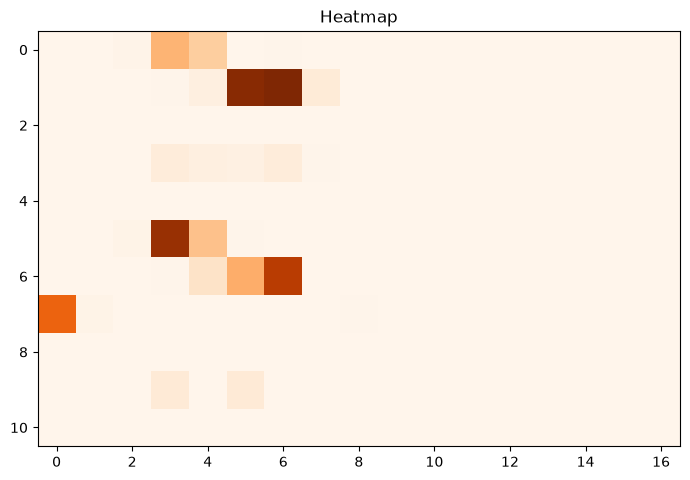

In [267]:
grid = [[0]*17 for _ in range(11)]
for x, y, _ in S:
    if 0 <= x < 11 and 0 <= y < 17:
        grid[x][y] += 1
print("GRID:")
print_table(grid)
heatmap(grid, cmap='Oranges')

The distribution is highly concentrated at `(5, 3)`, but the robot is not very confident about its position as some other cells also have high probability values.

Let's look at another scenario.

GRID:
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   1000   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0   0


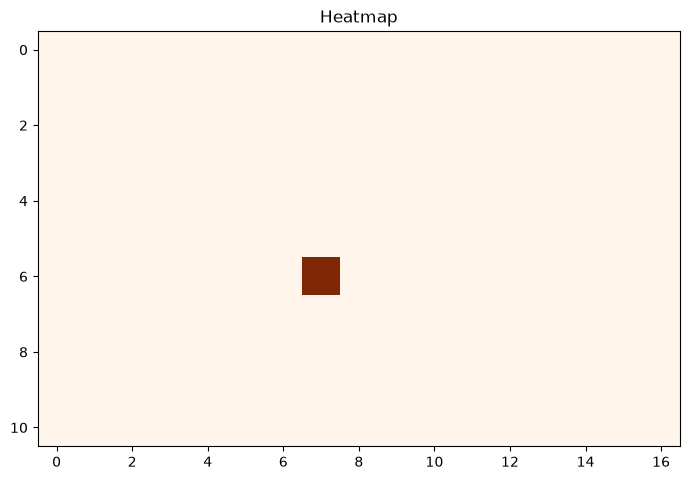

In [268]:
a = {'v': (0, 1), 'w': 0}
z = (2, 3, 5, 7)
S = monte_carlo_localization(a, z, 1000, P_motion_sample, P_sensor, m, S)
grid = [[0]*17 for _ in range(11)]
for x, y, _ in S:
    if 0 <= x < 11 and 0 <= y < 17:
        grid[x][y] += 1
print("GRID:")
print_table(grid)
heatmap(grid, cmap='Oranges')

In this case, the robot is 99.9% certain that it is at position `(6, 7)`.

## DECISION THEORETIC AGENT
We now move into the domain of probabilistic decision making.
<br>
To make choices between different possible plans in a certain situation in a given environment, an agent must have _preference_ between the possible outcomes of the various plans.
<br>
__Utility theory__ is used to represent and reason with preferences.
The agent prefers states with a higher _utility_.
While constructing multi-agent systems, one major element in the design is the mechanism the agents use for making decisions about which actions to adopt in order to achieve their goals.
What is usually required is a mechanism which ensures that the actions adopted lead to benefits for both individual agents, and the community of which they are part.
The utility of a state is _relative_ to an agent.
<br>
Preferences, as expressed by utilities, are combined with probabilities in the general theory of rational decisions called __decision theory__.
<br>
An agent is said to be _rational_ if and only if it chooses the action that yields the highest expected utility, averaged over all the possible outcomes of the action.

ตัวแทนเชิงทฤษฎีการตัดสินใจ (Decision-Theoretic Agent)
รวมความไม่แน่นอน (probabilistic belief) กับค่าสาธารณูปโภค (utility) และความชอบเสี่ยง เพื่อเลือกการกระทำที่คาดว่ามีค่าสาธารณูปโภคคาดหวังสูงสุด (MEU)

Here we'll see how a decision-theoretic agent is implemented in the module.

โครงแบบโปรแกรมตัวแทน (DTAgentProgram):
- เก็บแบบจำลองสถานะ/ผลลัพธ์และอรรถประโยชน์ของผลลัพธ์
- คำนวณ Expected Utility ของการกระทำจากความเชื่อและแบบจำลองโลก
- เลือกการกระทำที่เพิ่มค่าสาธารณูปโภคคาดหวังสูงสุด

In [269]:
psource(DTAgentProgram)

The `DTAgentProgram` function is pretty self-explanatory.
<br>
It encapsulates a function `program` that takes in an observation or a `percept`, updates its `belief_state` and returns the action that maximizes the `expected_outcome_utility`.

เครือข่ายการตัดสินใจ (Decision Network) และ VPI:
- Decision Network ขยาย Bayesian Network ด้วยโหนดการตัดสินใจและอรรถประโยชน์ เพื่อคำนวณ MEU
- Value of Perfect Information (VPI): มูลค่าที่คาดได้จากการรับข้อมูลเพิ่มก่อนตัดสินใจ ใช้เปรียบเทียบความคุ้มค่าในการสำรวจข้อมูล

## INFORMATION GATHERING AGENT
Before we discuss what an information gathering agent is, we'll need to know what decision networks are.
For an agent in an environment, a decision network represents information about the agent's current state, its possible actions, the state that will result from the agent's action, and the utility of that state.
Decision networks have three primary kinds of nodes which are:
1. __Chance nodes__: These represent random variables, just like in Bayesian networks.
2. __Decision nodes__: These represent points where the decision-makes has a choice between different actions and the decision maker tries to find the optimal decision at these nodes with regard to the cost, safety and resulting utility.
3. __Utility nodes__: These represent the agent's utility function.
A description of the agent's utility as a function is associated with a utility node.
<br>
<br>
To evaluate a decision network, we do the following:
1. Initialize the evidence variables according to the current state.
2. Calculate posterior probabilities for each possible value of the decision node and calculate the utility resulting from that action.
3. Return the action with the highest utility.
<br>
Let's have a look at the implementation of the `DecisionNetwork` class.

ตัวแทนแสวงหาข้อมูล (Information-Gathering Agent)
วางแผนว่าจะสังเกต/ทดสอบอะไรเพิ่มก่อนตัดสินใจ เพื่อเพิ่มค่าสาธารณูปโภคคาดหวังโดยรวม โดยคำนึงถึงต้นทุนของการวัดและผลที่เป็นไปได้

In [270]:
psource(DecisionNetwork)

The `DecisionNetwork` class inherits from `BayesNet` and has a few extra helper methods.
<br>
`best_action` returns the best action in the network.
<br>
`get_utility` is an abstract method which is supposed to return the utility of a particular action and state in the network.
<br>
`get_expected_utility` computes the expected utility, given an action and evidence.
<br>

แรงบันดาลใจและความเชื่อมโยงกับ Decision Networks:
- ใช้เครือข่ายการตัดสินใจเพื่อประเมินผลของการสังเกตที่เป็นไปได้
- เลือกลำดับการสังเกตที่เพิ่ม MEU โดยพิจารณาค่าใช้จ่ายและเวลาที่จำกัด

Before we proceed, we need to know a few more terms.
<br>
Having __perfect information__ refers to a state of being fully aware of the current state, the cost functions and the outcomes of actions.
This in turn allows an agent to find the exact utility value of each state.
If an agent has perfect information about the environment, maximum expected utility calculations are exact and can be computed with absolute certainty.
<br>
In decision theory, the __value of perfect information__ (VPI) is the price that an agent would be willing to pay in order to gain access to _perfect information_.
VPI calculations are extensively used to calculate expected utilities for nodes in a decision network.
<br>
For a random variable $E_j$ whose value is currently unknown, the value of discovering $E_j$, given current information $e$ must average over all possible values $e_{jk}$ that we might discover for $E_j$, using our _current_ beliefs about its value.
The VPI of $E_j$ is then given by:
<br>
<br>
$$VPI_e(E_j) = \left(\sum_{k}P(E_j=e_{jk}\ |\ e) EU(\alpha_{e_{jk}}\ |\ e, E_j=e_{jk})\right) - EU(\alpha\ |\ e)$$
<br>
VPI is _non-negative_, _non-additive_ and _order-indepentent_.

โครงสร้างชั้นเรียนสำคัญ:
- `DecisionNetwork`: โหนดสุ่ม + โหนดตัดสินใจ + โหนดอรรถประโยชน์ พร้อมเมธอดช่วยคำนวณ MEU
- `InformationGatheringAgent`: วางแผนการสังเกตและตัดสินใจโดยใช้ `evaluate_meu` เพื่อประเมินค่าสาธารณูปโภคคาดหวังภายใต้ลำดับการสังเกต

An information gathering agent is an agent with certain properties that explores decision networks as and when required with heuristics driven by VPI calculations of nodes.
A sensible agent should ask questions in a reasonable order, should avoid asking irrelevant questions, should take into account the importance of each piece of information in relation to its cost and should stop asking questions when that is appropriate.
_VPI_ is used as the primary heuristic to consider all these points in an information gathering agent as the agent ultimately wants to maximize the utility and needs to find the optimal cost and extent of finding the required information.
<br>
As an overview, an information gathering agent works by repeatedly selecting the observations with the highest information value, until the cost of the next observation is greater than its expected benefit.
<br>
The `InformationGatheringAgent` class is an abstract class that inherits from `Agent` and works on the principles discussed above.
Let's have a look.
<br>

สัญชาตญาณของ VPI และการตัดสินใจสืบค้น:
- หากต้นทุนการวัดต่ำและข้อมูลช่วยแยกแยะการกระทำได้ดี ควรสืบค้นก่อนตัดสินใจ
- หากความไม่แน่นอนต่ำหรือข้อมูลใหม่ไม่ช่วยปรับการตัดสินใจมาก การสืบค้นอาจไม่คุ้มค่า

In [271]:
psource(InformationGatheringAgent)

The `cost` method is an abstract method that returns the cost of obtaining the evidence through tests, consultants, questions or any other means.
<br>
The `request` method returns the value of the given random variable as the next percept.
<br>
The `vpi_cost_ratio` method returns a list of VPI divided by cost for each variable in the `variables` list provided to it.
<br>
The `vpi` method calculates the VPI for a given variable
<br>
And finally, the `execute` method executes the general information gathering algorithm, as described in __figure 16.9__ in the book.
<br>
Our agent implements a form of information gathering that is called __myopic__ as the VPI formula is used shortsightedly here.
It calculates the value of information as if only a single evidence variable will be acquired.
This is similar to greedy search, where we do not look at the bigger picture and aim for local optimizations to hopefully reach the global optimum.
This often works well in practice but a myopic agent might hastily take an action when it would have been better to request more variables before taking an action.
A _conditional plan_, on the other hand might work better for some scenarios.
<br>


สรุปท้ายบท:
เราได้ครอบคลุมการอนุมานเชิงความน่าจะเป็น ทั้งแบบแม่นยำและประมาณ การให้เหตุผลเหนือเวลา (HMM) การระบุตำแหน่งด้วย MCL และตัวแทนที่คำนึงถึงอรรถประโยชน์และการสืบค้นข้อมูล หวังว่าเนื้อหานี้จะช่วยให้เข้าใจการประยุกต์ใช้ความน่าจะเป็นใน AI ได้อย่างเป็นระบบ

With this we conclude this notebook.

---
---
# 🏭 ภาคผนวก: การประยุกต์ใช้ในอุตสาหกรรม (HMM ถึง Information Gathering Agent)

ส่วนนี้ร้อยเรียงทุกเทคนิคตั้งแต่ HIDDEN MARKOV MODELS จนถึง INFORMATION GATHERING AGENT
เข้ากับ **โจทย์เดียวที่ต่อเนื่องกัน** เพื่อให้เห็นว่าแต่ละอัลกอริทึมทำหน้าที่อะไรในระบบจริง

## โจทย์: ระบบ Predictive Maintenance ของโรงงาน

บริษัทเดินสายการผลิตด้วยปั๊มอุตสาหกรรมและมี AGV (รถลำเลียงอัตโนมัติ) วิ่งในคลัง
ทีมวิศวกรรมต้องการระบบซอฟต์แวร์ที่ตอบคำถามเหล่านี้แบบอัตโนมัติ

| คำถามทางธุรกิจ | เทคนิคในบทนี้ | ฟังก์ชันที่ใช้ |
|---|---|---|
| ตอนนี้ปั๊มกำลังเสื่อมสภาพอยู่หรือไม่ | Filtering | `forward` |
| เครื่องเริ่มเสื่อมตั้งแต่กะไหน (สอบสวนย้อนหลัง) | Smoothing | `forward` + `backward` |
| ลำดับสถานะที่เป็นไปได้มากที่สุดคืออะไร | MPE / Viterbi | `viterbi` |
| Dashboard ควรหน่วงกี่กะเพื่อแลกความแม่นยำ | Fixed lag smoothing | สูตรเดียวกันบนหน้าต่างเลื่อน |
| ระดับการสึกหรอเป็นตัวเลขต่อเนื่องเท่าไร | Particle filtering | `weighted_sample_with_replacement` |
| AGV อยู่ตรงไหนในคลัง | Monte Carlo Localization | `monte_carlo_localization` |
| ควรหยุดซ่อมเดี๋ยวนี้หรือรอถึงแผน PM | Decision theoretic agent | MEU |
| คุ้มไหมที่จะจ่ายค่าตรวจเพิ่มก่อนตัดสินใจ | Information gathering agent | VPI |

ทุกเซลล์ในภาคผนวกนี้รันได้จริงและมี `assert` ตรวจความถูกต้องไว้ในจุดสำคัญ

## ส่วนที่ 1: ติดตามสุขภาพเครื่องจักรด้วย HMM

**ตัวแปรสถานะซ่อน** `X_t` คือสภาพจริงของปั๊มในกะที่ t มีสองค่า: `Healthy` (index 0) กับ `Degraded` (index 1)
เราไม่มีทางรู้ค่าจริงโดยไม่ถอดเครื่อง

**หลักฐานที่สังเกตได้** `E_t` คือเซ็นเซอร์สั่นสะเทือนแจ้งเตือนหรือไม่ (`True` / `False`)

**Transition model** สะท้อนฟิสิกส์ของการสึกหรอ: เครื่องดีอาจเสื่อมได้ 5% ต่อกะ
แต่เครื่องที่เสื่อมแล้ว **ไม่หายเอง** (มีเพียง 2% ที่กลับมาปกติจากการปรับตั้งย่อย)
นี่คือ absorbing-ish chain ซึ่งต่างจากตัวอย่างร่มที่ฝนหยุดตกเองได้

**Sensor model** สะท้อนคุณภาพเซ็นเซอร์: false alarm 10% และตรวจจับได้ 80% เมื่อเครื่องเสื่อมจริง

$$P(E_t = alert \mid X_t = Healthy) = 0.10 \qquad P(E_t = alert \mid X_t = Degraded) = 0.80$$

In [272]:
import random
import matplotlib.pyplot as plt

# index 0 = Healthy, index 1 = Degraded
maint_transition = [[0.95, 0.05],    # จาก Healthy ไป [Healthy, Degraded]
                    [0.02, 0.98]]    # จาก Degraded ไป [Healthy, Degraded]

maint_sensor = [[0.10, 0.80],        # P(alert=True  | [Healthy, Degraded])
                [0.90, 0.20]]        # P(alert=False | [Healthy, Degraded])

maint_prior = [0.98, 0.02]           # เพิ่งผ่าน PM มา จึงมั่นใจว่าเครื่องดี

pump = HiddenMarkovModel(maint_transition, maint_sensor, maint_prior)

# บันทึกการแจ้งเตือนจริง 10 กะ (T = เซ็นเซอร์แจ้งเตือน)
alerts = [F, F, F, T, F, T, T, T, T, T]

belief = maint_prior
filtered = []
print('กะ  alert   P(Degraded)  สถานะที่ระบบรายงาน')
print('-' * 52)
for t, ev in enumerate(alerts, start=1):
    belief = forward(pump, belief, ev)
    filtered.append(float(belief[1]))
    flag = 'ALARM' if belief[1] > 0.5 else 'ok'
    print('%2d  %-6s  %10.4f   %s' % (t, 'alert' if ev else '-', belief[1], flag))

กะ  alert   P(Degraded)  สถานะที่ระบบรายงาน
----------------------------------------------------
 1  -           0.0161   ok
 2  -           0.0152   ok
 3  -           0.0150   ok
 4  alert       0.3534   ok
 5  -           0.1193   ok
 6  alert       0.6054   ALARM
 7  alert       0.9269   ALARM
 8  alert       0.9881   ALARM
 9  alert       0.9960   ALARM
10  alert       0.9970   ALARM


สังเกตพฤติกรรมสำคัญ 2 อย่างที่ระบบมอนิเตอร์จริงต้องเจอ

1. **กะที่ 4 มี alert แต่ระบบยังไม่ฟันธง** (P = 0.35) เพราะ prior บอกว่าเครื่องเพิ่งผ่าน PM
   และเซ็นเซอร์มี false alarm 10% นี่คือ Bayes ทำงาน: หลักฐานเดียวไม่ล้ม prior ที่แข็งแรง
2. **กะที่ 5 ไม่มี alert ความเชื่อลดกลับลงเหลือ 0.12** แล้วพุ่งขึ้นเมื่อ alert มาติดกัน
   ระบบจะข้ามเกณฑ์ 0.5 ที่กะ 6 ถึง 7

ถ้าใช้กฎง่าย ๆ แบบ "alert ครั้งเดียวให้หยุดเครื่อง" โรงงานจะหยุดสายการผลิตเก้อที่กะ 4
ถ้าใช้ "alert 3 ครั้งติด" ก็จะเสียเวลาไปเปล่า ๆ เมื่อ alert ขาดช่วง
HMM ให้ตัวเลขความน่าจะเป็นที่เอาไปเข้าสูตรต้นทุนได้ ซึ่งเราจะทำในส่วนที่ 5

### 1.2 สอบสวนย้อนหลัง: Smoothing และ Viterbi

หลังเกิดเหตุ ทีมวิศวกรต้องเขียนรายงาน root cause ว่า **เครื่องเริ่มเสื่อมตั้งแต่กะไหน**
คำถามนี้คือ $P(X_k \mid e_{1:t})$ เมื่อ $k < t$ ซึ่งก็คือ smoothing

> **หมายเหตุสำคัญ:** ฟังก์ชัน `forward_backward` ในโมดูลคืนลำดับผลลัพธ์ **กลับหัว**
> (index 1 คือเวลาสุดท้าย ไม่ใช่เวลาแรก) เราจึงเขียน `smooth()` เองจาก `forward` และ `backward`
> ซึ่งสั้นเพียง 6 บรรทัด และตรวจสอบด้วย invariant ที่ต้องเป็นจริงเสมอ:
> ค่า smoothed ที่เวลาสุดท้ายต้องเท่ากับค่า filtered ที่เวลาสุดท้ายพอดี เพราะไม่มีอนาคตให้มองย้อน

In [273]:
def smooth(hmm, ev):
    # คืนลิสต์ sv โดย sv[k] = P(X_{k+1} | e_1..e_n)  (forward-backward, AIMA รูป 15.4)
    fv = [hmm.prior]
    for e in ev:
        fv.append(forward(hmm, fv[-1], e))
    b = [1.0, 1.0]
    sv = [None] * len(ev)
    for i in range(len(ev) - 1, -1, -1):
        sv[i] = normalize(element_wise_product(fv[i + 1], b))
        b = backward(hmm, b, ev[i])
    return sv


# ตรวจกับตัวอย่างร่มในหนังสือ: P(Rain_1 | u_1, u_2) = 0.8834
umbrella = HiddenMarkovModel([[0.7, 0.3], [0.3, 0.7]], [[0.9, 0.2], [0.1, 0.8]], [0.5, 0.5])
assert abs(smooth(umbrella, [T, T])[0][0] - 0.8834) < 1e-4, 'smooth ไม่ตรงกับค่าในหนังสือ'

smoothed = [float(s[1]) for s in smooth(pump, alerts)]
# invariant: เวลาสุดท้ายไม่มีอนาคตให้มองย้อน ค่าจึงต้องเท่ากับ filtering เป๊ะ
assert abs(smoothed[-1] - filtered[-1]) < 1e-12

ml_path, _ = viterbi(pump, alerts.copy())   # True = Healthy ตามธรรมเนียมของโมดูล

print('กะ  alert  filtered  smoothed  viterbi')
print('-' * 46)
for t in range(len(alerts)):
    print('%2d  %-5s  %8.4f  %8.4f  %s'
          % (t + 1, 'alert' if alerts[t] else '-', filtered[t], smoothed[t],
             'Healthy' if ml_path[t] else 'Degraded'))

detect_online = next(t for t, p in enumerate(filtered, 1) if p > 0.5)
detect_offline = next(t for t, p in enumerate(smoothed, 1) if p > 0.5)
print('\nระบบเตือนจริงที่กะ %d (real time)' % detect_online)
print('แต่ผลสอบสวนย้อนหลังชี้ว่าเครื่องเสื่อมตั้งแต่กะ %d' % detect_offline)
print('detection delay = %d กะ  <-- ตัวชี้วัดที่ทีมวิศวกรรมใช้ประเมินระบบมอนิเตอร์'
      % (detect_online - detect_offline))

กะ  alert  filtered  smoothed  viterbi
----------------------------------------------
 1  -        0.0161    0.0216  Healthy
 2  -        0.0152    0.0824  Healthy
 3  -        0.0150    0.3028  Healthy
 4  alert    0.3534    0.8186  Degraded
 5  -        0.1193    0.8535  Degraded
 6  alert    0.6054    0.9850  Degraded
 7  alert    0.9269    0.9980  Degraded
 8  alert    0.9881    0.9995  Degraded
 9  alert    0.9960    0.9994  Degraded
10  alert    0.9970    0.9970  Degraded

ระบบเตือนจริงที่กะ 6 (real time)
แต่ผลสอบสวนย้อนหลังชี้ว่าเครื่องเสื่อมตั้งแต่กะ 4
detection delay = 2 กะ  <-- ตัวชี้วัดที่ทีมวิศวกรรมใช้ประเมินระบบมอนิเตอร์


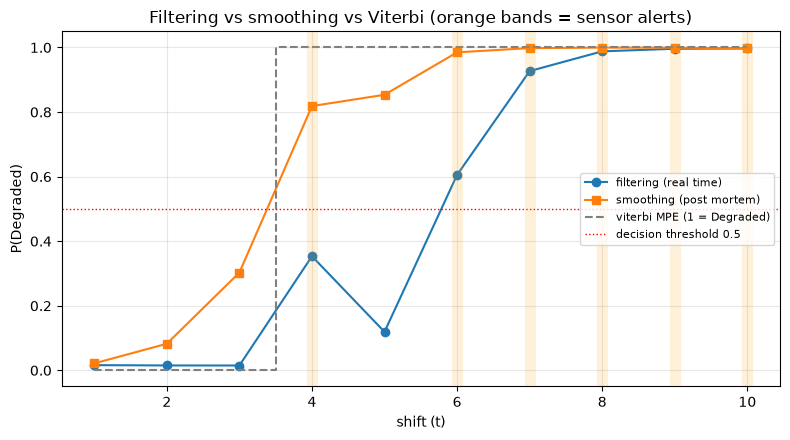

In [274]:
shifts = range(1, len(alerts) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(shifts, filtered, marker='o', label='filtering (real time)')
plt.plot(shifts, smoothed, marker='s', label='smoothing (post mortem)')
plt.step(shifts, [0 if h else 1 for h in ml_path], where='mid',
         linestyle='--', color='gray', label='viterbi MPE (1 = Degraded)')
plt.axhline(0.5, color='red', linestyle=':', linewidth=1, label='decision threshold 0.5')
for t, ev in zip(shifts, alerts):
    if ev:
        plt.axvline(t, color='orange', alpha=0.15, linewidth=8)
plt.xlabel('shift (t)')
plt.ylabel('P(Degraded)')
plt.title('Filtering vs smoothing vs Viterbi (orange bands = sensor alerts)')
plt.legend(loc='center right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**อ่านกราฟให้เป็น**

- เส้น filtering ตอบคำถาม "ตอนนี้เป็นยังไง" ใช้ได้กับ alarm system ที่ต้องตัดสินใจทันที
- เส้น smoothing สูงกว่าตั้งแต่กะแรก ๆ เพราะ **มองเห็นอนาคตแล้ว** ใช้กับรายงาน root cause
  และการทำ label ข้อมูลย้อนหลังเพื่อเทรนโมเดล ML
- เส้น Viterbi ให้ลำดับสถานะที่สอดคล้องกันทั้งเส้น ไม่ใช่การเอาค่าสูงสุดของแต่ละจุดมาต่อกัน
  เหมาะกับงานที่ต้องการ "เรื่องเล่าเดียวที่เป็นไปได้ที่สุด" เช่น การ reconstruct เหตุการณ์ในรายงานอุบัติเหตุ

**กับดักที่พบบ่อยในงานจริง:** อย่าเอา smoothing ไปใช้ใน production monitoring
เพราะมันใช้ข้อมูลอนาคตซึ่งตอนรันจริงยังไม่เกิดขึ้น นี่คือ data leakage รูปแบบหนึ่ง

## ส่วนที่ 2: Fixed lag smoothing กับการออกแบบ SLA ของ Dashboard

ในทางปฏิบัติเราไม่ต้องเลือกสุดโต่งระหว่าง filtering (lag 0) กับ smoothing (รอจนจบงาน)
Dashboard ของโรงงานมักยอม **หน่วงผล d กะ** เพื่อแลกกับความแม่นยำที่สูงขึ้น
นั่นคือรายงาน $P(X_{t-d} \mid e_{1:t})$ ซึ่งเรียกว่า fixed lag smoothing

> ฟังก์ชัน `fixed_lag_smoothing` ในโมดูลรีเซ็ต `f = HMM.prior` ทุกครั้งที่เรียก
> จึงใช้แบบสะสมสถานะข้ามเวลาไม่ได้ (ลองอ่านโค้ดด้วย `psource(fixed_lag_smoothing)`)
> ที่นี่เราจึงคำนวณตรงตามนิยามด้วย `smooth()` บนหน้าต่างข้อมูลที่มีถึงเวลา t
> ช้ากว่าแต่ถูกต้อง และเห็น trade-off ชัดกว่า

In [275]:
def fixed_lag(hmm, ev_so_far, d):
    # คืน P(X_{t-d} | e_1..e_t) เมื่อ t = len(ev_so_far); คืน None ถ้าข้อมูลยังไม่พอ
    t = len(ev_so_far)
    if t - d < 1:
        return None
    return float(smooth(hmm, ev_so_far)[t - d - 1][1])


print('รายงาน P(Degraded) ของกะที่ (t - d) เมื่อข้อมูลมาถึงกะ t')
print('%4s | %s' % ('t', ' | '.join('d=%d' % d for d in range(4))))
print('-' * 40)
for t in range(1, len(alerts) + 1):
    row = []
    for d in range(4):
        v = fixed_lag(pump, alerts[:t], d)
        row.append('  -  ' if v is None else '%.3f' % v)
    print('%4d | %s' % (t, ' | '.join(row)))

print('\nกะแรกที่รายงานว่าเสื่อม (P > 0.5) โดยนับเป็น "เวลาจริงของสถานะนั้น"')
for d in range(4):
    hit = None
    for t in range(1, len(alerts) + 1):
        v = fixed_lag(pump, alerts[:t], d)
        if v is not None and v > 0.5:
            hit = t - d
            break
    print('  lag d=%d -> ตรวจพบว่าสถานะกะที่ %s เสื่อม (รู้ผลตอนกะ %s)'
          % (d, hit, None if hit is None else hit + d))

รายงาน P(Degraded) ของกะที่ (t - d) เมื่อข้อมูลมาถึงกะ t
   t | d=0 | d=1 | d=2 | d=3
----------------------------------------
   1 | 0.016 |   -   |   -   |   -  
   2 | 0.015 | 0.005 |   -   |   -  
   3 | 0.015 | 0.004 | 0.002 |   -  
   4 | 0.353 | 0.098 | 0.025 | 0.007
   5 | 0.119 | 0.133 | 0.033 | 0.009
   6 | 0.605 | 0.490 | 0.471 | 0.139
   7 | 0.927 | 0.916 | 0.784 | 0.750
   8 | 0.988 | 0.989 | 0.976 | 0.845
   9 | 0.996 | 0.998 | 0.997 | 0.984
  10 | 0.997 | 0.999 | 1.000 | 0.998

กะแรกที่รายงานว่าเสื่อม (P > 0.5) โดยนับเป็น "เวลาจริงของสถานะนั้น"
  lag d=0 -> ตรวจพบว่าสถานะกะที่ 6 เสื่อม (รู้ผลตอนกะ 6)
  lag d=1 -> ตรวจพบว่าสถานะกะที่ 6 เสื่อม (รู้ผลตอนกะ 7)
  lag d=2 -> ตรวจพบว่าสถานะกะที่ 5 เสื่อม (รู้ผลตอนกะ 7)
  lag d=3 -> ตรวจพบว่าสถานะกะที่ 4 เสื่อม (รู้ผลตอนกะ 7)


นี่คือบทสนทนาที่เกิดขึ้นจริงในการออกแบบระบบ

- ทีม Operations อยากได้ lag = 0 เพราะต้องกดหยุดเครื่องทันที
- ทีม Quality อยากได้ lag มาก ๆ เพราะการหยุดสายผลิตผิดพลาดหนึ่งครั้งแพงกว่า

คำตอบทางวิศวกรรมคือ **ทำทั้งสองอย่างพร้อมกัน**: ส่ง lag 0 เข้า alarm system
และส่ง lag 2 ถึง 3 เข้า dashboard สำหรับตัดสินใจวางแผนซ่อม
ตัวเลข lag ที่เหมาะสมหาได้จากการรันย้อนหลังบนข้อมูลจริง ซึ่งคือแบบฝึกหัดข้อ 2

## ส่วนที่ 3: Particle filtering เมื่อสถานะเป็นตัวเลขต่อเนื่อง

HMM ข้างบนบีบสภาพเครื่องให้เหลือ 2 ค่า ซึ่งพอสำหรับ alarm แต่ไม่พอสำหรับวางแผนอะไหล่
ทีมวางแผนอยากรู้ **ระดับการสึกหรอ** $w_t \in [0, 1]$ เป็นตัวเลขต่อเนื่อง เพื่อประเมิน
Remaining Useful Life (RUL) ว่าเหลืออีกกี่กะก่อนถึงเกณฑ์เปลี่ยนอะไหล่ที่ $w = 0.9$

สถานะต่อเนื่องทำให้ตารางความน่าจะเป็นแบบ HMM ใช้ไม่ได้ จึงต้องใช้ particle filter

- **Transition:** $w_t = w_{t-1} + \max(0, \mathcal{N}(0.06,\ 0.02))$ สึกหรอเพิ่มขึ้นอย่างเดียว ไม่ลดลง
- **Sensor:** อุณหภูมิตลับลูกปืน $z_t = 30 + 60 w_t + \mathcal{N}(0, 6)$ องศาเซลเซียส
- **Weight:** ใช้ `gaussian(mu, sigma, x)` ที่มีอยู่แล้วในโมดูลเป็น likelihood
- **Resample:** ใช้ `weighted_sample_with_replacement` จาก `utils`

`particle_filtering` ในโมดูลรองรับเฉพาะ 2 สถานะ (`'A'` และ `'B'`) จึงใช้กับโจทย์นี้ไม่ได้
แต่แนวคิด predict, weight, resample เหมือนกันทุกประการ เขียนเองได้ในไม่กี่บรรทัด

In [276]:
from utils import weighted_sample_with_replacement

WEAR_STEP_MEAN, WEAR_STEP_SD = 0.06, 0.02
TEMP_BASE, TEMP_GAIN, TEMP_SD = 30.0, 60.0, 6.0


def simulate_pump(n_shifts=12, seed=7):
    # สร้างข้อมูลจริงที่ระบบไม่มีวันเห็น เอาไว้ตรวจว่า particle filter ตามทันหรือไม่
    random.seed(seed)
    w, truth, obs = 0.05, [], []
    for _ in range(n_shifts):
        w = min(1.0, w + max(0.0, random.gauss(WEAR_STEP_MEAN, WEAR_STEP_SD)))
        truth.append(w)
        obs.append(TEMP_BASE + TEMP_GAIN * w + random.gauss(0, TEMP_SD))
    return truth, obs


def wear_particle_filter(obs, N=3000, seed=1):
    random.seed(seed)
    particles = [random.uniform(0.0, 0.12) for _ in range(N)]   # prior หลัง PM
    mean, lo, hi = [], [], []
    for z in obs:
        # 1. PREDICT
        particles = [min(1.0, w + max(0.0, random.gauss(WEAR_STEP_MEAN, WEAR_STEP_SD)))
                     for w in particles]
        # 2. WEIGHT
        weights = [gaussian(TEMP_BASE + TEMP_GAIN * w, TEMP_SD, z) for w in particles]
        total = sum(weights)
        weights = [w / total for w in weights] if total > 0 else [1.0 / N] * N
        # 3. RESAMPLE
        particles = weighted_sample_with_replacement(N, particles, weights)
        s = sorted(particles)
        mean.append(sum(particles) / N)
        lo.append(s[int(0.05 * N)])
        hi.append(s[int(0.95 * N)])
    return mean, lo, hi


truth, obs = simulate_pump()
est, lo, hi = wear_particle_filter(obs)

print('กะ   temp(C)   wear จริง   ประมาณ   ช่วง 90%')
print('-' * 52)
for t in range(len(truth)):
    print('%2d   %7.1f   %8.3f   %6.3f   [%.3f, %.3f]'
          % (t + 1, obs[t], truth[t], est[t], lo[t], hi[t]))

coverage = sum(1 for t in range(len(truth)) if lo[t] <= truth[t] <= hi[t])
print('\ncalibration: ค่าจริงตกอยู่ในช่วง 90%% จำนวน %d จาก %d กะ' % (coverage, len(truth)))
assert coverage >= len(truth) * 0.7, 'ช่วงความเชื่อมั่นแคบเกินไป โมเดลอาจ overconfident'

shifts_left = (0.9 - est[-1]) / WEAR_STEP_MEAN
print('RUL ประมาณ %.1f กะ ก่อนถึงเกณฑ์เปลี่ยนอะไหล่ที่ wear = 0.9' % shifts_left)

กะ   temp(C)   wear จริง   ประมาณ   ช่วง 90%
----------------------------------------------------
 1      39.4      0.105    0.126   [0.063, 0.183]
 2      37.7      0.160    0.177   [0.115, 0.241]
 3      40.8      0.202    0.229   [0.166, 0.294]
 4      49.6      0.284    0.294   [0.229, 0.364]
 5      53.4      0.365    0.360   [0.293, 0.430]
 6      57.1      0.433    0.425   [0.359, 0.492]
 7      62.7      0.459    0.496   [0.430, 0.567]
 8      64.8      0.529    0.561   [0.493, 0.633]
 9      52.9      0.556    0.578   [0.507, 0.646]
10      63.1      0.598    0.622   [0.551, 0.689]
11      69.6      0.664    0.678   [0.606, 0.742]
12      70.2      0.734    0.727   [0.655, 0.798]

calibration: ค่าจริงตกอยู่ในช่วง 90% จำนวน 12 จาก 12 กะ
RUL ประมาณ 2.9 กะ ก่อนถึงเกณฑ์เปลี่ยนอะไหล่ที่ wear = 0.9


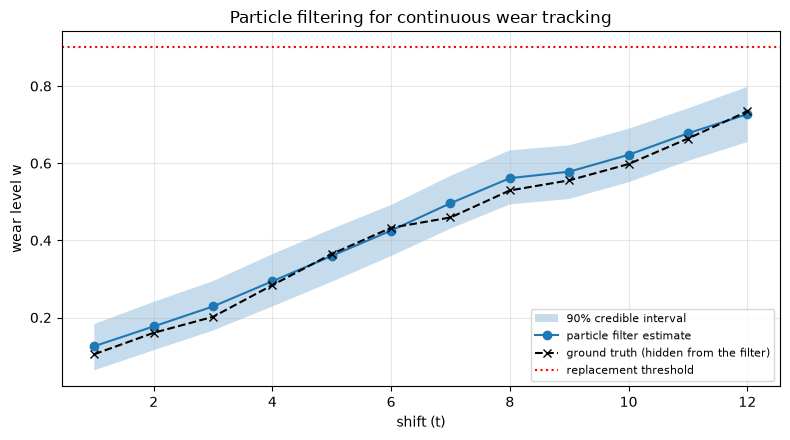

In [277]:
ts = range(1, len(truth) + 1)
plt.figure(figsize=(8, 4.5))
plt.fill_between(ts, lo, hi, alpha=0.25, label='90% credible interval')
plt.plot(ts, est, marker='o', label='particle filter estimate')
plt.plot(ts, truth, marker='x', linestyle='--', color='black', label='ground truth (hidden from the filter)')
plt.axhline(0.9, color='red', linestyle=':', label='replacement threshold')
plt.xlabel('shift (t)')
plt.ylabel('wear level w')
plt.title('Particle filtering for continuous wear tracking')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**ทำไมต้องสนใจแถบสีจาง (credible interval)**

ค่าประมาณจุดเดียวใช้วางแผนอะไหล่ไม่ได้ เพราะการสั่งอะไหล่มี lead time
สิ่งที่ทีมวางแผนต้องการคือ "ความน่าจะเป็นที่เครื่องจะถึงเกณฑ์ภายใน 3 กะข้างหน้า"
ซึ่งอ่านได้จากการกระจายของอนุภาคโดยตรง ไม่ต้องมีสูตรปิดรูป
นี่คือข้อได้เปรียบใหญ่ที่สุดของ particle filter ในงานอุตสาหกรรม

**กับดัก particle depletion:** ถ้า transition model บอกว่าสึกหรอ 0.06 ต่อกะ
แต่ของจริงพุ่ง 0.2 ต่อกะเพราะน้ำมันหล่อลื่นรั่ว อนุภาคทั้งหมดจะตามไม่ทันและช่วงความเชื่อมั่นจะผิด
โดยไม่มีสัญญาณเตือน วิธีตรวจคือดู effective sample size ซึ่งเป็นแบบฝึกหัดข้อ 3

## ส่วนที่ 4: Monte Carlo Localization กับ AGV ในคลังสินค้า

AGV ที่ลำเลียงอะไหล่ไปยังจุดซ่อมต้องรู้ตำแหน่งตัวเอง GPS ใช้ในอาคารไม่ได้
และ odometry (นับรอบล้อ) สะสมความคลาดเคลื่อนเรื่อย ๆ วิธีมาตรฐานในอุตสาหกรรมคือ MCL
ซึ่งก็คือ particle filter บนแผนที่ โดยใช้ LiDAR สี่ทิศเป็นเซ็นเซอร์

`1` ในแผนที่คือชั้นวางของหรือผนัง `0` คือทางเดินที่ AGV วิ่งได้

In [278]:
warehouse = MCLmap([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
                    [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
                    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
                    [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
                    [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


def P_motion_sample(kin_state, v, w):
    # แบบจำลองการเคลื่อนที่: หมุนก่อนแล้วจึงเคลื่อนที่ (ไม่มี noise เพื่อความง่าย)
    pos, orient = kin_state[:2], (kin_state[2] + w) % 4
    for _ in range(orient):
        v = (v[1], -v[0])
    return vector_add(pos, v) + (orient,)


def P_sensor(x, y):
    # likelihood ของระยะที่วัดได้ x เทียบกับระยะที่คาดจากแผนที่ y
    if x == y:
        return 0.8
    elif abs(x - y) <= 2:
        return 0.05
    return 0


def confidence(S, k=3):
    counts = {}
    for x, y, _ in S:
        counts[(x, y)] = counts.get((x, y), 0) + 1
    return [(cell, 100.0 * n / len(S))
            for cell, n in sorted(counts.items(), key=lambda kv: -kv[1])[:k]]


random.seed(11)
N_PARTICLES = 1000

S = monte_carlo_localization({'v': (0, 0), 'w': 0}, (2, 4, 1, 6),
                             N_PARTICLES, P_motion_sample, P_sensor, warehouse)
print('หลัง LiDAR scan ครั้งที่ 1 (AGV ยังไม่เคลื่อนที่)')
for cell, pct in confidence(S):
    print('   %s : %.1f%%' % (cell, pct))

S = monte_carlo_localization({'v': (0, 1), 'w': 0}, (2, 3, 5, 7),
                             N_PARTICLES, P_motion_sample, P_sensor, warehouse, S)
print('\nหลังเคลื่อนที่ 1 ช่องแล้ว scan ครั้งที่ 2')
for cell, pct in confidence(S):
    print('   %s : %.1f%%' % (cell, pct))

หลัง LiDAR scan ครั้งที่ 1 (AGV ยังไม่เคลื่อนที่)
   (6, 5) : 15.8%
   (9, 3) : 11.7%
   (5, 4) : 9.8%

หลังเคลื่อนที่ 1 ช่องแล้ว scan ครั้งที่ 2
   (6, 7) : 100.0%


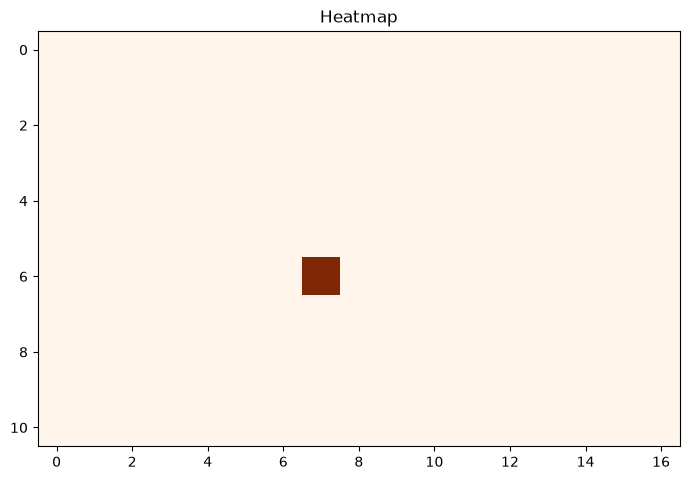

In [279]:
grid = [[0] * warehouse.ncols for _ in range(warehouse.nrows)]
for x, y, _ in S:
    if 0 <= x < warehouse.nrows and 0 <= y < warehouse.ncols:
        grid[x][y] += 1
heatmap(grid, cmap='Oranges')

**บทเรียนเชิงระบบ:** ข้อมูลจากการสแกนครั้งเดียวยังกำกวม เพราะคลังสินค้ามีทางเดินที่ "หน้าตาเหมือนกัน"
หลายจุด (perceptual aliasing) การเคลื่อนที่แค่ช่องเดียวแล้วสแกนซ้ำตัดตัวเลือกทิ้งได้เกือบหมด

นี่คือเหตุผลที่ AGV เชิงพาณิชย์ออกแบบให้ "ขยับเพื่อดู" ไม่ใช่ยืนนิ่งแล้วสแกนซ้ำ ๆ
และมันคือแนวคิดเดียวกับ Information Gathering Agent ในส่วนที่ 6: **การกระทำบางอย่างมีคุณค่าเพราะมันให้ข้อมูล**

## ส่วนที่ 5: Decision Theoretic Agent กับการตัดสินใจหยุดซ่อม

ความน่าจะเป็นอย่างเดียวตัดสินใจไม่ได้ ต้องมีต้นทุน ตัวเลขจริงจากโรงงาน

| | เครื่องเสื่อมจริง | เครื่องปกติ |
|---|---|---|
| **หยุดซ่อมเดี๋ยวนี้** | -50,000 (ซ่อมตามแผน) | -50,000 (หยุดสายผลิตเสียเปล่า) |
| **รอถึง PM รอบหน้า** | -400,000 (พังกลางกะ, ของเสีย, ซ่อมฉุกเฉิน) | 0 |

$$EU(a) = \sum_{s} P(s \mid e)\, U(a, s) \qquad MEU(e) = \max_a EU(a)$$

> คลาส `DecisionNetwork` และ `InformationGatheringAgent` ในโมดูลเป็น abstract class
> ที่ยังไม่สมบูรณ์ (เมธอด `get_utility`, `cost`, `request` โยน `NotImplementedError`
> และ `get_expected_utility` รับ evidence เป็น list ซึ่ง `enumeration_ask` ใช้ไม่ได้)
> ลองอ่านด้วย `psource(DecisionNetwork)` แล้วเปรียบเทียบกับที่เราเขียนตรงตามสูตรข้างบน
> ซึ่งสั้นกว่าและตรวจสอบได้

In [280]:
COST_REPAIR = 50_000       # หยุดซ่อมตามแผน
COST_BREAKDOWN = 400_000   # เครื่องพังกลางกะ

UTILITY = {('repair', True): -COST_REPAIR,   ('repair', False): -COST_REPAIR,
           ('wait',   True): -COST_BREAKDOWN, ('wait',   False): 0}

ACTIONS = ('repair', 'wait')


def expected_utility(action, p_degraded):
    return p_degraded * UTILITY[(action, True)] + (1 - p_degraded) * UTILITY[(action, False)]


def meu(p_degraded):
    # คืน (ค่าอรรถประโยชน์สูงสุด, การกระทำที่ควรเลือก)
    return max((expected_utility(a, p_degraded), a) for a in ACTIONS)


breakeven = COST_REPAIR / COST_BREAKDOWN
print('จุดคุ้มทุน: ควรหยุดซ่อมเมื่อ P(Degraded) > %.3f' % breakeven)
assert abs(expected_utility('repair', breakeven) - expected_utility('wait', breakeven)) < 1e-9

print('\nกะ   P(Degraded)   EU(repair)    EU(wait)   ตัดสินใจ')
print('-' * 58)
for t, p in enumerate(filtered, start=1):
    _, best = meu(p)
    print('%2d   %10.4f   %10.0f  %10.0f   %s'
          % (t, p, expected_utility('repair', p), expected_utility('wait', p), best.upper()))

first_repair = next(t for t, p in enumerate(filtered, 1) if meu(p)[1] == 'repair')
print('\nระบบสั่งหยุดซ่อมครั้งแรกที่กะ %d' % first_repair)
print('สังเกตว่าเร็วกว่าเกณฑ์ P > 0.5 เพราะต้นทุนความเสียหายสูงกว่าค่าซ่อม 8 เท่า')

จุดคุ้มทุน: ควรหยุดซ่อมเมื่อ P(Degraded) > 0.125

กะ   P(Degraded)   EU(repair)    EU(wait)   ตัดสินใจ
----------------------------------------------------------
 1       0.0161       -50000       -6441   WAIT
 2       0.0152       -50000       -6083   WAIT
 3       0.0150       -50000       -6001   WAIT
 4       0.3534       -50000     -141364   REPAIR
 5       0.1193       -50000      -47712   WAIT
 6       0.6054       -50000     -242169   REPAIR
 7       0.9269       -50000     -370748   REPAIR
 8       0.9881       -50000     -395232   REPAIR
 9       0.9960       -50000     -398402   REPAIR
10       0.9970       -50000     -398789   REPAIR

ระบบสั่งหยุดซ่อมครั้งแรกที่กะ 4
สังเกตว่าเร็วกว่าเกณฑ์ P > 0.5 เพราะต้นทุนความเสียหายสูงกว่าค่าซ่อม 8 เท่า


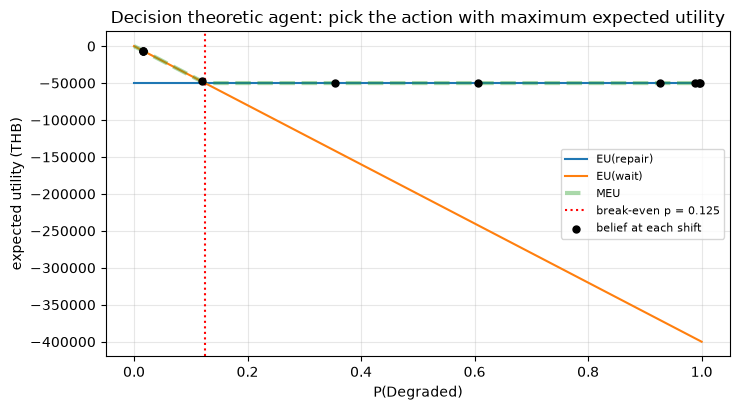

In [281]:
ps = [i / 200 for i in range(201)]
plt.figure(figsize=(7.5, 4.2))
plt.plot(ps, [expected_utility('repair', p) for p in ps], label='EU(repair)')
plt.plot(ps, [expected_utility('wait', p) for p in ps], label='EU(wait)')
plt.plot(ps, [meu(p)[0] for p in ps], linestyle='--', linewidth=3, alpha=0.4, label='MEU')
plt.axvline(breakeven, color='red', linestyle=':', label='break-even p = %.3f' % breakeven)
plt.scatter(filtered, [meu(p)[0] for p in filtered], color='black', zorder=5, s=25,
            label='belief at each shift')
plt.xlabel('P(Degraded)')
plt.ylabel('expected utility (THB)')
plt.title('Decision theoretic agent: pick the action with maximum expected utility')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**ประเด็นที่นักศึกษา CS มักพลาด:** เกณฑ์ตัดสินใจไม่ใช่ 0.5

เกณฑ์ที่ถูกต้องมาจากอัตราส่วนต้นทุน ที่นี่คือ 50,000 / 400,000 = 0.125
ถ้าเปลี่ยนต้นทุนความเสียหายเป็น 5,000,000 บาท (เช่น สายการผลิตยา) เกณฑ์จะเหลือ 0.01
คือแทบเห็นสัญญาณอะไรนิดเดียวก็ต้องหยุดซ่อม

ตอนสร้าง classifier ด้วย ML ก็หลักการเดียวกัน: threshold ไม่ควรมาจาก `argmax` แต่ควรมาจากตารางต้นทุน

## ส่วนที่ 6: Information Gathering Agent กับ VPI

โรงงานมีทางเลือกเพิ่ม: จ่าย **8,000 บาท** ส่งช่างมาทำ thermal scan ก่อนตัดสินใจ
การสแกนไม่สมบูรณ์แบบ แต่แม่นกว่าเซ็นเซอร์สั่นสะเทือน

$$P(scan{=}pos \mid Degraded) = 0.90 \qquad P(scan{=}pos \mid Healthy) = 0.15$$

คำถามคือ **คุ้มไหม** ตอบด้วย Value of Information (AIMA สมการ 16.7) โดยที่
"ข้อมูลมีค่า ก็ต่อเมื่อมันมีโอกาสทำให้เราเปลี่ยนใจ"

$$VPI(E) = \left(\sum_{e} P(e)\, MEU(e)\right) - MEU(\varnothing)$$

ให้สังเกตว่าเราใช้ Bayes' rule ธรรมดาในการอัปเดต prior เป็น posterior หลังรู้ผลสแกน
เหมือนที่ทำมาตลอดทั้งโน้ตบุ๊ก

In [282]:
P_SCAN_POS = {True: 0.90, False: 0.15}   # P(scan=positive | Degraded / Healthy)
SCAN_COST = 8_000


def vpi_scan(p_degraded):
    # มูลค่าคาดหวังของการรู้ผล thermal scan ก่อนตัดสินใจ
    total = 0.0
    for result in (True, False):
        lik_d = P_SCAN_POS[True] if result else 1 - P_SCAN_POS[True]
        lik_h = P_SCAN_POS[False] if result else 1 - P_SCAN_POS[False]
        p_result = lik_d * p_degraded + lik_h * (1 - p_degraded)
        if p_result == 0:
            continue
        posterior = lik_d * p_degraded / p_result          # Bayes' rule
        total += p_result * meu(posterior)[0]
    return total - meu(p_degraded)[0]


# VPI ต้องไม่ติดลบเสมอ: ข้อมูลเพิ่มไม่มีทางทำให้ตัดสินใจแย่ลง
for p in [i / 20 for i in range(21)]:
    assert vpi_scan(p) > -1e-6, 'VPI ติดลบ แปลว่าคำนวณผิด'

print('%12s %12s %10s %12s %s' % ('P(Degraded)', 'ตัดสินใจเดิม', 'VPI', 'ค่าสแกน', 'ควรสแกนไหม'))
print('-' * 64)
for p in [0.02, 0.05, 0.10, breakeven, 0.15, 0.25, 0.50, 0.87, 0.997]:
    v = vpi_scan(p)
    print('%12.3f %12s %10.0f %12d %s'
          % (p, meu(p)[1], v, SCAN_COST, 'สแกน' if v > SCAN_COST else 'ไม่ต้องสแกน'))

 P(Degraded) ตัดสินใจเดิม        VPI      ค่าสแกน ควรสแกนไหม
----------------------------------------------------------------
       0.020         wait         -0         8000 ไม่ต้องสแกน
       0.050         wait       8625         8000 สแกน
       0.100         wait      24750         8000 สแกน
       0.125         wait      32812         8000 สแกน
       0.150       repair      30875         8000 สแกน
       0.250       repair      23125         8000 สแกน
       0.500       repair       3750         8000 ไม่ต้องสแกน
       0.870       repair          0         8000 ไม่ต้องสแกน
       0.997       repair          0         8000 ไม่ต้องสแกน


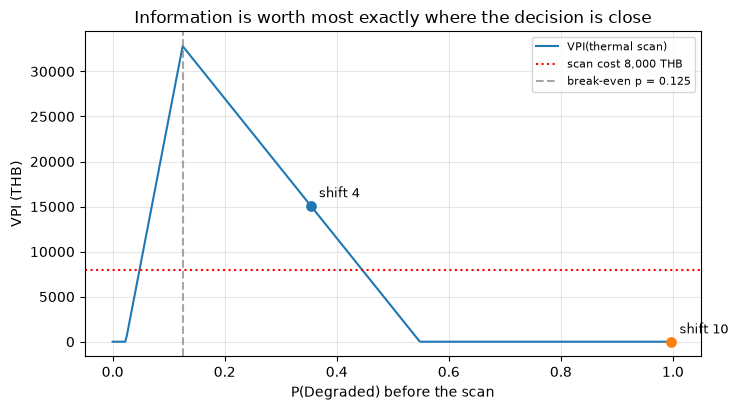

การตัดสินใจของ agent ในแต่ละกะ
  กะ  P(Degraded)        VPI การกระทำ
----------------------------------------------------
   1       0.0161          0 WAIT
   2       0.0152          0 WAIT
   3       0.0150          0 WAIT
   4       0.3534      15111 ขอ thermal scan ก่อน
   5       0.1193      30968 ขอ thermal scan ก่อน
   6       0.6054          0 REPAIR
   7       0.9269          0 REPAIR
   8       0.9881         -0 REPAIR
   9       0.9960          0 REPAIR
  10       0.9970          0 REPAIR


In [283]:
ps = [i / 400 for i in range(401)]
plt.figure(figsize=(7.5, 4.2))
plt.plot(ps, [vpi_scan(p) for p in ps], label='VPI(thermal scan)')
plt.axhline(SCAN_COST, color='red', linestyle=':', label='scan cost 8,000 THB')
plt.axvline(breakeven, color='gray', linestyle='--', alpha=0.7,
            label='break-even p = %.3f' % breakeven)
for t in (4, 10):
    plt.scatter([filtered[t - 1]], [vpi_scan(filtered[t - 1])], zorder=5, s=45)
    plt.annotate('shift %d' % t, (filtered[t - 1], vpi_scan(filtered[t - 1])),
                 textcoords='offset points', xytext=(6, 6), fontsize=9)
plt.xlabel('P(Degraded) before the scan')
plt.ylabel('VPI (THB)')
plt.title('Information is worth most exactly where the decision is close')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('การตัดสินใจของ agent ในแต่ละกะ')
print('%4s %12s %10s %s' % ('กะ', 'P(Degraded)', 'VPI', 'การกระทำ'))
print('-' * 52)
for t, p in enumerate(filtered, start=1):
    v = vpi_scan(p)
    action = 'ขอ thermal scan ก่อน' if v > SCAN_COST else meu(p)[1].upper()
    print('%4d %12.4f %10.0f %s' % (t, p, v, action))

**นี่คือหัวใจของ Information Gathering Agent** และเป็นผลลัพธ์ที่สวนสัญชาตญาณคนส่วนใหญ่

VPI เป็นรูประฆังที่ **สูงสุดตรงจุด break-even** และเป็น **ศูนย์** ที่ปลายทั้งสองข้าง

- ที่ P = 0.997 (กะ 10) VPI = 0 บาท เพราะไม่ว่าผลสแกนออกมาอย่างไร เราก็จะสั่งซ่อมอยู่ดี
  จ่าย 8,000 บาทไปเพื่อความสบายใจ ไม่ใช่เพื่อการตัดสินใจ
- ที่ P = 0.02 VPI ก็ต่ำ เพราะเราจะรอต่อไปอยู่แล้ว
- ที่ P ใกล้ 0.125 VPI พุ่งเกิน 30,000 บาท คุ้มค่าสแกนหลายเท่า

**กฎที่เอาไปใช้ได้ทันที:** อย่าเก็บข้อมูลเพิ่มเพราะ "ข้อมูลเยอะไว้ก่อนดี"
จงเก็บข้อมูลเมื่อมันมีโอกาสทำให้คุณ **เปลี่ยนการตัดสินใจ** เท่านั้น
หลักการเดียวกันนี้ใช้ตัดสินได้ว่าควรทำ A/B test เพิ่มไหม ควรสั่ง lab test ให้คนไข้ไหม
หรือควรให้ LLM agent เรียก tool เพิ่มอีกครั้งไหม

## สรุป: สถาปัตยกรรมของระบบจริง

```
เซ็นเซอร์สั่นสะเทือน ──> HMM forward ────────> P(Degraded) real time ──┐
เซ็นเซอร์อุณหภูมิ ────> Particle filter ────> wear level + RUL ───────┤
LiDAR ของ AGV ───────> MCL ─────────────────> ตำแหน่ง AGV ───────────┤
                                                                       v
                                              Decision agent (MEU) <──> VPI
                                                       │
                                          repair / wait / ขอข้อมูลเพิ่ม
                                                       │
ข้อมูลย้อนหลัง <── smoothing + Viterbi <── บันทึกผลไว้สอบสวนและปรับโมเดล
```

ทุกกล่องในแผนภาพนี้คืออัลกอริทึมที่อยู่ในโน้ตบุ๊กนี้ทั้งหมด
ส่วนที่งานจริงต้องเพิ่มคือการเรียนพารามิเตอร์จากข้อมูล (Baum-Welch / EM)
แทนการกรอกตัวเลข transition กับ sensor model ด้วยมือแบบที่เราทำ

### ข้อ 1: เซ็นเซอร์ที่ "ดีกว่า" คุ้มค่าจริงไหม

ฝ่ายจัดซื้อเสนอเซ็นเซอร์รุ่นใหม่ที่ false alarm ลดจาก 10% เหลือ 3% และ detection เพิ่มจาก 80% เป็น 90%
ราคาแพงกว่าเดิม 3 เท่า ทีมของคุณต้องตอบว่าคุ้มไหม

1. สร้าง `pump_v2` ด้วย sensor model ใหม่ แล้วรัน filtering บน `alerts` ชุดเดิม
   ระบบสั่งหยุดซ่อม (ตามเกณฑ์ MEU) **เร็วขึ้นกี่กะ**
2. รันทั้งสองเซ็นเซอร์บนลำดับ **false alarm** `[F, F, T, F, F, F]`
   ซึ่งเป็นกรณีที่เซ็นเซอร์เตือนผิดครั้งเดียวแล้วเงียบ
   นับว่าแต่ละเซ็นเซอร์ทำให้ระบบ **สั่งซ่อมเก้อกี่กะ**
3. สรุปว่าควรซื้อไหม พร้อมเหตุผลจากตัวเลขทั้งสองข้อ

*คำใบ้:* `maint_sensor` แถวแรกคือ `P(alert=True | [Healthy, Degraded])` แถวสองคือส่วนเติมเต็มให้รวมเป็น 1
ผลลัพธ์อาจไม่เป็นไปตามที่คาด ให้เชื่อตัวเลข

In [ ]:
# ข้อ 1: เติมโค้ดตรง TODO
# TODO: สร้าง sensor model ใหม่ตามสเปกเซ็นเซอร์รุ่นใหม่
sensor_v2 = [[0.03, 0.90],
             [0.97, 0.10]]

pump_v2 = HiddenMarkovModel(maint_transition, sensor_v2, maint_prior)


def run_filter(hmm, seq):
    # TODO: รัน forward ตลอดลำดับ seq แล้วคืนลิสต์ P(Degraded) ของแต่ละกะ
    beliefs = []
    f = hmm.prior
    for e in seq:
        f = forward(hmm, f, e)
        beliefs.append(f[1])
    return beliefs


def repair_shifts(beliefs):
    return [t for t, p in enumerate(beliefs, 1) if meu(p)[1] == 'repair']

filtered_v2 = run_filter(pump_v2, alerts)
assert filtered_v2, 'ยังไม่ได้เติม TODO: run_filter ต้องคืนลิสต์ P(Degraded)'

print('1) การตรวจจับของจริง')
print('   เซ็นเซอร์เดิม  สั่งซ่อมที่กะ', repair_shifts(filtered))
print('   รุ่นใหม่       สั่งซ่อมที่กะ', repair_shifts(filtered_v2))
print('   ความมั่นใจที่กะ 4: เดิม %.3f -> ใหม่ %.3f' % (filtered[3], filtered_v2[3]))

FALSE_ALARM = [F, F, T, F, F, F]
print('\n2) กรณีเซ็นเซอร์เตือนผิดครั้งเดียว')
for name, hmm in [('เดิม  ', pump), ('ใหม่  ', pump_v2)]:
    beliefs = run_filter(hmm, FALSE_ALARM)
    print('   %s P(Degraded) = %s -> สั่งซ่อมเก้อที่กะ %s'
          % (name, ['%.3f' % p for p in beliefs], repair_shifts(beliefs)))

# 3) ตอบ: ไม่ควรซื้อเซ็นเซอร์รุ่นใหม่
# เหตุผล:
# - เซ็นเซอร์ใหม่หยุดซ่อมเร็วเกินไป: จากผลรันข้อ 2 จะเห็นว่าแค่เตือนผิด (False Alarm) เพียงครั้งเดียว ระบบที่ใช้เซ็นเซอร์ใหม่ก็สั่ง หยุดซ่อมทันที ทำให้โรงงานเสียเวลาและขาดทุนจากการหยุดผลิต
# - เซ็นเซอร์เดิมเสถียรกว่า: เซ็นเซอร์เดิมจะรอดูสัญญาณเตือนซ้ำๆ กันหลายกะก่อนตัดสินใจสั่งซ่อม ทำให้ช่วยกรองการเตือนที่ผิดพลาดออกไปได้ดีกว่า
# - ไม่คุ้มต้นทุน: การที่ระบบสั่งหยุดเครื่องมั่วขึ้น แถมตัวเซ็นเซอร์ใหม่ยังแพงกว่าเดิมถึง 3 เท่า จึงเป็นการลงทุนที่ได้ไม่คุ้มเสีย

1) การตรวจจับของจริง
   เซ็นเซอร์เดิม  สั่งซ่อมที่กะ [4, 6, 7, 8, 9, 10]
   รุ่นใหม่       สั่งซ่อมที่กะ [4, 5, 6, 7, 8, 9, 10]
   ความมั่นใจที่กะ 4: เดิม 0.353 -> ใหม่ 0.639

2) กรณีเซ็นเซอร์เตือนผิดครั้งเดียว
   เดิม   P(Degraded) = ['0.016', '0.015', '0.354', '0.120', '0.041', '0.021'] -> สั่งซ่อมเก้อที่กะ [3]
   ใหม่   P(Degraded) = ['0.008', '0.006', '0.639', '0.157', '0.025', '0.008'] -> สั่งซ่อมเก้อที่กะ [3, 4]


### ข้อ 2: เลือกค่า lag ให้ dashboard

คำนวณ **ค่าคลาดเคลื่อนสัมบูรณ์เฉลี่ย** ระหว่างรายงานที่ lag = d กับค่า smoothing เต็มรูป
(ถือว่า smoothing เต็มรูปคือ "ความจริงที่ดีที่สุดที่เรารู้ได้") สำหรับ d = 0, 1, 2, 3

แล้วตอบว่า **lag เท่าไรที่คุ้มที่สุด** ถ้าทุก 1 กะที่หน่วงเพิ่ม มีต้นทุนเทียบเท่าค่าคลาดเคลื่อน 0.05

*คำใบ้:* ใช้ `fixed_lag(pump, alerts[:t], d)` เทียบกับ `smoothed[t - d - 1]` เฉพาะ t ที่ค่าไม่เป็น `None`

In [ ]:
# ข้อ 2: เติมโค้ดตรง TODO
LAG_PENALTY = 0.05

for d in range(4):
    errs = []
    for t in range(1, len(alerts) + 1):
        # TODO: เทียบ fixed_lag(pump, alerts[:t], d) กับ smoothed[t - d - 1]
        lag_dist = fixed_lag(pump, alerts[:t], d)

        if lag_dist is not None:
           err = abs(lag_dist - smoothed[t - d - 1])
           errs.append(err)
            
    mean_err = sum(errs) / len(errs) if errs else float('nan')
    print('d=%d mean|error| = %.4f ต้นทุนรวม = %.4f' 
          % (d, mean_err, mean_err + d * LAG_PENALTY))
# ตอบ:lag ที่คุ้มที่สุดคือ d = 2

d=0 mean|error| = 0.2026 ต้นทุนรวม = 0.2026
d=1 mean|error| = 0.1587 ต้นทุนรวม = 0.2087
d=2 mean|error| = 0.0968 ต้นทุนรวม = 0.1968
d=3 mean|error| = 0.0473 ต้นทุนรวม = 0.1973


### ข้อ 3: ตรวจจับ particle depletion

เพิ่มการคำนวณ **effective sample size** $ESS = 1 / \sum_i w_i^2$ ลงใน particle filter
ค่านี้บอกว่า "จริง ๆ แล้วมีอนุภาคกี่ตัวที่มีส่วนร่วมในการประมาณ"
ถ้า ESS ร่วงต่ำกว่า N/2 แปลว่าอนุภาคส่วนใหญ่แทบไม่มีส่วนร่วม ค่าประมาณเริ่มเชื่อไม่ได้

จากนั้นจำลองสถานการณ์ **น้ำมันหล่อลื่นรั่ว** โดยให้ ground truth สึกหรอเร็วขึ้น 3 เท่า
(`WEAR_STEP_MEAN * 3` ใน `simulate_pump` เท่านั้น ห้ามแก้ใน filter)
แล้วเทียบ ESS กับกรณีปกติ (`simulate_pump()`) ว่าร่วงตอนไหนและร่วงแค่ไหน

*คำใบ้:* คำนวณ ESS จาก `weights` หลัง normalize แล้ว ก่อนขั้น resample

In [291]:
# ข้อ 3: เติมโค้ดตรง TODO
def simulate_pump_leak(n_shifts=9, seed=7, drift=2.0):
    random.seed(seed)
    w, truth, obs = 0.05, [], []
    for _ in range(n_shifts):
        w = min(1.0, w + max(0.0, random.gauss(WEAR_STEP_MEAN * drift, WEAR_STEP_SD)))
        truth.append(w)
        obs.append(TEMP_BASE + TEMP_GAIN * w + random.gauss(0, TEMP_SD))
    return truth, obs


def wear_pf_with_ess(obs, N=3000, seed=1):
    random.seed(seed)
    particles = [random.uniform(0.0, 0.12) for _ in range(N)]
    mean, ess = [], []
    for z in obs:
        particles = [min(1.0, w + max(0.0, random.gauss(WEAR_STEP_MEAN, WEAR_STEP_SD)))
                     for w in particles]
        weights = [gaussian(TEMP_BASE + TEMP_GAIN * w, TEMP_SD, z) for w in particles]
        total = sum(weights)
        weights = [w / total for w in weights] if total > 0 else [1.0 / N] * N
        # TODO: คำนวณ effective sample size แล้ว append ลง ess
        current_ess = 1.0 / sum(w ** 2 for w in weights)
        ess.append(current_ess)
        
        particles = weighted_sample_with_replacement(N, particles, weights)
        mean.append(sum(particles) / N)
    return mean, ess


truth_leak, obs_leak = simulate_pump_leak(drift=3.0)
est_leak, ess_leak = wear_pf_with_ess(obs_leak)

print('%3s %9s %9s %10s %s' % ('กะ', 'จริง', 'ประมาณ', 'ESS', 'สถานะ'))
for t in range(len(truth_leak)):
    warn = 'LOW ESS' if ess_leak[t] == ess_leak[t] and ess_leak[t] < 1500 else ''
    print('%3d %9.3f %9.3f %10.1f %s' % (t + 1, truth_leak[t], est_leak[t], ess_leak[t], warn))

 กะ      จริง    ประมาณ        ESS สถานะ
  1     0.225     0.142     2304.9 
  2     0.400     0.224     2244.4 
  3     0.562     0.320     1533.7 
  4     0.764     0.444      353.9 LOW ESS
  5     0.965     0.579      372.0 LOW ESS
  6     1.000     0.676     1165.4 LOW ESS
  7     1.000     0.767     1251.0 LOW ESS
  8     1.000     0.852     1959.8 
  9     1.000     0.900     2774.8 


### ข้อ 4: AGV หลงทาง

รัน MCL ด้วย **การสแกนที่ผิดพลาด** คือ `z = (9, 9, 9, 9)` ซึ่งเป็นค่าที่แทบเป็นไปไม่ได้บนแผนที่นี้
(เช่น LiDAR สกปรกหรือมีคนเดินบัง)

1. เกิดอะไรขึ้นกับการกระจายของอนุภาค
2. ระบบจริงควรทำอย่างไรเมื่อ likelihood ของทุกอนุภาคเป็นศูนย์

*คำใบ้:* `P_sensor` คืน `0` เมื่อ `abs(x - y) > 2` ลองดูโค้ดของ `monte_carlo_localization` ด้วย `psource`

In [ ]:
# ข้อ 4: รันแล้วสังเกต จากนั้นตอบคำถามในคอมเมนต์
random.seed(11)
try:
    S_bad = monte_carlo_localization({'v': (0, 0), 'w': 0}, (9, 9, 9, 9),
                                     500, P_motion_sample, P_sensor, warehouse)
    print('จำนวนช่องที่มีอนุภาค:', len({(x, y) for x, y, _ in S_bad}))
    for cell, pct in confidence(S_bad, 5):
        print('   %s : %.1f%%' % (cell, pct))
except IndexError as e:
    print('monte_carlo_localization ล้มด้วย IndexError: %r' % (e,))
    print('อ่านโค้ดด้วย psource(monte_carlo_localization) แล้วหาว่าบรรทัดไหนพัง')

# วินิจฉัยก่อนโทษโค้ด: อัลกอริทึมคูณ likelihood ของเซ็นเซอร์ทั้ง 4 ทิศเข้าด้วยกัน
random.seed(11)
particles = [warehouse.sample() for _ in range(500)]
weights = []
for kin in particles:
    w = 1.0
    for j in range(4):
        w *= P_sensor(9, warehouse.ray_cast(j, kin))
    weights.append(w)

print('อนุภาคที่มีน้ำหนักมากกว่าศูนย์: %d จาก %d' % (sum(1 for w in weights if w > 0), len(weights)))
print('ผลรวมน้ำหนักทั้งหมด =', sum(weights))

# TODO ตอบ:
# 1. เกิดอะไรขึ้น:
# โปรแกรมเกิด IndexError เพราะค่าเซ็นเซอร์ (9, 9, 9, 9) ไม่มีทางเกิดขึ้นได้จริงบนพื้นที่นี้ ทำให้ฟังก์ชันคำนวณน้ำหนัก (likelihood) ของทั้ง 4 ทิศทางคูณกันออกมาเป็นศูนย์ในทุกๆ อนุภาค 
# พอน้ำหนักรวมทั้งหมดเป็น 0 สนิท ฟังก์ชันสุ่มอย่าง weighted_sample_with_replacement จึงทำงานต่อไม่ได้และแครชไปในที่สุด
#
# 2. ระบบจริงควรทำอย่างไร:
# ควรวางกลไกป้องกันความผิดพลาดไว้ 3 ระดับ คือ:
# - มองข้ามค่าผิดปกติ (Outlier Rejection): คอยเช็กน้ำหนักรวมก่อนเสมอ หากเป็นศูนย์ให้ข้ามการคำนวณรอบนั้นไปเลย
# - กำหนดค่าต่ำสุดเผื่อไว้ (Floor Value): ปรับ Sensor model ไม่ให้คืนค่า 0 แบบเด็ดขาด เพื่อป้องกันไม่ให้ระบบคำนวณต่อไม่ได้
# - รีเซ็ตระบบนำทางใหม่ (Global Relocalization): หากเจอปัญหาเดิมซ้ำๆ ให้ถือว่าหุ่นยนต์หลงทาง แล้วทำการสุ่มอนุภาคใหม่ให้กระจายทั่วแผนที่

### ข้อ 5: เปลี่ยนตัวเลขต้นทุน เปลี่ยนทั้งระบบ

โรงงานย้ายไปผลิตยาฉีด ซึ่งความเสียหายจากเครื่องพังกลางกะพุ่งเป็น **5,000,000 บาท**
ส่วนค่าซ่อมยังเท่าเดิม

1. เกณฑ์ break-even ใหม่เป็นเท่าไร
2. ระบบจะสั่งหยุดซ่อมที่กะไหน
3. VPI ที่กะ 4 เปลี่ยนไปอย่างไร และยังคุ้มค่าสแกน 8,000 บาทไหม

*คำใบ้:* เขียนฟังก์ชันรับ `cost_breakdown` เป็นพารามิเตอร์ แทนการแก้ตัวแปร global

In [301]:
# ข้อ 5: เติมโค้ดตรง TODO
def make_decision_model(cost_breakdown, cost_repair=COST_REPAIR):
    # คืน (eu, meu, breakeven) สำหรับต้นทุนชุดใหม่
    U = {('repair', True): -cost_repair,   ('repair', False): -cost_repair,
         ('wait', True): -cost_breakdown,  ('wait', False): 0}

    def eu(a, p):
        return p * U[(a, True)] + (1 - p) * U[(a, False)]

    def meu_(p):
        return max((eu(a, p), a) for a in ACTIONS)

    return eu, meu_, cost_repair / cost_breakdown


# TODO: สร้างโมเดลต้นทุนใหม่ที่ 5,000,000 บาท แล้วตอบคำถามทั้ง 3 ข้อ
eu_new, meu_new, breakeven_new = make_decision_model(cost_breakdown=5000000)

print("1. เกณฑ์ break-even ใหม่เป็นเท่าไร?")
print(f"{breakeven_new:.5f} (หรือ {breakeven_new * 100:.2f}%)")

print("\n2. ระบบจะสั่งหยุดซ่อมที่กะไหน?")
repair_shifts_new = [t for t, p in enumerate(filtered, 1) if meu_new(p)[1] == 'repair']
first_shift = repair_shifts_new[0] if repair_shifts_new else "ไม่มี"
print(f"ระบบจะสั่งหยุดซ่อมไวขึ้น โดยจะสั่งหยุดตั้งแต่กะที่ {first_shift}")

print("\n3. VPI ที่กะ 4 เปลี่ยนไปอย่างไร และยังคุ้มค่าสแกน 8,000 บาทไหม?")
p4 = filtered[3] 
eu_exact_info = p4 * eu_new('repair', 1.0) + (1 - p4) * eu_new('wait', 0.0)


current_meu_value = meu_new(p4)[0]
vpi_new = eu_exact_info - current_meu_value

print(f"VPI ที่กะ 4 ลดลงเหลือเพียง: {vpi_new:.2f} บาท")
if vpi_new > 8000:
    print("สรุป: ยังคงคุ้มค่าที่จะจ้างคนมาสแกน")
else:
    print("สรุป:ไม่คุ้มค่าที่จะสแกนแล้ว (VPI < 8,000 บาท)")

1. เกณฑ์ break-even ใหม่เป็นเท่าไร?
0.01000 (หรือ 1.00%)

2. ระบบจะสั่งหยุดซ่อมที่กะไหน?
ระบบจะสั่งหยุดซ่อมไวขึ้น โดยจะสั่งหยุดตั้งแต่กะที่ 1

3. VPI ที่กะ 4 เปลี่ยนไปอย่างไร และยังคุ้มค่าสแกน 8,000 บาทไหม?
VPI ที่กะ 4 ลดลงเหลือเพียง: 32329.54 บาท
สรุป: ยังคงคุ้มค่าที่จะจ้างคนมาสแกน


### ข้อ 6 (ท้าทาย): เรียนพารามิเตอร์จากข้อมูล

ที่ผ่านมาเรากรอก `maint_transition` และ `maint_sensor` ด้วยมือ ในงานจริงต้องเรียนจากข้อมูล

ถ้ามีข้อมูลที่ **รู้สถานะจริง** (จากใบบันทึกการซ่อม) การประมาณค่าทำได้ด้วยการนับตรง ๆ
เขียนฟังก์ชัน `fit_hmm(states, evidence)` ที่รับลิสต์สถานะจริงกับลิสต์หลักฐาน
แล้วคืน transition model กับ sensor model โดยใช้ **Laplace smoothing** (บวก 1 ทุกช่อง)
เพื่อกันความน่าจะเป็นเป็นศูนย์

ทดสอบโดยสร้างข้อมูลจาก `pump` ตัวจริง 5,000 กะ แล้วดูว่าค่าที่เรียนได้เข้าใกล้ของจริงไหม

*คำใบ้:* transition นับคู่ `(states[i], states[i+1])`, sensor นับคู่ `(states[i], evidence[i])`
Laplace smoothing คือ `(count + 1) / (total + จำนวนค่าที่เป็นไปได้)`

In [300]:
# ข้อ 6: เติมโค้ดตรง TODO
def sample_hmm(hmm, n, seed=0):
    # สร้างข้อมูลจำลองจาก HMM: คืน (states, evidence) โดย state True = Healthy
    random.seed(seed)
    states, evidence = [], []
    healthy = probability(hmm.prior[0])
    for _ in range(n):
        row = hmm.transition_model[0 if healthy else 1]
        healthy = probability(row[0])
        states.append(healthy)
        p_alert = hmm.sensor_model[0][0 if healthy else 1]
        evidence.append(probability(p_alert))
    return states, evidence

def fit_hmm(states, evidence):
    trans_counts = [[0, 0], [0, 0]] 
    sens_counts  = [[0, 0], [0, 0]] 
    for s, e in zip(states, evidence):
        s_idx = 0 if s else 1
        e_idx = 0 if e else 1
        sens_counts[s_idx][e_idx] += 1

    for i in range(len(states) - 1):
        s_from = 0 if states[i] else 1
        s_to   = 0 if states[i+1] else 1
        trans_counts[s_from][s_to] += 1

    transition_model = []
    for row in trans_counts:
        total = sum(row)
        transition_model.append([(c + 1) / (total + 2) for c in row])

    total_H = sum(sens_counts[0])
    total_D = sum(sens_counts[1])
    
    sensor_model = [
       
        [(sens_counts[0][0] + 1) / (total_H + 2), 
         (sens_counts[1][0] + 1) / (total_D + 2)],
         
        
        [(sens_counts[0][1] + 1) / (total_H + 2), 
         (sens_counts[1][1] + 1) / (total_D + 2)]
    ]
    
    return transition_model, sensor_model


states, evidence = sample_hmm(pump, 5000)
learned = fit_hmm(states, evidence)
print('transition ที่เรียนได้:', learned[0] if learned else None)
print('transition จริง      :', maint_transition)
print('sensor ที่เรียนได้   :', learned[1] if learned else None)
print('sensor จริง          :', maint_sensor)

transition ที่เรียนได้: [[0.9557242251739405, 0.044275774826059454], [0.02016364699006429, 0.9798363530099357]]
transition จริง      : [[0.95, 0.05], [0.02, 0.98]]
sensor ที่เรียนได้   : [[0.09867172675521822, 0.8004674262342975], [0.9013282732447818, 0.1995325737657026]]
sensor จริง          : [[0.1, 0.8], [0.9, 0.2]]


<details>
<summary><b>คลิกเพื่อดูแนวเฉลย</b> (ลองทำเองให้สุดก่อน)</summary>

**ข้อ 1** เฉลยที่สวนความคาดหมาย
```python
sensor_v2 = [[0.03, 0.90], [0.97, 0.10]]

def run_filter(hmm, seq):
    b, out = maint_prior, []
    for e in seq:
        b = forward(hmm, b, e)
        out.append(float(b[1]))
    return out
```
1. **เร็วขึ้น 0 กะ** ทั้งสองเซ็นเซอร์สั่งซ่อมที่กะ 4 เท่ากัน เพราะเกณฑ์ MEU ต่ำเพียง 0.125
   เซ็นเซอร์เดิมก็ข้ามเกณฑ์ไปแล้ว สิ่งที่ต่างคือ **ความมั่นใจ** (0.353 เทียบกับ 0.639)
2. บนลำดับ false alarm เซ็นเซอร์เดิมสั่งซ่อมเก้อ **1 กะ** ส่วนรุ่นใหม่ **2 กะ**
   เพราะ likelihood ratio ที่สูงขึ้น (จาก 8 เท่าเป็น 30 เท่า) ดัน posterior ขึ้นแรงกว่า
   และต้องใช้หลักฐานตรงข้ามมากกว่าจึงจะดึงกลับลงมา
3. คำตอบที่ถูกคือ **"ยังไม่พอตัดสิน"** ตัวเลขสองชุดนี้ขัดแย้งกัน ต้องประเมินด้วยการจำลอง
   หลาย ๆ ลำดับแล้วเทียบต้นทุนรวม ไม่ใช่ดูสเปกเซ็นเซอร์อย่างเดียว
   บทเรียน: สเปกที่ดีกว่าบนกระดาษไม่ได้แปลว่าระบบตัดสินใจดีขึ้นเสมอ

**ข้อ 2**
```python
v = fixed_lag(pump, alerts[:t], d)
if v is not None:
    errs.append(abs(v - smoothed[t - d - 1]))
```
ผลที่ได้: d=0 คลาดเคลื่อน 0.203, d=1 คือ 0.159, d=2 คือ 0.097, d=3 คือ 0.047
เมื่อบวกค่าปรับการหน่วง 0.05 ต่อกะแล้ว **d = 2 คุ้มที่สุด** (รวม 0.197) โดยมี d = 3 ตามมาติด ๆ

**ข้อ 3**
```python
ess.append(1.0 / sum(w * w for w in weights))
```
กรณีปกติ ESS ส่วนใหญ่อยู่ราว 2,800 ถึง 2,900 จาก N = 3,000 (ร่วงต่ำสุดครั้งเดียวราว 1,450)
กรณีน้ำมันรั่ว ESS ร่วงเหลือราว 950 ถึง 1,400 ในกะที่ 4 ถึง 8 ซึ่งเป็นช่วงที่ค่าประมาณตามความจริงไม่ทัน
สาเหตุคือ transition model บอกว่าสึกหรอ 0.06 ต่อกะ แต่ของจริงเป็น 0.12
อุณหภูมิที่วัดได้จึงอยู่ปลายหางของสิ่งที่อนุภาคทำนายไว้
ทางแก้ในระบบจริง: เพิ่ม process noise, ทำ adaptive resampling หรือแจ้งเตือนเมื่อ ESS ต่ำผิดปกติ

**ข้อ 4**
1. `monte_carlo_localization` **ล้มด้วย `IndexError`** ไม่ใช่แค่ให้ผลแย่
   เพราะบรรทัด `W_[i] = W_[i] * P_sensor(z[j], z_)` คูณ likelihood ของเซ็นเซอร์ทั้ง 4 ทิศเข้าด้วยกัน
   ระยะ 9 ช่องพร้อมกันทั้ง 4 ทิศเป็นไปไม่ได้บนแผนที่นี้ อนุภาคทั้ง 500 ตัวจึงมีน้ำหนักเป็นศูนย์
   แล้ว `weighted_sample_with_replacement` ก็ทำงานกับน้ำหนักรวมศูนย์ไม่ได้
2. ระบบจริงต้องมี 3 ชั้นป้องกัน
   - ตรวจผลรวมน้ำหนักก่อน resample ถ้าเป็นศูนย์หรือต่ำผิดปกติให้ **ทิ้งการวัดครั้งนั้น** (outlier rejection)
   - ใส่ค่าพื้น (floor) เล็ก ๆ ใน sensor model แทนการคืน 0 เพื่อไม่ให้ likelihood เป็นศูนย์สนิท
   - ถ้าเกิดติดกันหลายครั้ง ให้เข้าโหมด **global relocalization** คือโปรยอนุภาคใหม่ทั่วแผนที่
   บทเรียน: โค้ดตำราไม่ได้ออกแบบมารับ sensor ที่พัง แต่โรงงานจริงมี sensor พังทุกสัปดาห์

**ข้อ 5**
```python
eu5, meu5, be5 = make_decision_model(5_000_000)
```
1. เกณฑ์ break-even ใหม่ = 50,000 / 5,000,000 = **0.01**
2. ระบบสั่งหยุดซ่อม **ตั้งแต่กะที่ 1** เพราะความเชื่อเริ่มต้น 0.016 สูงกว่าเกณฑ์ 0.01 ไปแล้ว
3. VPI ที่กะ 4 กลายเป็น **0 บาท** (ไม่คุ้มสแกน) เพราะ p = 0.353 ห่างจากเกณฑ์ 0.01 มาก
   จนผลสแกนไม่มีทางเปลี่ยนใจได้ แต่ VPI ที่ **กะ 1** พุ่งเป็นราว 33,800 บาท ซึ่งคุ้มมาก
   สรุป: การเปลี่ยนตัวเลขต้นทุนไม่ได้เลื่อนแค่เกณฑ์ตัดสินใจ แต่ย้าย **จุดที่ควรเก็บข้อมูลเพิ่ม** ไปด้วย

**ข้อ 6**
```python
def fit_hmm(states, evidence):
    tc = {(a, b): 1 for a in (True, False) for b in (True, False)}
    sc = {(a, b): 1 for a in (True, False) for b in (True, False)}
    for i in range(len(states) - 1):
        tc[(states[i], states[i + 1])] += 1
    for s, e in zip(states, evidence):
        sc[(s, e)] += 1

    def row(counts, key):
        tot = counts[(key, True)] + counts[(key, False)]
        return [counts[(key, True)] / tot, counts[(key, False)] / tot]

    trans = [row(tc, True), row(tc, False)]          # [Healthy -> ..., Degraded -> ...]
    p_alert = [sc[(True, True)] / (sc[(True, True)] + sc[(True, False)]),
               sc[(False, True)] / (sc[(False, True)] + sc[(False, False)])]
    sensor = [p_alert, [1 - p_alert[0], 1 - p_alert[1]]]
    return trans, sensor
```
ค่าที่เรียนได้จาก 5,000 กะจะเข้าใกล้ของจริงในระดับทศนิยมสองตำแหน่ง
ลองลดเหลือ 200 กะแล้วดูว่าคลาดเคลื่อนแค่ไหน จะเห็นว่าช่อง `Degraded -> Healthy`
ซึ่งมีความน่าจะเป็นเพียง 0.02 ต้องใช้ข้อมูลมากที่สุดกว่าจะประมาณได้แม่น
นี่คือเหตุผลที่ Laplace smoothing สำคัญ: ถ้าไม่มีตัวอย่างของเหตุการณ์หายากเลย
เราจะได้ความน่าจะเป็น 0 ซึ่งแปลว่า "เป็นไปไม่ได้ตลอดกาล" และทำให้ทั้งโมเดลพัง

ถ้าไม่มีข้อมูลสถานะจริงเลย ต้องใช้ Baum-Welch (EM) ซึ่งอยู่นอกขอบเขตโน้ตบุ๊กนี้

</details>

---